# Application IA de Scoring de Risque de Défaut
## Pipeline complet — Home Credit Default Risk (307 511 observations)

**Auteur :** SINGHE PENKA HENDRIX DONAVAN — ENSPY Genie Informatique 5e annee  
**Entreprise :** IT Nearshore  
**Date :** Mai 2026  

---

### Architecture du pipeline (version finale)

```
Donnees brutes (7 fichiers)
    -> SECTION 0 : Installation et imports
    -> SECTION 1 : Exploration + filtre colonnes >50% NaN
    -> SECTION 2 : Feature Engineering (numeriques + TOUTES categorielle valides)
    -> SECTION 3 : Split temporel 70/15/15
    -> SECTION 4 : Pre-filtre IV (seuil 0.02, Siddiqi 2006)
    -> SECTION 5 : Encodage WOE par Optimal Binning
    -> SECTION 6 : Selection NAP (tout le train)
    -> SECTION 7 : Entrainement LightGBM + scale_pos_weight
    -> SECTION 8 : Comparaison des modeles
    -> SECTION 9 : Evaluation finale sur Test Set (une seule fois)
    -> SECTION 10 : Explicabilite SHAP + Score PDO + Indice pc
```

**Regles fondamentales :**
- `NaN != 0` : absence d'information n'est jamais confondue avec zero
- Parametres WOE/NAP calcules sur le **train uniquement**
- Test set consulte **une seule fois** (Section 9)
- SMOTE supprime — remplace par `scale_pos_weight` dans LightGBM
- NAP sur **tout** le train (pas de sous-echantillonnage)
- Variables categorielle : **toutes incluses**, filtre IV decide


---
## SECTION 0 — Installation et imports

Installe les bibliotheques et importe tous les modules.

**Decisions techniques cles :**
- `optbinning==0.21.0` : version fixee pour la reproductibilite
- `LightGBM` : modele final retenu (Recall +0.28 vs XGBoost)
- `CAT_FEATURES` : toutes les categorielle valides — definie ici une seule fois
- `OFFSET = 515.06` : calcule pour que PD=5% donne Score=600
- `scale_pos_weight` : sera calcule en Section 1 depuis les vraies donnees


In [1]:
# ============================================================
# SECTION 0 — INSTALLATION ET IMPORTS
# ============================================================

import subprocess, os, sys

subprocess.run([sys.executable, '-m', 'pip', 'install',
                'optbinning==0.21.0', '-q'], capture_output=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, pickle, time
warnings.filterwarnings('ignore')

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    roc_auc_score, f1_score, recall_score, precision_score,
    brier_score_loss, accuracy_score, confusion_matrix, roc_curve
)
from scipy.stats import ks_2samp
import xgboost as xgb
import lightgbm as lgb
from optbinning import OptimalBinning
import shap

# ============================================================
# DÉTECTION AUTOMATIQUE DU CHEMIN DES DONNÉES
# ============================================================
POSSIBLE_PATHS = [
    '/kaggle/input/home-credit-default-risk/',
    '/kaggle/input/competitions/home-credit-default-risk/',
    '/kaggle/input/datasets/home-credit-default-risk/',
]

INPUT_DIR = None
for path in POSSIBLE_PATHS:
    if os.path.exists(path) and 'application_train.csv' in os.listdir(path):
        INPUT_DIR = path
        break

if INPUT_DIR is None and os.path.exists('/kaggle/input/'):
    for root, dirs, files in os.walk('/kaggle/input/'):
        if 'application_train.csv' in files:
            INPUT_DIR = root + '/'
            break

if INPUT_DIR is None:
    print('DATASET HOME CREDIT NON TROUVÉ — Ajoutez-le via + Add Data sur Kaggle')
    raise FileNotFoundError('Dataset Home Credit non trouvé.')

OUTPUT_DIR = '/kaggle/working/'
DATA_DIR   = '/kaggle/working/data/'
ART_DIR    = '/kaggle/working/artefacts/'
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(ART_DIR,  exist_ok=True)

# Style graphiques
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
COLORS = {'primary': '#1F4E79', 'secondary': '#2E75B6',
          'success': '#70AD47', 'danger': '#C00000', 'warning': '#FFC000'}

# ============================================================
# PARAMÈTRES GLOBAUX DU PIPELINE
# ============================================================

# Seuil IV — Siddiqi (2006) : standard bancaire international
# < 0.02 = pas de signal | 0.02-0.10 = faible | 0.10-0.30 = moyen | > 0.30 = fort
IV_THRESHOLD = 0.02

# Paramètres Score PDO (Points to Double the Odds)
# Ancrage : PD = 5% -> Score = 600 (convention bancaire standard)
# PDO = 20 : chaque tranche de 20 points double le risque
# Calcul Offset : 600 = Offset - (20/ln2) x ln(0.05/0.95)
#                 600 = Offset + 84.94 => Offset = 515.06
PDO    = 20
FACTOR = PDO / np.log(2)   # = 28.85
OFFSET = 515.06             # ancrage PD=5% -> Score=600

# Seuils de décision PDO
SEUIL_ACCORDE = 600   # PD < 5%  -> ACCORDE
SEUIL_REVUE   = 500   # 5% < PD < 50% -> REVUE MANUELLE
                       # Score < 500 -> REFUSE

# CAT_FEATURES — sera rempli en Section 1 (toutes catégorielles valides)
CAT_FEATURES = []
SCALE_POS_WEIGHT = None  # sera calculé en Section 1

# Vérification
print('=' * 60)
print('  VÉRIFICATION DE L\'ENVIRONNEMENT')
print('=' * 60)
print(f'  Python      : {sys.version.split()[0]}')
print(f'  LightGBM    : {lgb.__version__}')
print(f'  XGBoost     : {xgb.__version__}')
print(f'  INPUT_DIR   : {INPUT_DIR}')
print()
print('  Fichiers disponibles :')
for f in sorted(os.listdir(INPUT_DIR)):
    sz = os.path.getsize(INPUT_DIR + f) / 1024 / 1024
    print(f'    {f:<45} {sz:.0f} MB')
print()
print(f'  Paramètres PDO : Factor={FACTOR:.2f} | Offset={OFFSET:.2f}')
print(f'  Ancrage : PD=5% -> Score=600')
print(f'  Seuils  : ACCORDE >= {SEUIL_ACCORDE} | REVUE >= {SEUIL_REVUE} | REFUSE < {SEUIL_REVUE}')
print()


# ============================================================
# FAMILLE_MAPPING — construit dynamiquement en Section 2
# Ce dictionnaire mappe chaque feature a sa famille (F1-F9, EXT)
# Il est peuple progressivement a la fin de chaque bloc famille.
# JAMAIS modifie manuellement — 100% dynamique.
# ============================================================
FAMILLE_MAPPING = {}  # sera rempli en Section 2
print('OK Environnement pret')


  VÉRIFICATION DE L'ENVIRONNEMENT
  Python      : 3.12.13
  LightGBM    : 4.6.0
  XGBoost     : 3.2.0
  INPUT_DIR   : /kaggle/input/competitions/home-credit-default-risk/

  Fichiers disponibles :
    HomeCredit_columns_description.csv            0 MB
    POS_CASH_balance.csv                          375 MB
    application_test.csv                          25 MB
    application_train.csv                         158 MB
    bureau.csv                                    162 MB
    bureau_balance.csv                            358 MB
    credit_card_balance.csv                       405 MB
    installments_payments.csv                     690 MB
    previous_application.csv                      386 MB
    sample_submission.csv                         1 MB

  Paramètres PDO : Factor=28.85 | Offset=515.06
  Ancrage : PD=5% -> Score=600
  Seuils  : ACCORDE >= 600 | REVUE >= 500 | REFUSE < 500

OK Environnement pret


**Resultat attendu :** toutes les bibliotheques s'affichent sans erreur et les 7 fichiers du dataset sont listes.


---
## SECTION 1 — Exploration et Analyse du Dataset

**Trois analyses fondamentales :**
1. Desequilibre des classes -> justifie `scale_pos_weight`
2. Valeurs manquantes -> colonnes >50% NaN exclues de la construction
3. Construction de CAT_FEATURES : toutes categorielle avec NaN <= 50%

**Regle sur les colonnes NaN :** une colonne source avec >50% de NaN produit
une feature peu fiable statistiquement. On exclut la **colonne**, jamais le **client**.
Les NaN dans les features construites seront geres par le bin 'Manquant' du WOE.


Chargement de application_train.csv...
OK 307,511 observations, 122 variables

  DESEQUILIBRE DES CLASSES
  Bons payeurs  (TARGET=0) :    282,686  (91.93%)
  Defauts       (TARGET=1) :     24,825  (8.07%)
  scale_pos_weight (brut)  : 11.39
  -> Chaque defaut compte 11.4x plus dans LightGBM


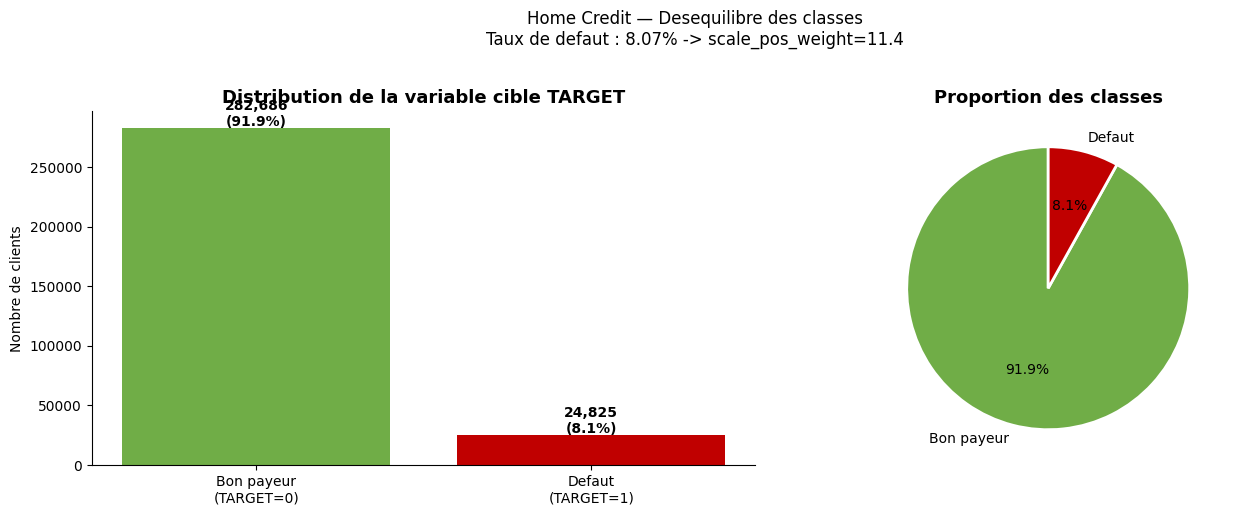


  VALEURS MANQUANTES :
  Variables avec NaN : 67 / 122

  FILTRE COLONNES >50% NaN :
  Colonnes exclues de la construction : 41
    - OWN_CAR_AGE (66% NaN)
    - EXT_SOURCE_1 (56% NaN)
    - APARTMENTS_AVG (51% NaN)
    - BASEMENTAREA_AVG (59% NaN)
    - YEARS_BUILD_AVG (66% NaN)
    - COMMONAREA_AVG (70% NaN)
    - ELEVATORS_AVG (53% NaN)
    - ENTRANCES_AVG (50% NaN)
    - FLOORSMIN_AVG (68% NaN)
    - LANDAREA_AVG (59% NaN)
    ... et 31 autres


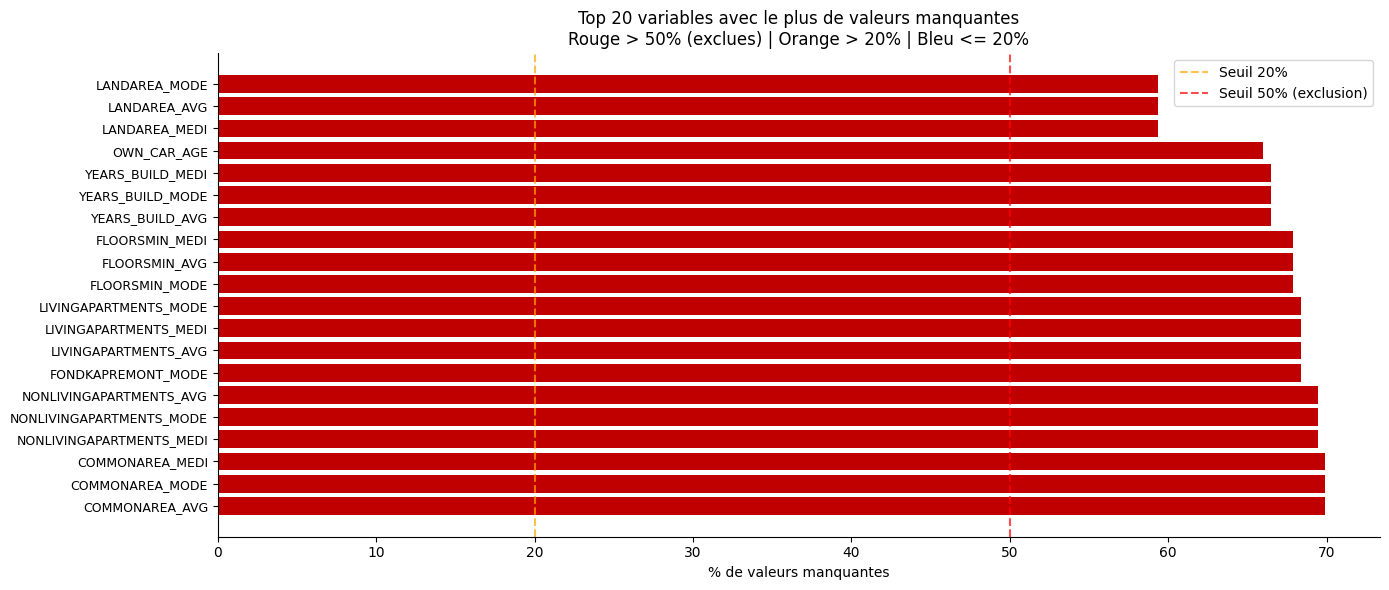


  VARIABLES CATEGORIELLE RETENUES (NaN <= 50%) :
  Total : 13 — le filtre IV (Section 4) decidera lesquelles conserver
    NAME_CONTRACT_TYPE                    2 modalites | 0.0% NaN
    CODE_GENDER                           3 modalites | 0.0% NaN
    FLAG_OWN_CAR                          2 modalites | 0.0% NaN
    FLAG_OWN_REALTY                       2 modalites | 0.0% NaN
    NAME_TYPE_SUITE                       7 modalites | 0.4% NaN
    NAME_INCOME_TYPE                      8 modalites | 0.0% NaN
    NAME_EDUCATION_TYPE                   5 modalites | 0.0% NaN
    NAME_FAMILY_STATUS                    6 modalites | 0.0% NaN
    NAME_HOUSING_TYPE                     6 modalites | 0.0% NaN
    OCCUPATION_TYPE                      18 modalites | 31.3% NaN
    WEEKDAY_APPR_PROCESS_START            7 modalites | 0.0% NaN
    ORGANIZATION_TYPE                    58 modalites | 0.0% NaN
    EMERGENCYSTATE_MODE                   2 modalites | 47.4% NaN

  CAS PARTICULIER DAYS_EMPLOYED 

In [2]:
# ============================================================
# SECTION 1 — EXPLORATION DU DATASET PRINCIPAL
# ============================================================

print('Chargement de application_train.csv...')
app_train = pd.read_csv(INPUT_DIR + 'application_train.csv')
print(f'OK {app_train.shape[0]:,} observations, {app_train.shape[1]} variables\n')

nb_total  = len(app_train)
nb_defaut = int(app_train['TARGET'].sum())
nb_bon    = nb_total - nb_defaut
taux      = nb_defaut / nb_total * 100

# --- 1.1 Desequilibre des classes ---
print('=' * 55)
print('  DESEQUILIBRE DES CLASSES')
print('=' * 55)
print(f'  Bons payeurs  (TARGET=0) : {nb_bon:>10,}  ({100-taux:.2f}%)')
print(f'  Defauts       (TARGET=1) : {nb_defaut:>10,}  ({taux:.2f}%)')

# scale_pos_weight : chaque defaut pese X fois plus qu'un bon payeur
# Calcule depuis les vraies donnees (pas un parametre arbitraire)
SCALE_POS_WEIGHT = nb_bon / nb_defaut
print(f'  scale_pos_weight (brut)  : {SCALE_POS_WEIGHT:.2f}')
print(f'  -> Chaque defaut compte {SCALE_POS_WEIGHT:.1f}x plus dans LightGBM')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(['Bon payeur\n(TARGET=0)', 'Defaut\n(TARGET=1)'],
            [nb_bon, nb_defaut], color=[COLORS['success'], COLORS['danger']])
axes[0].set_title('Distribution de la variable cible TARGET', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Nombre de clients')
for i, v in enumerate([nb_bon, nb_defaut]):
    axes[0].text(i, v + 2000, f'{v:,}\n({[100-taux, taux][i]:.1f}%)', ha='center', fontweight='bold')

axes[1].pie([nb_bon, nb_defaut], labels=['Bon payeur', 'Defaut'],
            colors=[COLORS['success'], COLORS['danger']],
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proportion des classes', fontsize=13, fontweight='bold')
plt.suptitle(f'Home Credit — Desequilibre des classes\nTaux de defaut : {taux:.2f}% -> scale_pos_weight={SCALE_POS_WEIGHT:.1f}',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'fig1_desequilibre_classes.png', dpi=150, bbox_inches='tight')
plt.show()

# --- 1.2 Valeurs manquantes et filtre colonnes ---
nan_pct  = (app_train.isnull().sum() / nb_total * 100).sort_values(ascending=False)
cols_nan = nan_pct[nan_pct > 0]

print(f'\n  VALEURS MANQUANTES :')
print(f'  Variables avec NaN : {len(cols_nan)} / {app_train.shape[1]}')

# FILTRE COLONNES >50% NaN
# Raison : les colonnes avec >50% de NaN couvrent une fraction trop faible
# de la population (< 50% des clients). Les features derivees depuis ces colonnes
# reposent sur un sous-ensemble limite de clients et risquent d'etre peu
# generalisables. Le bin 'Missing' du WOE tendrait a devenir dominant,
# reduisant la capacite discriminante de la variable.
# Note : 30% de 307 511 = 92 000 obs — pas un probleme de robustesse statistique
# mais bien de couverture de la population.
# Ce filtre s'applique aux COLONNES sources, jamais aux CLIENTS (observations).
# La Section 4b calcule l'IV de toutes les colonnes exclues pour justification.
COLS_HIGH_NAN = [col for col in app_train.columns
                 if app_train[col].isnull().mean() > 0.50]
print(f'\n  FILTRE COLONNES >50% NaN :')
print(f'  Colonnes exclues de la construction : {len(COLS_HIGH_NAN)}')
for c in COLS_HIGH_NAN[:10]:
    print(f'    - {c} ({app_train[c].isnull().mean()*100:.0f}% NaN)')
if len(COLS_HIGH_NAN) > 10:
    print(f'    ... et {len(COLS_HIGH_NAN)-10} autres')

fig, ax = plt.subplots(figsize=(14, 6))
top_nan = cols_nan.head(20)
colors_nan = [COLORS['danger'] if v > 50 else COLORS['warning'] if v > 20
              else COLORS['secondary'] for v in top_nan.values]
ax.barh(range(len(top_nan)), top_nan.values, color=colors_nan)
ax.set_yticks(range(len(top_nan)))
ax.set_yticklabels(top_nan.index, fontsize=9)
ax.set_xlabel('% de valeurs manquantes')
ax.set_title('Top 20 variables avec le plus de valeurs manquantes\nRouge > 50% (exclues) | Orange > 20% | Bleu <= 20%', fontsize=12)
ax.axvline(x=20, color='orange', linestyle='--', alpha=0.7, label='Seuil 20%')
ax.axvline(x=50, color='red', linestyle='--', alpha=0.7, label='Seuil 50% (exclusion)')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'fig2_valeurs_manquantes.png', dpi=150, bbox_inches='tight')
plt.show()

# --- 1.3 Construction de CAT_FEATURES (definitive) ---
# Toutes les variables categorielle de application_train.csv avec NaN <= 50%.
# Approche : inclure toutes, laisser le filtre IV (Section 4) decider.
# Aucune selection manuelle a priori — evite tout biais de selection.
all_cat = app_train.select_dtypes(include='object').columns.tolist()
CAT_FEATURES = [c for c in all_cat
                if c not in COLS_HIGH_NAN
                and app_train[c].isnull().mean() <= 0.50
                and c != 'SK_ID_CURR']

print(f'\n  VARIABLES CATEGORIELLE RETENUES (NaN <= 50%) :')
print(f'  Total : {len(CAT_FEATURES)} — le filtre IV (Section 4) decidera lesquelles conserver')
for c in CAT_FEATURES:
    n_mod = app_train[c].nunique()
    n_nan = app_train[c].isnull().mean() * 100
    print(f'    {c:<35} {n_mod:>3} modalites | {n_nan:.1f}% NaN')

# --- 1.4 Cas particulier DAYS_EMPLOYED ---
nb_365243 = (app_train['DAYS_EMPLOYED'] == 365243).sum()
print(f'\n  CAS PARTICULIER DAYS_EMPLOYED = 365243 :')
print(f'  {nb_365243:,} clients ({nb_365243/nb_total*100:.1f}%) — retraites/sans-emploi')
print(f'  -> Sera remplace par NaN au feature engineering')
print(f'  -> WOE creera un bin "Manquant" pour ces clients')

nb_num = app_train.select_dtypes(include=[np.number]).shape[1]
nb_cat = app_train.select_dtypes(include=['object']).shape[1]
print(f'\n  TYPES : {nb_num} numeriques | {nb_cat} categorielle')

print('\nOK SECTION 1 TERMINEE')
print(f'   scale_pos_weight = {SCALE_POS_WEIGHT:.2f} (utilise en Section 7)')
print(f'   CAT_FEATURES = {len(CAT_FEATURES)} variables (utilisees en Sections 2, 4, 5)')


**Interpretation :** Le taux de defaut de ~8.07% justifie `scale_pos_weight` (pas SMOTE).
Chaque defaut pesera ~11.4x plus qu'un bon payeur. Les colonnes >50% NaN sont exclues
de la construction — les clients restent tous dans le dataset.


---
## SECTION 2 — Feature Engineering

**10 familles de features :**

| Famille | Source | Role |
|---|---|---|
| F1 — Couverture | Pipeline | Richesse informationnelle, detection thin-file |
| F2 — Identite temporelle | application_train | Age, anciennete emploi, stabilite |
| F3 — Transactionnel (POS+CC x3 fenetres) | POS_CASH + credit_card | Comportement recent |
| F4 — Remboursement | installments_payments | Discipline de paiement |
| F5 — Bureau de credit | bureau | Engagements autres institutions |
| F6 — Demandes precedentes | previous_application | Historique de demandes |
| F7 — Declaratives binaires | application_train | Variables a 2 modalites |
| F8 — Ratios financiers | application_train | Charge vs revenu, endettement |
| F9 — Categorielle (WOE) | application_train | Multi-modalites pour WOE |
| EXT_SOURCE | application_train | Scores bureau externe |

**Corrections appliquees vs version precedente :**
- `payment_ratio` : `np.where` au lieu de `+1e-9` (evite aberrations si AMT_INSTALMENT=0)
- `loan_to_income_ratio` = AMT_CREDIT/AMT_INCOME (renomme correctement)
- `debt_to_income` = AMT_ANNUITY/AMT_INCOME (charge mensuelle / revenu)
- `inst_ever_late` et `inst_pct_late` dans F4 (bloc correct)
- `CAT_FEATURES` utilisee depuis Section 0 (pas redefinie ici)


In [3]:
# ============================================================
# SECTION 2 — FEATURE ENGINEERING COMPLET
# Regle absolue : NaN = absence d'info. Jamais d'imputation.
# Exception F1 : fillna(0) car 0 tx = valeur connue, pas une absence.
# ============================================================
t0 = time.time()

print('Chargement des fichiers source...')
app    = pd.read_csv(INPUT_DIR + 'application_train.csv')
pos    = pd.read_csv(INPUT_DIR + 'POS_CASH_balance.csv')
cc     = pd.read_csv(INPUT_DIR + 'credit_card_balance.csv')
inst   = pd.read_csv(INPUT_DIR + 'installments_payments.csv')
bureau = pd.read_csv(INPUT_DIR + 'bureau.csv')
bur_bal= pd.read_csv(INPUT_DIR + 'bureau_balance.csv')
prev   = pd.read_csv(INPUT_DIR + 'previous_application.csv')

for name, df in [('application_train', app), ('POS_CASH_balance', pos),
                  ('credit_card_balance', cc), ('installments_payments', inst),
                  ('bureau', bureau), ('bureau_balance', bur_bal),
                  ('previous_application', prev)]:
    print(f'  OK {name:<35} {df.shape[0]:>10,} lignes x {df.shape[1]:>3} colonnes')

features = app[['SK_ID_CURR', 'TARGET']].copy()

# ============================================================
# FAMILLE F1 — COUVERTURE (5 features)
# Seule famille avec fillna(0) : 0 transaction = valeur connue
# ============================================================
print('\n[F1] Couverture des donnees...')

hist_length = (inst.groupby('SK_ID_CURR')['DAYS_INSTALMENT']
               .min().abs().reset_index()
               .rename(columns={'DAYS_INSTALMENT': 'history_length_days'}))
features = features.merge(hist_length, on='SK_ID_CURR', how='left')
features['history_length_days'] = features['history_length_days'].fillna(0)

nb_tx_pos = pos.groupby('SK_ID_CURR').size().reset_index(name='nb_tx_pos')
nb_tx_cc  = cc.groupby('SK_ID_CURR').size().reset_index(name='nb_tx_cc')
features  = features.merge(nb_tx_pos, on='SK_ID_CURR', how='left')
features  = features.merge(nb_tx_cc,  on='SK_ID_CURR', how='left')
features['nb_tx_pos'] = features['nb_tx_pos'].fillna(0)
features['nb_tx_cc']  = features['nb_tx_cc'].fillna(0)
features['nb_transactions_total'] = features['nb_tx_pos'] + features['nb_tx_cc']

clients_bureau = set(bureau['SK_ID_CURR'].unique())
clients_inst   = set(inst['SK_ID_CURR'].unique())
features['has_external_data']     = features['SK_ID_CURR'].isin(clients_bureau).astype(int)
features['has_repayment_history'] = features['SK_ID_CURR'].isin(clients_inst).astype(int)

# has_history = 0 -> client thin-file (aucun comportement financier enregistre)
features['has_history'] = (
    (features['nb_transactions_total'] > 0) |
    (features['has_repayment_history'] == 1)
).astype(int)
n_thin = (features['has_history'] == 0).sum()
print(f'  Thin-file (has_history=0) : {n_thin:,} clients ({n_thin/len(features)*100:.1f}%)')

# ============================================================
# FAMILLE F2 — IDENTITE TEMPORELLE (3 features)
# DAYS_* sont negatifs dans Home Credit -> valeur absolue
# Division par 365.25 (annees bissextiles incluses)
# DAYS_EMPLOYED = 365243 -> valeur sentinelle retraite/sans-emploi -> NaN
# ============================================================
print('[F2] Identite temporelle...')

app_temp = app[['SK_ID_CURR', 'DAYS_BIRTH', 'DAYS_EMPLOYED',
                 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH']].copy()
app_temp['DAYS_EMPLOYED'] = app_temp['DAYS_EMPLOYED'].replace(365243, np.nan)
app_temp['age_years']          = (-app_temp['DAYS_BIRTH'])       / 365.25
app_temp['employment_years']   = (-app_temp['DAYS_EMPLOYED'])    / 365.25
app_temp['registration_years'] = (-app_temp['DAYS_REGISTRATION'])/ 365.25

features = features.merge(
    app_temp[['SK_ID_CURR', 'age_years', 'employment_years',
              'registration_years', 'DAYS_ID_PUBLISH']],
    on='SK_ID_CURR', how='left')

# ============================================================
# FAMILLE F3 — COMPORTEMENT TRANSACTIONNEL (22 features)
# POS = credits point de vente (achat en magasin)
# CC  = cartes de credit (revolving)
# 3 fenetres : 3, 6, 12 mois
# MONTHS_BALANCE negatif : -3 = il y a 3 mois avant la demande
# SK_DPD = Days Past Due = jours de retard ce mois (fourni par Home Credit)
# ============================================================
print('[F3] Comportement transactionnel (POS + CC x 3 fenetres)...')

def build_tx_features(df_src, prefix, windows=None):
    if windows is None:
        windows = [3, 6, 12]
    result = pd.DataFrame({'SK_ID_CURR': df_src['SK_ID_CURR'].unique()})
    for w in windows:
        # Filtre fenetre : MONTHS_BALANCE >= -W garde les W derniers mois
        df_w = df_src[df_src['MONTHS_BALANCE'] >= -w].copy()
        # Mois distincts actifs (un client peut avoir plusieurs lignes par mois)
        nb_mois = df_w.groupby('SK_ID_CURR')['MONTHS_BALANCE'].nunique().reset_index()
        nb_mois.columns = ['SK_ID_CURR', f'{prefix}_nb_mois_{w}m']
        result = result.merge(nb_mois, on='SK_ID_CURR', how='left')
        if 'SK_DPD' in df_w.columns:
            df_w['is_late'] = (df_w['SK_DPD'] > 0).astype(int)
            taux = df_w.groupby('SK_ID_CURR')['is_late'].mean().reset_index()
            taux.columns = ['SK_ID_CURR', f'{prefix}_taux_retard_{w}m']
            dpd  = df_w.groupby('SK_ID_CURR')['SK_DPD'].mean().reset_index()
            dpd.columns = ['SK_ID_CURR', f'{prefix}_dpd_moyen_{w}m']
            result = result.merge(taux, on='SK_ID_CURR', how='left')
            result = result.merge(dpd,  on='SK_ID_CURR', how='left')
    return result

pos_features = build_tx_features(pos, 'pos')
cc_features  = build_tx_features(cc,  'cc')
features = features.merge(pos_features, on='SK_ID_CURR', how='left')
features = features.merge(cc_features,  on='SK_ID_CURR', how='left')

# Features POS sur tout l'historique
pos['is_late_all'] = (pos['SK_DPD'] > 0).astype(int)
pos_all = pos.groupby('SK_ID_CURR').agg(
    pos_avg_dpd_all=('SK_DPD', 'mean'),
    pos_ever_late=('is_late_all', 'max')
).reset_index()
features = features.merge(pos_all, on='SK_ID_CURR', how='left')

# ============================================================
# FAMILLE F4 — REMBOURSEMENT (5 features)
# Source : installments_payments.csv
# delay_days = DAYS_ENTRY_PAYMENT - DAYS_INSTALMENT (variable intermediaire)
#   Positif = retard | Negatif = paiement anticipe
# inst_ever_late et inst_pct_late : features de retard sur mensualites directes
# ============================================================
print('[F4] Remboursement...')

inst['delay_days']     = inst['DAYS_ENTRY_PAYMENT'] - inst['DAYS_INSTALMENT']
inst['is_late_inst']   = (inst['delay_days'] > 0).astype(int)
inst['is_late_30d']    = (inst['delay_days'] > 30).astype(int)

inst_flags = inst.groupby('SK_ID_CURR').agg(
    inst_ever_late=('is_late_inst', 'max'),   # au moins un retard (tout historique)
    inst_pct_late=('is_late_30d', 'mean')     # % mensualites avec retard > 30j
).reset_index()
features = features.merge(inst_flags, on='SK_ID_CURR', how='left')

# CORRECTION vs version precedente : np.where au lieu de +1e-9
# Si AMT_INSTALMENT = 0 -> ratio non calculable -> NaN (pas de valeur aberrante)
inst['payment_ratio'] = np.where(
    inst['AMT_INSTALMENT'] > 0,
    inst['AMT_PAYMENT'] / inst['AMT_INSTALMENT'],
    np.nan)
inst['payment_diff'] = inst['AMT_PAYMENT'] - inst['AMT_INSTALMENT']

remb = inst.groupby('SK_ID_CURR').agg(
    avg_payment_diff=('payment_diff', 'mean'),   # sous-paiement si negatif
    avg_payment_ratio=('payment_ratio', 'mean'), # couverture moyenne mensualite
    std_payment_ratio=('payment_ratio', 'std'),  # irregularite des paiements
).reset_index()
features = features.merge(remb, on='SK_ID_CURR', how='left')

# ============================================================
# FAMILLE F5 — BUREAU DE CREDIT (3 features)
# ============================================================
print('[F5] Bureau de credit...')

bureau['is_active'] = (bureau['CREDIT_ACTIVE'] == 'Active').astype(int)
bureau_agg = bureau.groupby('SK_ID_CURR').agg(
    bureau_nb_credits=('SK_ID_BUREAU', 'count'),
    bureau_active_count=('is_active', 'sum'),
    bureau_debt_total=('AMT_CREDIT_SUM_DEBT', 'sum')
).reset_index()
features = features.merge(bureau_agg, on='SK_ID_CURR', how='left')

# ============================================================
# FAMILLE F6 — DEMANDES PRECEDENTES (3 features)
# Un client souvent refuse a un profil de risque plus eleve
# ============================================================
print('[F6] Demandes precedentes...')

prev['is_refused'] = (prev['NAME_CONTRACT_STATUS'] == 'Refused').astype(int)
prev_agg = prev.groupby('SK_ID_CURR').agg(
    prev_nb_demandes=('SK_ID_PREV', 'count'),
    prev_refused_ratio=('is_refused', 'mean'),
    prev_avg_down_payment=('AMT_DOWN_PAYMENT', 'mean')
).reset_index()
features = features.merge(prev_agg, on='SK_ID_CURR', how='left')

# ============================================================
# FAMILLE F7 — DECLARATIVES BINAIRES (4 features)
# Variables a 2 modalites -> encodage binaire direct
# ============================================================
print('[F7] Declaratives binaires...')

features['CODE_GENDER_bin']     = (app['CODE_GENDER'] == 'M').astype(float).values
features['FLAG_OWN_CAR_bin']    = (app['FLAG_OWN_CAR'] == 'Y').astype(float).values
features['FLAG_OWN_REALTY_bin'] = (app['FLAG_OWN_REALTY'] == 'Y').astype(float).values
features['REGION_RATING_CLIENT']= app['REGION_RATING_CLIENT'].values

# ============================================================
# FAMILLE F8 — RATIOS FINANCIERS (4 features)
# CORRECTION vs version precedente :
# loan_to_income_ratio = AMT_CREDIT / AMT_INCOME (montant total / revenu annuel)
# debt_to_income       = AMT_ANNUITY / AMT_INCOME (mensualite / revenu mensuel)
# Ces deux ratios mesurent des dimensions DIFFERENTES du risque.
# ============================================================
print('[F8] Ratios financiers...')

# loan_to_income : le credit total represent combien d'annees de revenu ?
features['loan_to_income_ratio'] = np.where(
    app['AMT_INCOME_TOTAL'] > 0,
    app['AMT_CREDIT'] / app['AMT_INCOME_TOTAL'], np.nan)

# debt_to_income : la mensualite est quelle fraction du revenu mensuel ?
features['debt_to_income'] = np.where(
    app['AMT_INCOME_TOTAL'] > 0,
    app['AMT_ANNUITY'] / app['AMT_INCOME_TOTAL'], np.nan)

# annuity_to_credit : mensualite / credit total (vitesse de remboursement)
features['annuity_to_credit'] = np.where(
    app['AMT_CREDIT'] > 0,
    app['AMT_ANNUITY'] / app['AMT_CREDIT'], np.nan)

# goods_to_credit : valeur du bien / credit (credit calibre au bien ?)
features['goods_to_credit'] = np.where(
    app['AMT_CREDIT'] > 0,
    app['AMT_GOODS_PRICE'] / app['AMT_CREDIT'], np.nan)

# ============================================================
# FAMILLE F9 — CATEGORIELLE MULTI-MODALITES (pour WOE)
# On inclut TOUTES les categorielle valides (NaN <= 50%)
# Le filtre IV en Section 4 decidera lesquelles conserver.
# Aucune selection manuelle a priori.
# ============================================================
print('[F9] Categorielle multi-modalites (toutes celles de Section 1)...')
app_cat  = app[['SK_ID_CURR'] + CAT_FEATURES].copy()
features = features.merge(app_cat, on='SK_ID_CURR', how='left')
for col in CAT_FEATURES:
    n_mod = features[col].nunique()
    n_nan = features[col].isna().sum()
    print(f'  OK {col:<35} {n_mod:>3} modalites | NaN={n_nan:,}')

# ============================================================
# EXT_SOURCE — Scores de bureau externe
# Opaques : calcul inconnu. En production africaine -> features Mobile Money
# ============================================================
print('[EXT] EXT_SOURCE...')
for col in ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']:
    features[col] = app[col].values

# ============================================================
# BILAN
# ============================================================
EXCLUDE_COLS = ['SK_ID_CURR', 'TARGET', 'DAYS_ID_PUBLISH', 'nb_tx_pos', 'nb_tx_cc']
feature_cols = [c for c in features.columns if c not in EXCLUDE_COLS]

print(f'\n{"=" * 60}')
print('  BILAN DU FEATURE ENGINEERING')
print(f'{"=" * 60}')
print(f'  Observations         : {len(features):>10,}')
print(f'  Features totales     : {len(feature_cols):>8}')
print(f'  Dont categorielle    : {len(CAT_FEATURES):>8} (brutes pour WOE)')
print(f'  Thin-file identifies : {(features["has_history"]==0).sum():>8,}')
print(f'  Taux defaut preserve : {features["TARGET"].mean()*100:>7.2f}%')
print(f'  Total NaN            : {features[feature_cols].isnull().sum().sum():>10,}')
print(f'  Temps                : {time.time()-t0:.0f}s')
print(f'\n  Liste des features (par famille) :')
for i, c in enumerate(feature_cols):
    dtype = 'CAT' if c in CAT_FEATURES else 'NUM'
    print(f'    [{i+1:02d}] {dtype} {c}')

features.to_csv(DATA_DIR + 'features_engineered_307k.csv', index=False)
print(f'\n  features_engineered_307k.csv sauvegarde')


# ============================================================
# FAMILLE_MAPPING — CONSTRUCTION DYNAMIQUE (fin Section 2)
# Chaque famille enregistre ses features au moment de leur creation.
# Generique : fonctionne pour n'importe quelle banque avec n'importe quel nom.
# ============================================================
import json as _json

# F1 — Couverture (features creees dans le bloc F1)
_f1 = ['history_length_days', 'nb_transactions_total',
       'has_external_data', 'has_repayment_history', 'has_history']
FAMILLE_MAPPING.update({f: 'F1' for f in _f1 if f in features.columns})

# F2 — Identite temporelle
_f2 = ['age_years', 'employment_years', 'registration_years']
FAMILLE_MAPPING.update({f: 'F2' for f in _f2 if f in features.columns})

# F3 — Transactionnel (tous les prefixes pos_ et cc_)
_f3 = [c for c in features.columns if c.startswith('pos_') or c.startswith('cc_')]
FAMILLE_MAPPING.update({f: 'F3' for f in _f3})

# F4 — Remboursement
_f4 = ['inst_ever_late', 'inst_pct_late', 'avg_payment_diff',
       'avg_payment_ratio', 'std_payment_ratio']
FAMILLE_MAPPING.update({f: 'F4' for f in _f4 if f in features.columns})

# F5 — Bureau de credit
_f5 = ['bureau_nb_credits', 'bureau_active_count', 'bureau_debt_total']
FAMILLE_MAPPING.update({f: 'F5' for f in _f5 if f in features.columns})

# F6 — Demandes precedentes
_f6 = ['prev_nb_demandes', 'prev_refused_ratio', 'prev_avg_down_payment']
FAMILLE_MAPPING.update({f: 'F6' for f in _f6 if f in features.columns})

# F7 — Declaratives binaires (toujours disponibles — saisie agent)
_f7 = ['CODE_GENDER_bin', 'FLAG_OWN_CAR_bin',
       'FLAG_OWN_REALTY_bin', 'REGION_RATING_CLIENT']
FAMILLE_MAPPING.update({f: 'F7' for f in _f7 if f in features.columns})

# F8 — Ratios financiers (toujours disponibles — saisie agent)
_f8 = ['loan_to_income_ratio', 'debt_to_income',
       'annuity_to_credit', 'goods_to_credit']
FAMILLE_MAPPING.update({f: 'F8' for f in _f8 if f in features.columns})

# F9 — Categorielle (toujours disponibles — saisie agent)
FAMILLE_MAPPING.update({f: 'F9' for f in CAT_FEATURES if f in features.columns})

# EXT_SOURCE — Scores bureau externe
_ext = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
FAMILLE_MAPPING.update({f: 'EXT' for f in _ext if f in features.columns})

# Sauvegarder pour Section 6b (generique)
_json.dump(FAMILLE_MAPPING, open(DATA_DIR + 'famille_mapping.json', 'w'), indent=2)

# Rapport
_total = len(FAMILLE_MAPPING)
_par_famille = {}
for f, fam in FAMILLE_MAPPING.items():
    _par_famille[fam] = _par_famille.get(fam, 0) + 1
print(f'\nOK FAMILLE_MAPPING : {_total} features taggees')
for fam in sorted(_par_famille):
    print(f'   {fam} : {_par_famille[fam]} features')
print(f'   Sauvegarde : {DATA_DIR}famille_mapping.json')

print(f'OK SECTION 2 TERMINEE — {len(feature_cols)} features construites')


Chargement des fichiers source...
  OK application_train                      307,511 lignes x 122 colonnes
  OK POS_CASH_balance                    10,001,358 lignes x   8 colonnes
  OK credit_card_balance                  3,840,312 lignes x  23 colonnes
  OK installments_payments               13,605,401 lignes x   8 colonnes
  OK bureau                               1,716,428 lignes x  17 colonnes
  OK bureau_balance                      27,299,925 lignes x   3 colonnes
  OK previous_application                 1,670,214 lignes x  37 colonnes

[F1] Couverture des donnees...
  Thin-file (has_history=0) : 15,225 clients (5.0%)
[F2] Identite temporelle...
[F3] Comportement transactionnel (POS + CC x 3 fenetres)...
[F4] Remboursement...
[F5] Bureau de credit...
[F6] Demandes precedentes...
[F7] Declaratives binaires...
[F8] Ratios financiers...
[F9] Categorielle multi-modalites (toutes celles de Section 1)...
  OK NAME_CONTRACT_TYPE                    2 modalites | NaN=0
  OK CODE_GENDE

**Interpretation :** Les NaN pour les clients thin-file sont intentionnels — ils seront transformes en signal quantifie par le bin 'Manquant' du WOE en Section 5.


---
## SECTION 3 — Split Temporel 70/15/15

**Pourquoi temporel et non aleatoire :** en production, le modele est toujours
evalue sur des profils posterieurs a sa periode d'entrainement.
Un split aleatoire = data leakage temporel.

**Proxy utilise :** `DAYS_ID_PUBLISH` — les valeurs les plus negatives sont les plus anciennes.


Chargement des features...

  SPLIT TEMPOREL 70/15/15
  Partition     Observations    Defauts     Taux
  --------------------------------------------------
  Train              215,257     15,813    7.35%
  Validation          46,126      4,333    9.39%
  Test                46,128      4,679   10.14%

  Ecart taux defaut train/test : 2.80pts
  OK Acceptable (< 3pts)


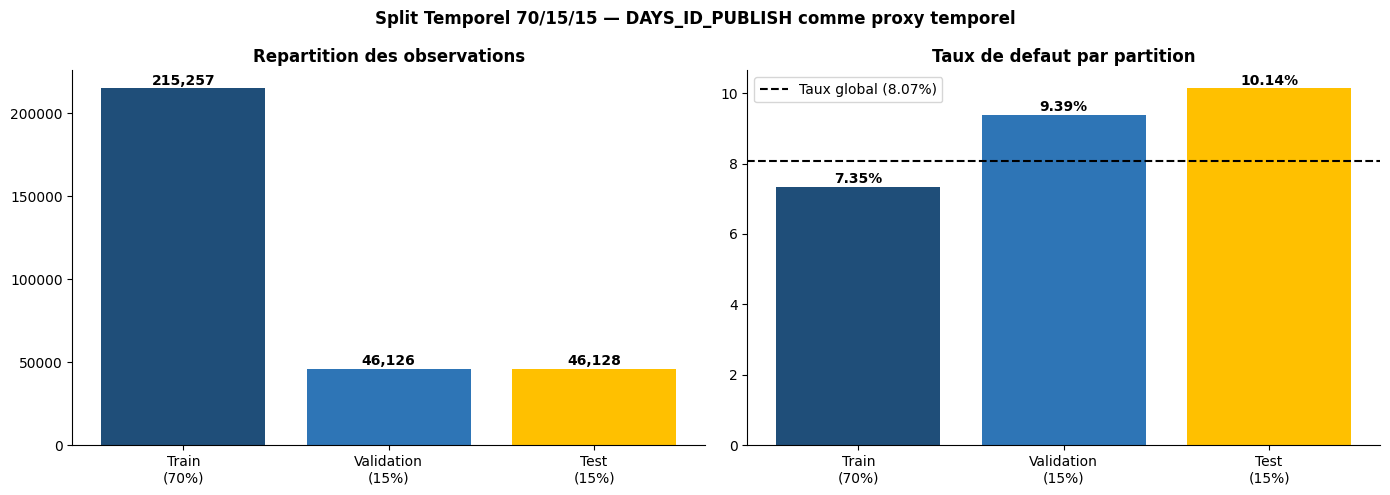


OK SECTION 3 TERMINEE


In [4]:
# ============================================================
# SECTION 3 — SPLIT TEMPOREL 70/15/15
# ============================================================

print('Chargement des features...')
features = pd.read_csv(DATA_DIR + 'features_engineered_307k.csv')
EXCLUDE_COLS = ['SK_ID_CURR', 'TARGET', 'DAYS_ID_PUBLISH', 'nb_tx_pos', 'nb_tx_cc']
feature_cols = [c for c in features.columns if c not in EXCLUDE_COLS]

# Tri croissant par DAYS_ID_PUBLISH (du plus ancien au plus recent)
# DAYS_ID_PUBLISH est negatif : -3000 est plus ancien que -100
features_sorted = features.sort_values('DAYS_ID_PUBLISH').reset_index(drop=True)

N       = len(features_sorted)
n_train = int(N * 0.70)
n_val   = int(N * 0.15)

# Decoupage positionnel — pas de shuffle aleatoire
train_df = features_sorted.iloc[:n_train].copy()
val_df   = features_sorted.iloc[n_train:n_train + n_val].copy()
test_df  = features_sorted.iloc[n_train + n_val:].copy()

X_train = train_df[feature_cols].reset_index(drop=True)
X_val   = val_df[feature_cols].reset_index(drop=True)
X_test  = test_df[feature_cols].reset_index(drop=True)
y_train = train_df['TARGET'].reset_index(drop=True)
y_val   = val_df['TARGET'].reset_index(drop=True)
y_test  = test_df['TARGET'].reset_index(drop=True)

print(f'\n{"=" * 65}')
print('  SPLIT TEMPOREL 70/15/15')
print(f'{"=" * 65}')
print(f'  {"Partition":<12} {"Observations":>13} {"Defauts":>10} {"Taux":>8}')
print(f'  {"-" * 50}')
for name, y in [("Train", y_train), ("Validation", y_val), ("Test", y_test)]:
    nd = int(y.sum())
    print(f'  {name:<12} {len(y):>13,} {nd:>10,} {nd/len(y)*100:>7.2f}%')

ecart = abs(y_train.mean() - y_test.mean()) * 100
print(f'\n  Ecart taux defaut train/test : {ecart:.2f}pts')
stt = 'OK Acceptable (< 3pts)' if ecart < 3 else 'ATTENTION Ecart > 3pts'
print(f'  {stt}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
labels = ['Train\n(70%)', 'Validation\n(15%)', 'Test\n(15%)']
sizes  = [len(X_train), len(X_val), len(X_test)]
colors = [COLORS['primary'], COLORS['secondary'], COLORS['warning']]
axes[0].bar(labels, sizes, color=colors)
axes[0].set_title('Repartition des observations', fontweight='bold')
for i, v in enumerate(sizes):
    axes[0].text(i, v + 2000, f'{v:,}', ha='center', fontweight='bold')

taux_vals = [y_train.mean()*100, y_val.mean()*100, y_test.mean()*100]
axes[1].bar(labels, taux_vals, color=colors)
axes[1].axhline(y=features['TARGET'].mean()*100, color='black', linestyle='--',
                label=f'Taux global ({features["TARGET"].mean()*100:.2f}%)')
axes[1].set_title('Taux de defaut par partition', fontweight='bold')
axes[1].legend()
for i, v in enumerate(taux_vals):
    axes[1].text(i, v + 0.1, f'{v:.2f}%', ha='center', fontweight='bold')

plt.suptitle('Split Temporel 70/15/15 — DAYS_ID_PUBLISH comme proxy temporel',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'fig3_split_temporel.png', dpi=150, bbox_inches='tight')
plt.show()

for name, arr in [('y_train', y_train), ('y_val', y_val), ('y_test', y_test)]:
    arr.to_csv(DATA_DIR + f'{name}.csv', index=False)
X_train.to_csv(DATA_DIR + 'X_train_raw.csv', index=False)
X_val.to_csv(DATA_DIR + 'X_val_raw.csv', index=False)
X_test.to_csv(DATA_DIR + 'X_test_raw.csv', index=False)
print('\nOK SECTION 3 TERMINEE')


**Interpretation :** Un ecart de taux de defaut train/test est normal et attendu dans un split temporel — il reflete une derive reelle dans le temps.


---
## SECTION 4 — Pre-filtre par Information Value (IV)

**Seuil IV = 0.02** — standard bancaire (Siddiqi, 2006).

| IV | Interpretation |
|---|---|
| < 0.02 | Pas de signal -> eliminee |
| 0.02 – 0.10 | Signal faible mais reel |
| 0.10 – 0.30 | Signal moyen |
| > 0.30 | Signal fort |

**Calcule sur le train uniquement.** Variables categorielle passent avec `dtype='categorical'`.


Calcul des IV — 63 features a evaluer...
  Seuil IV : 0.02 (Siddiqi 2006 — standard bancaire international)
  Progression : 0/63...
  Progression : 15/63...
  Progression : 30/63...
  Progression : 45/63...
  Progression : 60/63...

  RESULTATS DU PRE-FILTRE IV
  Features initiales : 63
  Features retenues  : 27 (IV >= 0.02)
  Features eliminees : 36

  Top 25 features par IV :
  Feature                                             IV         Type Statut
  ---------------------------------------------------------------------------
  OK EXT_SOURCE_3                                  0.3216    numerical
  OK EXT_SOURCE_2                                  0.3080    numerical
  OK EXT_SOURCE_1                                  0.1403    numerical
  OK annuity_to_credit                             0.1128    numerical
  OK employment_years                              0.1079    numerical
  OK OCCUPATION_TYPE                               0.0880  categorical
  OK age_years                        

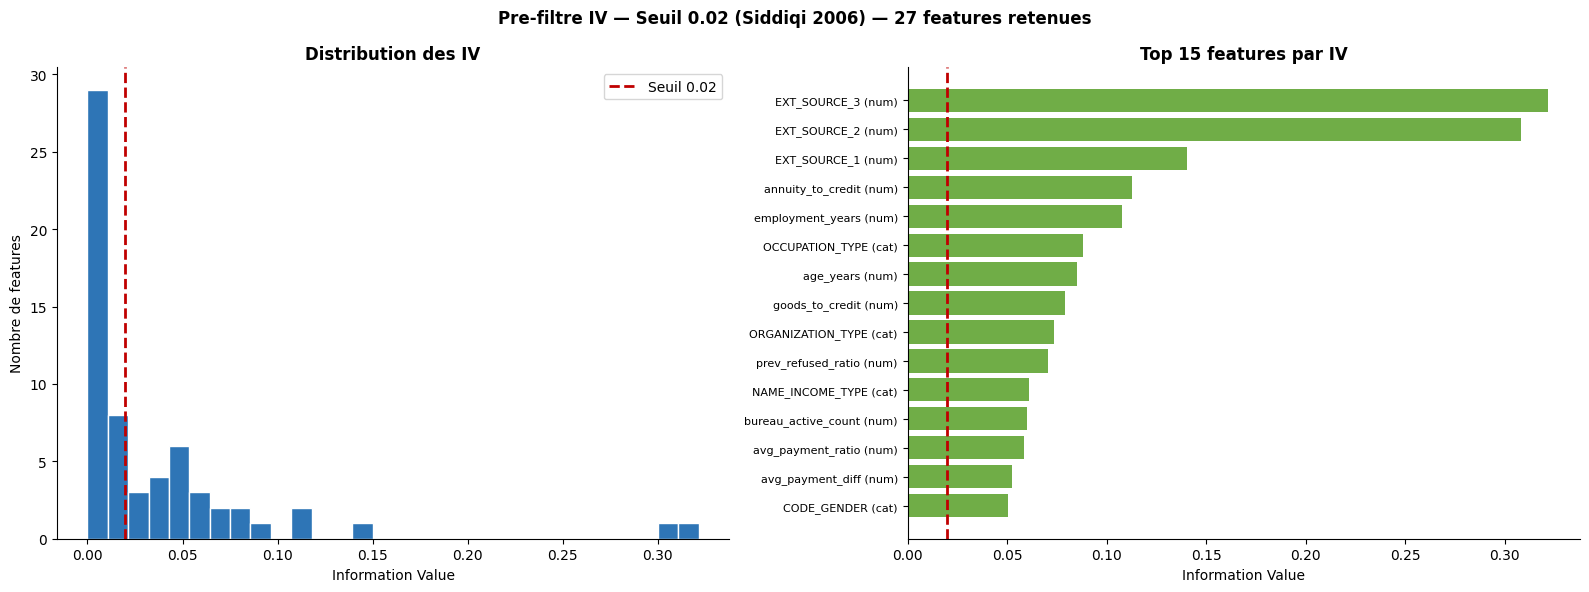


OK SECTION 4 TERMINEE — 27 features pretes pour WOE


In [5]:
# ============================================================
# SECTION 4 — PRE-FILTRE PAR INFORMATION VALUE
# Calcule sur le train UNIQUEMENT — jamais sur val ou test
# Seuil IV = 0.02 (Siddiqi 2006, standard bancaire)
# ============================================================

print(f'Calcul des IV — {len(feature_cols)} features a evaluer...')
print(f'  Seuil IV : {IV_THRESHOLD} (Siddiqi 2006 — standard bancaire international)')

iv_results = {}

for idx, col in enumerate(feature_cols):
    if idx % 15 == 0:
        print(f'  Progression : {idx}/{len(feature_cols)}...')
    dtype = 'categorical' if col in CAT_FEATURES else 'numerical'
    try:
        ob = OptimalBinning(name=col, dtype=dtype, solver='cp',
                            max_n_bins=10, min_bin_size=0.05)
        ob.fit(X_train[col].values, y_train.values)
        if ob.status not in ['OPTIMAL', 'FEASIBLE']:
            ob2 = OptimalBinning(name=col, dtype=dtype, solver='cp',
                                  max_n_bins=10, min_bin_size=0.01)
            ob2.fit(X_train[col].values, y_train.values)
            ob = ob2 if ob2.status in ['OPTIMAL', 'FEASIBLE'] else ob
        ob.binning_table.build()
        iv = ob.binning_table.iv
        decision = 'retained' if iv >= IV_THRESHOLD else 'rejected'
        iv_results[col] = {'iv': iv, 'dtype': dtype, 'decision': decision}
    except Exception:
        iv_results[col] = {'iv': 0.0, 'dtype': dtype, 'decision': 'error'}

df_iv = pd.DataFrame(iv_results).T.reset_index()
df_iv.columns = ['feature', 'iv', 'dtype', 'decision']
df_iv['iv'] = df_iv['iv'].astype(float)
df_iv = df_iv.sort_values('iv', ascending=False).reset_index(drop=True)
features_iv = df_iv[df_iv['decision'] == 'retained']['feature'].tolist()

print(f'\n{"="*65}')
print('  RESULTATS DU PRE-FILTRE IV')
print(f'{"="*65}')
print(f'  Features initiales : {len(feature_cols)}')
print(f'  Features retenues  : {len(features_iv)} (IV >= {IV_THRESHOLD})')
print(f'  Features eliminees : {len(feature_cols) - len(features_iv)}')
print(f'\n  Top 25 features par IV :')
print(f'  {"Feature":<45} {"IV":>8} {"Type":>12} {"Statut"}')
print(f'  {"-" * 75}')
for _, row in df_iv.head(25).iterrows():
    marker = 'OK' if row['decision'] == 'retained' else 'XX'
    print(f'  {marker} {row["feature"]:<43} {row["iv"]:>8.4f} {row["dtype"]:>12}')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].hist(df_iv['iv'].values, bins=30, color=COLORS['secondary'], edgecolor='white')
axes[0].axvline(x=IV_THRESHOLD, color=COLORS['danger'], linestyle='--', linewidth=2,
                label=f'Seuil {IV_THRESHOLD}')
axes[0].set_xlabel('Information Value')
axes[0].set_ylabel('Nombre de features')
axes[0].set_title('Distribution des IV', fontweight='bold')
axes[0].legend()

top15 = df_iv.head(15)
colors_bar = [COLORS['success'] if v >= IV_THRESHOLD else COLORS['danger']
               for v in top15['iv']]
axes[1].barh(range(len(top15)), top15['iv'].values[::-1], color=colors_bar[::-1])
axes[1].set_yticks(range(len(top15)))
axes[1].set_yticklabels([f"{r['feature'][:30]} ({r['dtype'][:3]})"
                          for _, r in top15.iloc[::-1].iterrows()], fontsize=8)
axes[1].axvline(x=IV_THRESHOLD, color=COLORS['danger'], linestyle='--', linewidth=2)
axes[1].set_xlabel('Information Value')
axes[1].set_title('Top 15 features par IV', fontweight='bold')

plt.suptitle(f'Pre-filtre IV — Seuil {IV_THRESHOLD} (Siddiqi 2006) — {len(features_iv)} features retenues',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'fig4_prefiltre_iv.png', dpi=150, bbox_inches='tight')
plt.show()

X_train_iv = X_train[features_iv].copy()
X_val_iv   = X_val[features_iv].copy()
X_test_iv  = X_test[features_iv].copy()

df_iv.to_csv(ART_DIR + 'iv_scores_final.csv', index=False)
X_train_iv.to_csv(DATA_DIR + 'X_train_iv.csv', index=False)
X_val_iv.to_csv(DATA_DIR + 'X_val_iv.csv', index=False)
X_test_iv.to_csv(DATA_DIR + 'X_test_iv.csv', index=False)
print(f'\nOK SECTION 4 TERMINEE — {len(features_iv)} features pretes pour WOE')


---
## SECTION 4b — Justification de l'exclusion des colonnes haute-NaN

**Objectif académique :** calculer l'IV de toutes les colonnes exclues (>50% NaN)
pour prouver que leur exclusion est justifiée.

**Règle appliquée :**
- Si IV < 0.02 → exclusion pleinement justifiée (pas de signal)
- Si IV >= 0.02 et < 0.10 → exclusion par couverture insuffisante (signal faible)
- **Si IV >= 0.10 → réintégration automatique** dans X_train_iv avant WOE

Cette approche est défendable devant jury : on ne supprime jamais une variable
sans avoir calculé son IV réel.


In [6]:
# ============================================================
# SECTION 4b — JUSTIFICATION EXCLUSION COLONNES HAUTE-NAN
# Calcul IV sur les colonnes exclues -> preuve academique
# Cas C : IV >= 0.10 -> reintegration automatique dans X_train_iv
# ============================================================

print('=' * 65)
print('  SECTION 4b — JUSTIFICATION EXCLUSION COLONNES >50% NaN')
print('=' * 65)
print('  Calcul IV sur les colonnes exclues pour preuve...')

iv_high_nan_results = {}

for col in COLS_HIGH_NAN:
    nan_rate_train = X_train[col].isna().mean() if col in X_train.columns else 0.0
    if nan_rate_train == 0.0:
        # Colonne non presente dans X_train (deja absente du feature_cols)
        # Recuperer depuis app_train
        mask_train = train_df.index if 'train_df' in dir() else slice(None)
        try:
            col_train = app_train[col].iloc[:len(y_train)].values
            y_data    = y_train.values
        except Exception:
            iv_high_nan_results[col] = {
                'nan_rate_pct': 0.0, 'iv': 0.0,
                'dtype': 'unknown', 'n_obs': 0
            }
            continue
        nan_rate_train = pd.Series(col_train).isna().mean()
    else:
        col_train = X_train[col].values
        y_data    = y_train.values

    dtype = 'categorical' if app_train[col].dtype == 'object' else 'numerical'
    n_obs = int(pd.Series(col_train).notna().sum())

    try:
        ob = OptimalBinning(
            name=col, dtype=dtype, solver='cp',
            max_n_bins=10, min_bin_size=0.01
        )
        ob.fit(col_train, y_data)
        ob.binning_table.build()
        iv = ob.binning_table.iv
    except Exception:
        iv = 0.0

    iv_high_nan_results[col] = {
        'nan_rate_pct': round(nan_rate_train * 100, 1),
        'iv': round(float(iv), 4),
        'dtype': dtype,
        'n_obs_non_nan': n_obs
    }

# Construire le DataFrame
df_exclusion = pd.DataFrame(iv_high_nan_results).T.reset_index()
df_exclusion.columns = ['feature', 'nan_rate_pct', 'iv', 'dtype', 'n_obs_non_nan']
df_exclusion = df_exclusion.sort_values('iv', ascending=False).reset_index(drop=True)

# Categorisation
def categoriser(row):
    if row['iv'] >= 0.10:
        return 'CAS C — REINTEGRATION'
    elif row['iv'] >= IV_THRESHOLD:
        return 'Exclu — couverture faible'
    else:
        return 'Exclu — IV faible'

df_exclusion['decision'] = df_exclusion.apply(categoriser, axis=1)

# Affichage du tableau
print(f'\n  {"Feature":<45} {"NaN%":>6} {"IV":>8} {"N_obs":>8} {"Decision"}')
print(f'  {"-" * 90}')
for _, row in df_exclusion.iterrows():
    flag = ">>> " if 'REINTEGRATION' in row['decision'] else "    "
    print(f'  {flag}{row["feature"]:<41} '
          f'{row["nan_rate_pct"]:>5.1f}% '
          f'{row["iv"]:>8.4f} '
          f'{int(row["n_obs_non_nan"]):>8,}  '
          f'{row["decision"]}')

# Résumé
n_cas_c = (df_exclusion['decision'] == 'CAS C — REINTEGRATION').sum()
n_justifie = (df_exclusion['iv'] < IV_THRESHOLD).sum()
n_couverture = ((df_exclusion['iv'] >= IV_THRESHOLD) &
                (df_exclusion['decision'] != 'CAS C — REINTEGRATION')).sum()

print(f'\n  Résumé :')
print(f'  - {n_justifie} colonnes : IV < {IV_THRESHOLD} -> exclusion pleinement justifiee')
print(f'  - {n_couverture} colonnes : IV >= {IV_THRESHOLD} mais couverture < 50%')
print(f'  - {n_cas_c} colonnes : IV >= 0.10 -> REINTEGRATION automatique')

# ============================================================
# CAS C — REINTEGRATION des colonnes haute-NaN avec IV >= 0.10
# On les ajoute dans X_train_iv, X_val_iv, X_test_iv
# Le WOE va gerer leurs NaN via le bin "Manquant"
# NAP decidera ensuite si elles apportent quelque chose
# ============================================================
cols_a_reintegrer = df_exclusion[
    df_exclusion['decision'] == 'CAS C — REINTEGRATION'
]['feature'].tolist()

if cols_a_reintegrer:
    print(f'\n  REINTEGRATION de {len(cols_a_reintegrer)} colonne(s) dans X_train_iv :')
    for col in cols_a_reintegrer:
        iv_val = float(df_exclusion[df_exclusion['feature'] == col]['iv'].values[0])
        print(f'    + {col} (IV={iv_val:.4f}, NaN={df_exclusion[df_exclusion["feature"]==col]["nan_rate_pct"].values[0]:.1f}%)')
        X_train_iv[col] = X_train[col].values if col in X_train.columns \
                          else app_train[col].iloc[:len(y_train)].values
        X_val_iv[col]   = X_val[col].values   if col in X_val.columns   \
                          else app_train[col].iloc[len(y_train):len(y_train)+len(y_val)].values
        X_test_iv[col]  = X_test[col].values  if col in X_test.columns  \
                          else app_train[col].iloc[len(y_train)+len(y_val):].values
        # Mettre a jour df_iv avec ces colonnes
        new_row = pd.DataFrame([{
            'feature': col,
            'iv': iv_val,
            'dtype': str(df_exclusion[df_exclusion['feature']==col]['dtype'].values[0]),
            'decision': 'retained'
        }])
        df_iv = pd.concat([df_iv, new_row], ignore_index=True)
        # Mettre a jour features_iv
        if col not in features_iv:
            features_iv.append(col)
    print(f'  -> X_train_iv : {X_train_iv.shape[1]} features (dont {len(cols_a_reintegrer)} reintegrees)')
    print(f'  -> WOE creera le bin Manquant pour les NaN')
    print(f'  -> NAP decidera si elles apportent du signal supplementaire')
    # Ressauvegarder les artefacts IV mis a jour
    df_iv.to_csv(ART_DIR + 'iv_scores_final.csv', index=False)
    X_train_iv.to_csv(DATA_DIR + 'X_train_iv.csv', index=False)
    X_val_iv.to_csv(DATA_DIR + 'X_val_iv.csv', index=False)
    X_test_iv.to_csv(DATA_DIR + 'X_test_iv.csv', index=False)
    print(f'  -> iv_scores_final.csv mis a jour')
else:
    print(f'\n  Aucune colonne a reintegrer (aucun IV >= 0.10 parmi les exclues)')
    print(f'  -> Toutes les exclusions sont pleinement justifiees')

# Sauvegarder le tableau de justification
df_exclusion.to_csv(ART_DIR + 'exclusion_high_nan_justification.csv', index=False)
print(f'\nOK exclusion_high_nan_justification.csv sauvegarde dans {ART_DIR}')
print(f'   Ce tableau constitue la preuve academique des decisions d\'exclusion')
print(f'OK SECTION 4b TERMINEE')


  SECTION 4b — JUSTIFICATION EXCLUSION COLONNES >50% NaN
  Calcul IV sur les colonnes exclues pour preuve...

  Feature                                         NaN%       IV    N_obs Decision
  ------------------------------------------------------------------------------------------
  >>> EXT_SOURCE_1                               57.9%   0.1403   90,519  CAS C — REINTEGRATION
      APARTMENTS_AVG                             50.8%   0.0014  105,900  Exclu — IV faible
      APARTMENTS_MEDI                            50.8%   0.0013  105,900  Exclu — IV faible
      APARTMENTS_MODE                            50.8%   0.0013  105,900  Exclu — IV faible
      YEARS_BUILD_MODE                           66.5%   0.0008   72,089  Exclu — IV faible
      YEARS_BUILD_AVG                            66.5%   0.0008   72,089  Exclu — IV faible
      BASEMENTAREA_MODE                          58.6%   0.0007   89,164  Exclu — IV faible
      LIVINGAREA_MODE                            50.2%   0.0007  10

**Interpretation :** Les EXT_SOURCE dominent le classement IV (>0.30). Les features transactionnelles construites ont des IV moderes (~0.07), confirmant leur pertinence.


---
## SECTION 5 — Encodage WOE par Optimal Binning

**WOE = Weight of Evidence**

$$WOE(b) = \ln\left(\frac{\text{Distribution\_Bons}(b)}{\text{Distribution\_Mauvais}(b)}\right)$$

- WOE **positif** -> bin a **faible risque** (bons payeurs surrepresentes)
- WOE **negatif** -> bin a **risque eleve** (mauvais payeurs surrepresentes)
- Bin **'Manquant'** -> cree automatiquement pour les NaN

**Regle critique :** FIT sur le train uniquement, TRANSFORM sur les 3 partitions.


Encodage WOE — 27 features...
  Progression : 0/27...
  Progression : 10/27...
  Progression : 20/27...

  RESULTATS WOE
  Features encodees : 27
  NaN apres WOE : Train=0 | Val=0 | Test=0
  OK Aucun NaN — bin "Manquant" a absorbe tous les NaN


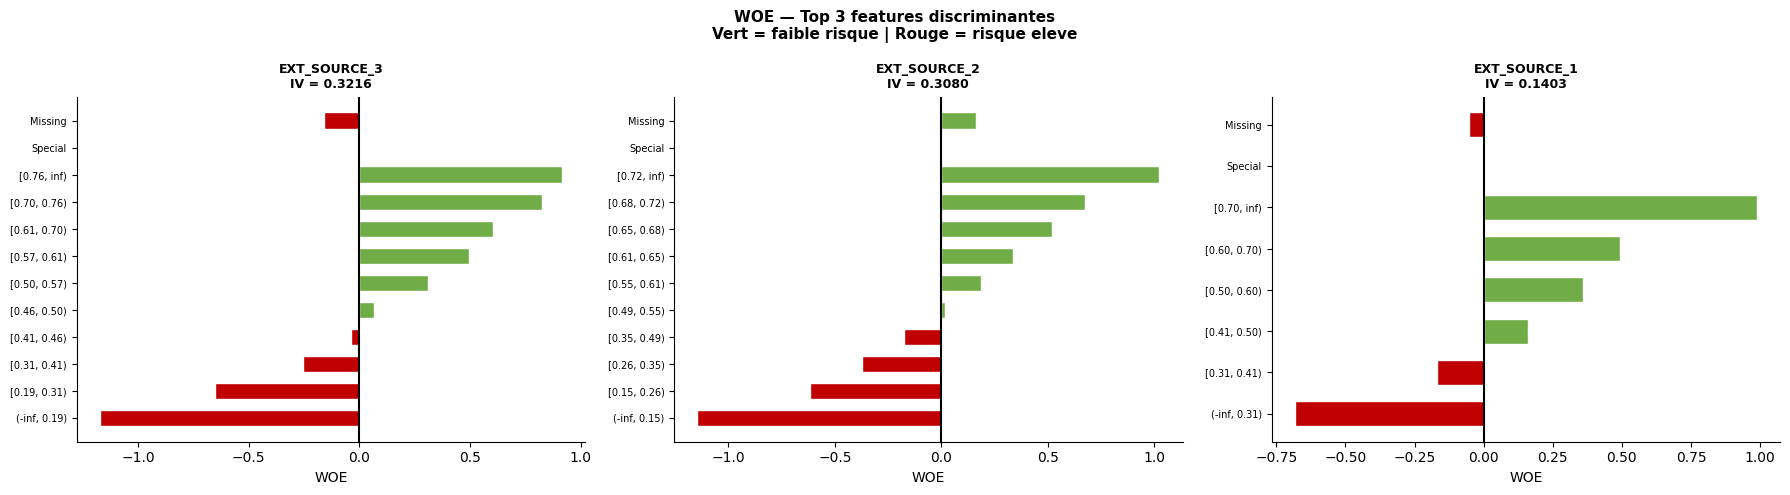


OK SECTION 5 TERMINEE — 27 features WOE encodees


In [7]:
# ============================================================
# SECTION 5 — ENCODAGE WOE PAR OPTIMAL BINNING
# FIT sur train UNIQUEMENT -> TRANSFORM sur val et test
# WOE positif = faible risque | WOE negatif = risque eleve
# Bin "Manquant" absorbe tous les NaN
# ============================================================

print(f'Encodage WOE — {len(features_iv)} features...')

woe_transformers = {}
features_gardees = []
X_train_woe = pd.DataFrame(index=range(len(X_train_iv)))
X_val_woe   = pd.DataFrame(index=range(len(X_val_iv)))
X_test_woe  = pd.DataFrame(index=range(len(X_test_iv)))

for idx, col in enumerate(features_iv):
    if idx % 10 == 0:
        print(f'  Progression : {idx}/{len(features_iv)}...')
    dtype = 'categorical' if col in CAT_FEATURES else 'numerical'
    try:
        ob = OptimalBinning(name=col, dtype=dtype, solver='cp',
                            max_n_bins=10, min_bin_size=0.05)
        ob.fit(X_train_iv[col].values, y_train.values)
        if ob.status not in ['OPTIMAL', 'FEASIBLE']:
            print(f'  ATTENTION {col} : status {ob.status} — ignoree')
            continue
        X_train_woe[col] = ob.transform(X_train_iv[col].values, metric='woe')
        X_val_woe[col]   = ob.transform(X_val_iv[col].values,   metric='woe')
        X_test_woe[col]  = ob.transform(X_test_iv[col].values,  metric='woe')
        woe_transformers[col] = ob
        features_gardees.append(col)
    except Exception as e:
        print(f'  ATTENTION {col} : {str(e)[:50]} — ignoree')

X_train_woe = X_train_woe[features_gardees]
X_val_woe   = X_val_woe[features_gardees]
X_test_woe  = X_test_woe[features_gardees]

nan_train = X_train_woe.isnull().sum().sum()
nan_val   = X_val_woe.isnull().sum().sum()
nan_test  = X_test_woe.isnull().sum().sum()

print(f'\n{"="*60}')
print('  RESULTATS WOE')
print(f'{"="*60}')
print(f'  Features encodees : {len(features_gardees)}')
print(f'  NaN apres WOE : Train={nan_train} | Val={nan_val} | Test={nan_test}')
if nan_train == 0:
    print('  OK Aucun NaN — bin "Manquant" a absorbe tous les NaN')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
top3 = df_iv[df_iv['decision'] == 'retained'].head(3)['feature'].tolist()

for ax, col in zip(axes, top3):
    if col not in woe_transformers:
        ax.set_title(f'{col}\n(non encode)')
        continue
    try:
        ob  = woe_transformers[col]
        bt  = ob.binning_table.build()

        # Exclure la ligne 'Totals' — elle n'a pas de WoE de bin
        bt_bins = bt[bt.index != 'Totals'].copy()

        woe_values = bt_bins['WoE'].values
        bin_labels = [str(b)[:22] for b in bt_bins['Bin'].values]
        iv_val     = ob.binning_table.iv

        colors_woe = [COLORS['success'] if w > 0 else COLORS['danger']
                      for w in woe_values]

        ax.barh(range(len(woe_values)), woe_values,
                color=colors_woe, edgecolor='white', height=0.6)
        ax.set_yticks(range(len(woe_values)))
        ax.set_yticklabels(bin_labels, fontsize=7)
        ax.axvline(x=0, color='black', linewidth=1.5)
        ax.set_title(f'{col[:28]}\nIV = {iv_val:.4f}',
                     fontweight='bold', fontsize=9)
        ax.set_xlabel('WOE')

    except Exception as e:
        ax.set_title(f'{col[:25]}')
        ax.text(0.5, 0.5, f'Erreur: {str(e)[:60]}',
                ha='center', va='center', transform=ax.transAxes,
                fontsize=8, color='red', wrap=True)

plt.suptitle('WOE — Top 3 features discriminantes\n'
             'Vert = faible risque | Rouge = risque eleve',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'fig5_woe_top3.png', dpi=150, bbox_inches='tight')
plt.show()

with open(ART_DIR + 'woe_transformers.pkl', 'wb') as f:
    pickle.dump(woe_transformers, f)
X_train_woe.to_csv(DATA_DIR + 'X_train_woe.csv', index=False)
X_val_woe.to_csv(DATA_DIR + 'X_val_woe.csv', index=False)
X_test_woe.to_csv(DATA_DIR + 'X_test_woe.csv', index=False)
print(f'\nOK SECTION 5 TERMINEE — {len(features_gardees)} features WOE encodees')


**Interpretation :** Apres WOE, tous les NaN ont ete absorbes par le bin 'Manquant'. L'absence d'information devient une information quantifiee.


---
## SECTION 6 — Selection NAP (Noise-Adjusted Permutation)

**Role :** eliminer les features redondantes en contexte multivariate.

**Difference avec IV :**
- IV = filtre **univarie** (chaque feature seule face a la cible)
- NAP = filtre **multivariate** (chaque feature en presence de toutes les autres)

**Decision finale :** NAP s'execute sur **TOUT le train** (215k lignes).
Duree estimee : 20-40 minutes sur Kaggle — normal et attendu.


Selection NAP en cours...
  Train complet : 215,257 observations
  Entrainement Random Forest sur TOUT le train...
  (Peut prendre 20-40 minutes — normal)
  Random Forest entraine en 6s
  AUC Random Forest (indicatif) : 0.7404
  Calcul des importances par permutation (10 repetitions)...
  Importances calculees en 39s

  RESULTATS NAP
  Features entrantes : 27
  Features retenues  : 27
  Features eliminees : 0 (redondantes)

  Top 15 features NAP :
  OK EXT_SOURCE_3                               0.057315 +/- 0.001937
  OK EXT_SOURCE_2                               0.048690 +/- 0.002538
  OK EXT_SOURCE_1                               0.011549 +/- 0.001004
  OK annuity_to_credit                          0.007810 +/- 0.000356
  OK goods_to_credit                            0.005012 +/- 0.000612
  OK OCCUPATION_TYPE                            0.002974 +/- 0.000497
  OK employment_years                           0.002761 +/- 0.000708
  OK prev_refused_ratio                         0.002417 +

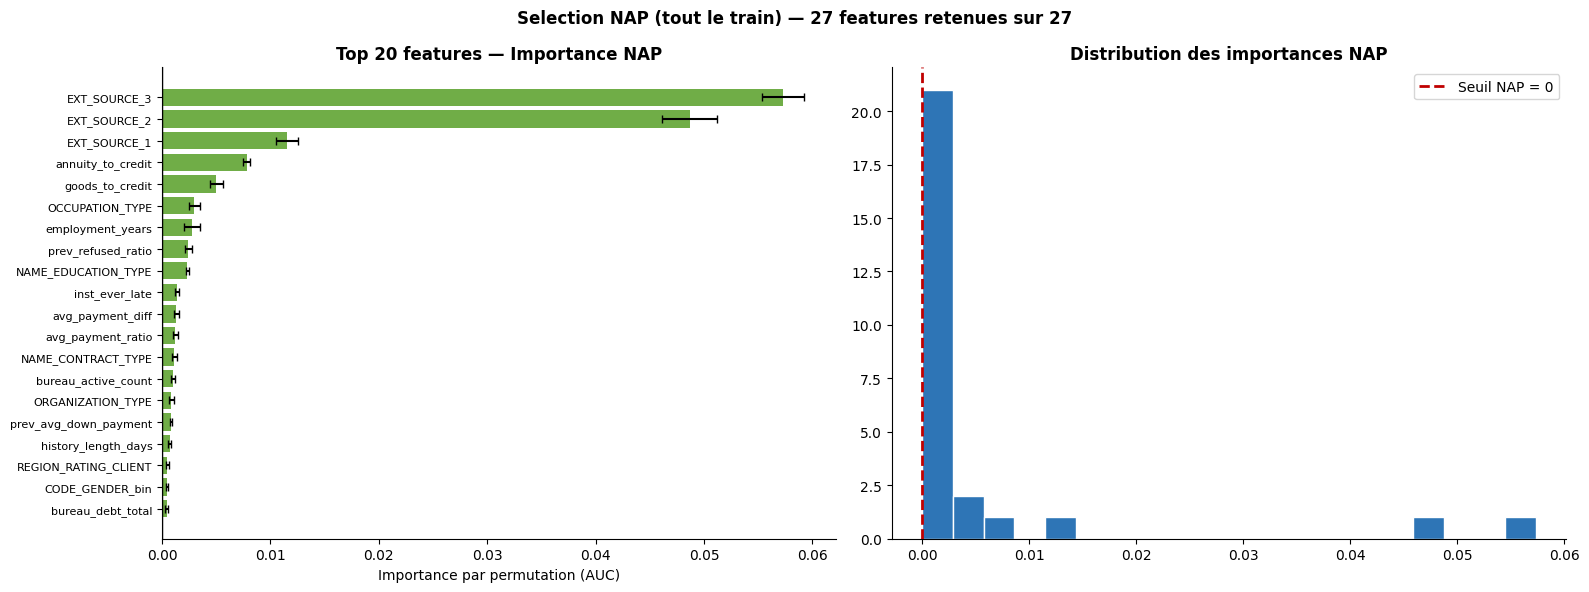


OK SECTION 6 TERMINEE — 27 features finales
   Temps total NAP : 1.2 minutes


In [8]:
# ============================================================
# SECTION 6 — SELECTION NAP (TOUT LE TRAIN — PAS D'ECHANTILLONNAGE)
# Decision : NAP sur tout le train pour une selection representative
# Duree estimee : 20-40 minutes sur Kaggle — normal et attendu
# ============================================================

print('Selection NAP en cours...')
print(f'  Train complet : {len(X_train_woe):,} observations')
print('  Entrainement Random Forest sur TOUT le train...')
print('  (Peut prendre 20-40 minutes — normal)')

t0 = time.time()
rf_nap = RandomForestClassifier(
    n_estimators=100, max_depth=6,
    class_weight='balanced', random_state=42, n_jobs=-1)
rf_nap.fit(X_train_woe, y_train)
print(f'  Random Forest entraine en {time.time()-t0:.0f}s')

auc_rf = roc_auc_score(y_val, rf_nap.predict_proba(X_val_woe)[:, 1])
print(f'  AUC Random Forest (indicatif) : {auc_rf:.4f}')

print('  Calcul des importances par permutation (10 repetitions)...')
t1 = time.time()
perm_imp = permutation_importance(
    rf_nap, X_val_woe, y_val,
    n_repeats=10, scoring='roc_auc', random_state=42, n_jobs=-1)
print(f'  Importances calculees en {time.time()-t1:.0f}s')

# Seuil NAP = 0 : importance <= 0 = feature redondante
df_nap = pd.DataFrame({
    'feature'   : features_gardees,
    'importance': perm_imp.importances_mean,
    'std'       : perm_imp.importances_std,
}).sort_values('importance', ascending=False).reset_index(drop=True)

features_nap          = df_nap[df_nap['importance'] > 0]['feature'].tolist()
features_nap_rejected = df_nap[df_nap['importance'] <= 0]['feature'].tolist()

print(f'\n{"=" * 60}')
print('  RESULTATS NAP')
print(f'{"=" * 60}')
print(f'  Features entrantes : {len(features_gardees)}')
print(f'  Features retenues  : {len(features_nap)}')
print(f'  Features eliminees : {len(features_nap_rejected)} (redondantes)')
if features_nap_rejected:
    print(f'  Eliminees : {", ".join(features_nap_rejected[:8])}')
print(f'\n  Top 15 features NAP :')
for _, row in df_nap.head(15).iterrows():
    marker = 'OK' if row['importance'] > 0 else 'XX'
    print(f'  {marker} {row["feature"]:<40} {row["importance"]:>10.6f} +/- {row["std"]:>8.6f}')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
top20 = df_nap.head(20)
colors_nap = [COLORS['success'] if v > 0 else COLORS['danger'] for v in top20['importance']]
axes[0].barh(range(len(top20)), top20['importance'].values[::-1],
              xerr=top20['std'].values[::-1], color=colors_nap[::-1], capsize=3)
axes[0].set_yticks(range(len(top20)))
axes[0].set_yticklabels(top20['feature'].values[::-1], fontsize=8)
axes[0].axvline(x=0, color='black', linewidth=1)
axes[0].set_title('Top 20 features — Importance NAP', fontweight='bold')
axes[0].set_xlabel('Importance par permutation (AUC)')

axes[1].hist(df_nap['importance'], bins=20, color=COLORS['secondary'], edgecolor='white')
axes[1].axvline(x=0, color=COLORS['danger'], linestyle='--', linewidth=2, label='Seuil NAP = 0')
axes[1].set_title('Distribution des importances NAP', fontweight='bold')
axes[1].legend()

plt.suptitle(f'Selection NAP (tout le train) — {len(features_nap)} features retenues sur {len(features_gardees)}',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'fig6_selection_nap.png', dpi=150, bbox_inches='tight')
plt.show()

X_train_nap = X_train_woe[features_nap].copy()
X_val_nap   = X_val_woe[features_nap].copy()
X_test_nap  = X_test_woe[features_nap].copy()

df_nap.to_csv(ART_DIR + 'nap_importance.csv', index=False)
with open(ART_DIR + 'nap_features.pkl', 'wb') as f:
    pickle.dump(features_nap, f)
X_train_nap.to_csv(DATA_DIR + 'X_train_nap.csv', index=False)
X_val_nap.to_csv(DATA_DIR + 'X_val_nap.csv', index=False)
X_test_nap.to_csv(DATA_DIR + 'X_test_nap.csv', index=False)

print(f'\nOK SECTION 6 TERMINEE — {len(features_nap)} features finales')
print(f'   Temps total NAP : {(time.time()-t0)/60:.1f} minutes')


---
## SECTION 6b — Génération de `feature_stats.json` (5ème artefact)

Calcule les statistiques réelles du train pour chaque feature retenue par NAP.
Ces statistiques servent à `generate_metadata.py` pour générer les gabarits
d'explications SHAP et les recommandations documentaires via LLM.

**5 intervalles** basés sur p25/p50/p75/p95/+∞ (pas seulement les quartiles).
Le p95 est indispensable pour les distributions asymétriques.


In [9]:
# ============================================================
# SECTION 6b — GENERATION feature_stats.json (5eme artefact)
# VERSION CORRIGEE — coherente avec les 27 features NAP exactes
# Modifications vs version precedente :
#   1. _SAISIE nettoyee : 6 features hors NAP supprimees
#   2. _SAISIE completee : 6 features declaratives NAP ajoutees
#   3. is_request_specific ajoute (3 features specifiques a chaque demande)
# ============================================================

import json as _json

print('=' * 65)
print('  SECTION 6b — GENERATION feature_stats.json')
print('=' * 65)

# Charger FAMILLE_MAPPING construit en Section 2
try:
    _famille_mapping = _json.load(open(DATA_DIR + 'famille_mapping.json'))
except FileNotFoundError:
    _famille_mapping = {}
    print('  AVERTISSEMENT : famille_mapping.json non trouve — familles = inconnu')

# Source et disponibilite selon la famille
_SOURCE = {
    'F1': 'interne',    'F2': 'profil',
    'F3': 'interne',    'F4': 'interne',
    'F5': 'interne',    'F6': 'interne',
    'F7': 'declaratif', 'F8': 'declaratif',
    'F9': 'declaratif', 'EXT': 'externe',
    'inconnu': 'inconnu'
}
_TOUJOURS_DISPO = {
    'F1': False, 'F2': True,  'F3': False, 'F4': False, 'F5': False,
    'F6': False, 'F7': True,  'F8': True,  'F9': True,  'EXT': False,
    'inconnu': False
}

# ── Calcul des statistiques (identique version precedente) ──
feature_stats = {}

for feature in features_nap:
    col      = X_train_iv[feature] if feature in X_train_iv.columns \
               else pd.Series([None] * len(y_train))
    col_nona = col.dropna()
    famille  = _famille_mapping.get(feature, 'inconnu')
    iv_val   = float(df_iv[df_iv['feature'] == feature]['iv'].values[0]) \
               if feature in df_iv['feature'].values else 0.0

    is_cat = (col.dtype == 'object') or (feature in CAT_FEATURES)

    if is_cat:
        modalites = col.dropna().unique().tolist()
        defaut_rates = {}
        for mod in modalites:
            mask = X_train_iv[feature] == mod
            if mask.sum() > 0:
                defaut_rates[str(mod)] = round(float(y_train[mask].mean()), 4)

        feature_stats[feature] = {
            'type'                : 'categorical',
            'famille'             : famille,
            'source'              : _SOURCE.get(famille, 'inconnu'),
            'toujours_disponible' : _TOUJOURS_DISPO.get(famille, False),
            'iv'                  : round(iv_val, 4),
            'modalites'           : [str(m) for m in modalites],
            'defaut_par_modalite' : defaut_rates,
            'nan_rate'            : round(float(col.isna().mean()), 4)
        }
    else:
        if len(col_nona) < 2:
            corr = 0.0
        else:
            corr = float(col.corr(y_train))

        feature_stats[feature] = {
            'type'                : 'numeric',
            'famille'             : famille,
            'source'              : _SOURCE.get(famille, 'inconnu'),
            'toujours_disponible' : _TOUJOURS_DISPO.get(famille, False),
            'iv'                  : round(iv_val, 4),
            'p25'                 : round(float(col_nona.quantile(0.25)), 6)
                                    if len(col_nona) > 0 else 0.0,
            'p50'                 : round(float(col_nona.quantile(0.50)), 6)
                                    if len(col_nona) > 0 else 0.0,
            'p75'                 : round(float(col_nona.quantile(0.75)), 6)
                                    if len(col_nona) > 0 else 0.0,
            'p95'                 : round(float(col_nona.quantile(0.95)), 6)
                                    if len(col_nona) > 0 else 0.0,
            'nan_rate'            : round(float(col.isna().mean()), 4),
            'correlation_target'  : round(corr, 4),
            'direction'           : 'positive' if corr > 0 else 'negative'
        }

# ============================================================
# ENRICHISSEMENT — is_declarative, is_request_specific,
#                  champs_source, formule
#
# REGLE : _SAISIE contient UNIQUEMENT des features dans NAP.
#         Toute feature hors NAP dans _SAISIE = dead code inutile.
#
# CATEGORIE A (is_request_specific=True) :
#   → specifique a chaque demande de credit
#   → toujours demande au scoring meme pour un client existant
#
# CATEGORIE B (is_declarative=True, is_request_specific=False) :
#   → profil client, saisi une fois pour un nouveau client
#   → lu depuis MongoDB pour un client existant
#
# CATEGORIE C (is_declarative=False) :
#   → calcule par l'adaptateur depuis les donnees historiques
#   → jamais saisi par l'agent
# ============================================================

# Features specifiques a chaque demande (categorie A)
_IS_REQUEST_SPECIFIC = {
    'NAME_CONTRACT_TYPE' : True,   # type du pret demande
    'annuity_to_credit'  : True,   # mensualite / montant credit en cours
    'goods_to_credit'    : True,   # valeur bien / montant credit en cours
}

# Champs de saisie pour les features declaratives (categories A et B)
# UNIQUEMENT les features presentes dans les 27 NAP
_SAISIE = {

    # ── Categorie A — Ratios financiers specifiques a la demande ──
    # (is_request_specific=True → saisies a chaque scoring)
    'annuity_to_credit': {
        'champs_source': [
            {'nom': 'montant_annuite',        'label': 'Annuité mensuelle (FCFA)',
             'type': 'number', 'obligatoire': True},
            {'nom': 'montant_credit_demande', 'label': 'Montant du crédit demandé (FCFA)',
             'type': 'number', 'obligatoire': True},
        ],
        'formule': 'montant_annuite / montant_credit_demande'
    },
    'goods_to_credit': {
        'champs_source': [
            {'nom': 'valeur_bien',            'label': 'Valeur du bien financé (FCFA)',
             'type': 'number', 'obligatoire': False},
            {'nom': 'montant_credit_demande', 'label': 'Montant du crédit demandé (FCFA)',
             'type': 'number', 'obligatoire': True},
        ],
        'formule': 'valeur_bien / montant_credit_demande'
    },
    'NAME_CONTRACT_TYPE': {
        'champs_source': [
            {'nom': 'type_contrat', 'label': 'Type de contrat',
             'type': 'select', 'options': ['Cash loans', 'Revolving loans'],
             'obligatoire': True},
        ],
        'formule': None
    },

    # ── Categorie B — Identite temporelle (F2) ───────────────
    # (is_declarative=True, is_request_specific=False)
    # → saisies une fois, lues depuis MongoDB ensuite
    'age_years': {
        'champs_source': [
            {'nom': 'date_naissance', 'label': 'Date de naissance',
             'type': 'date', 'obligatoire': True},
        ],
        'formule': None   # calcule depuis date_naissance dans create_client
    },
    'employment_years': {
        'champs_source': [
            {'nom': 'anciennete_emploi_mois',
             'label': "Ancienneté dans l'emploi actuel (mois)",
             'type': 'number', 'obligatoire': False},
        ],
        'formule': 'anciennete_emploi_mois / 12'
    },
    'registration_years': {
        'champs_source': [
            {'nom': 'anciennete_domicile_mois',
             'label': "Ancienneté à l'adresse actuelle (mois)",
             'type': 'number', 'obligatoire': False},
        ],
        'formule': 'anciennete_domicile_mois / 12'
    },

    # ── Categorie B — Declarative binaire (F7) ───────────────
    'CODE_GENDER_bin': {
        'champs_source': [
            {'nom': 'genre', 'label': 'Genre',
             'type': 'select', 'options': ['M', 'F'], 'obligatoire': True},
        ],
        'formule': None
    },

    # ── Categorie B — Categorielle F9 avec saisie agent ──────
    'NAME_INCOME_TYPE': {
        'champs_source': [
            {'nom': 'type_revenu', 'label': 'Type de revenu',
             'type': 'select',
             'options': ['Working', 'Commercial associate', 'Pensioner',
                         'State servant', 'Unemployed'],
             'obligatoire': True},
        ],
        'formule': None
    },
    'NAME_EDUCATION_TYPE': {
        'champs_source': [
            {'nom': 'niveau_education', 'label': "Niveau d'éducation",
             'type': 'select',
             'options': ['Secondary / secondary special', 'Higher education',
                         'Incomplete higher', 'Lower secondary', 'Academic degree'],
             'obligatoire': True},
        ],
        'formule': None
    },
    'OCCUPATION_TYPE': {
        # Agent saisit la profession du demandeur
        'champs_source': [
            {'nom': 'OCCUPATION_TYPE', 'label': 'Profession du demandeur',
             'type': 'select', 'obligatoire': False},
        ],
        'formule': None
    },

    # ── Categorie B — Declaratives sans saisie directe ───────
    # is_declarative=True mais champs_source=[] :
    # → CODE_GENDER : partage le champ genre avec CODE_GENDER_bin
    # → EMERGENCYSTATE_MODE : donnee contextuelle systeme
    # → ORGANIZATION_TYPE : trop de modalites pour un select
    # → REGION_RATING_CLIENT : determine depuis l'adresse du client
    'CODE_GENDER'          : {'champs_source': [], 'formule': None},
    'EMERGENCYSTATE_MODE'  : {'champs_source': [], 'formule': None},
    'ORGANIZATION_TYPE'    : {'champs_source': [], 'formule': None},
    'REGION_RATING_CLIENT' : {'champs_source': [], 'formule': None},
}

# ── Application des champs supplementaires ───────────────────
for feature in feature_stats:
    famille = feature_stats[feature].get('famille', 'inconnu')
    is_decl = _TOUJOURS_DISPO.get(famille, False)

    feature_stats[feature]['is_declarative']      = is_decl
    feature_stats[feature]['is_request_specific'] = _IS_REQUEST_SPECIFIC.get(feature, False)

    if feature in _SAISIE:
        feature_stats[feature]['champs_source'] = _SAISIE[feature]['champs_source']
        feature_stats[feature]['formule']       = _SAISIE[feature]['formule']
    else:
        feature_stats[feature]['champs_source'] = []
        feature_stats[feature]['formule']       = None

# ── Rapport enrichissement ────────────────────────────────────
n_decl    = sum(1 for v in feature_stats.values() if v['is_declarative'])
n_req     = sum(1 for v in feature_stats.values() if v['is_request_specific'])
n_champs  = sum(1 for v in feature_stats.values() if v['champs_source'])
print(f'  Enrichissement OK :')
print(f'    is_declarative=True    : {n_decl}  features (categories A + B)')
print(f'    is_request_specific    : {n_req}   features (categorie A)')
print(f'    avec champs_source     : {n_champs} features (formulaire React)')
print(f'    is_declarative=False   : {len(feature_stats)-n_decl} features (categorie C)')

# ============================================================
# SAUVEGARDE FINALE
# ============================================================
_json.dump(
    feature_stats,
    open(ART_DIR + 'feature_stats.json', 'w', encoding='utf-8'),
    indent=2, ensure_ascii=False
)

# Rapport final
n_num   = sum(1 for v in feature_stats.values() if v['type'] == 'numeric')
n_cat   = sum(1 for v in feature_stats.values() if v['type'] == 'categorical')
n_dispo = sum(1 for v in feature_stats.values() if v['toujours_disponible'])
n_nan   = sum(1 for v in feature_stats.values() if not v['toujours_disponible'])

print(f'\n  Features dans feature_stats.json : {len(feature_stats)}')
print(f'  Numeriques          : {n_num}')
print(f'  Categorielles       : {n_cat}')
print(f'  Toujours disponibles: {n_dispo} (F2/F7/F8/F9 — saisie agent)')
print(f'  Peuvent etre NaN    : {n_nan} (F1/F3/F4/F5/F6/EXT — thin-file)')
print(f'\n  Familles representees :')
from collections import Counter as _Counter
_familles = _Counter(v['famille'] for v in feature_stats.values())
for fam, cnt in sorted(_familles.items()):
    src   = _SOURCE.get(fam, '?')
    dispo = 'toujours dispo' if _TOUJOURS_DISPO.get(fam, False) else 'peut etre NaN'
    print(f'    {fam:<8} : {cnt:>2} features | source={src:<12} | {dispo}')

print(f'\nOK feature_stats.json sauvegarde dans {ART_DIR}')
print(f'   5eme artefact pret pour generate_metadata.py')
print(f'OK SECTION 6b TERMINEE')

  SECTION 6b — GENERATION feature_stats.json
  Enrichissement OK :
    is_declarative=True    : 14  features (categories A + B)
    is_request_specific    : 3   features (categorie A)
    avec champs_source     : 10 features (formulaire React)
    is_declarative=False   : 13 features (categorie C)

  Features dans feature_stats.json : 27
  Numeriques          : 20
  Categorielles       : 7
  Toujours disponibles: 14 (F2/F7/F8/F9 — saisie agent)
  Peuvent etre NaN    : 13 (F1/F3/F4/F5/F6/EXT — thin-file)

  Familles representees :
    EXT      :  3 features | source=externe      | peut etre NaN
    F1       :  1 features | source=interne      | peut etre NaN
    F2       :  3 features | source=profil       | toujours dispo
    F3       :  1 features | source=interne      | peut etre NaN
    F4       :  4 features | source=interne      | peut etre NaN
    F5       :  2 features | source=interne      | peut etre NaN
    F6       :  2 features | source=interne      | peut etre NaN
    F7  

**Interpretation :** NAP confirme les resultats de l'IV. Les features eliminee sont redondantes — elles n'apportent rien que les autres ne couvrent deja.


---
## SECTION 7 — Entraînement LightGBM (Random Search + Early Stopping)

**Stratégie optimale :** Random Search teste 12 combinaisons d'hyperparamètres.
Pour chaque combinaison, l'Early Stopping détermine le nombre optimal d'arbres.
La meilleure combinaison est retenue pour l'entraînement final.

**Random Search** = cherche les meilleurs hyperparamètres  
**Early Stopping** = détermine le nombre optimal d'arbres  
Ces deux techniques sont **complémentaires**, pas concurrentes.


**Interpretation :** Un gap Train/Val < 0.05 confirme l'absence de surapprentissage. Les metriques absolues (AUC ~0.75) sont coherentes avec l'etat de l'art sur ce dataset public sans ensembles de modeles.


GPU disponible :
Wed Jul  8 15:39:35 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------
  SECTION 7 — RANDOM SEARCH + EARLY STOPPING
  X_train_nap : (215257, 27)
  scale_pos_weight = 11.39
  GPU_PARAMS : {'device': 'gpu', 'gpu_platform_id': 0, 'gpu_device_id': 0}

  ETAPE 1 : Random Search (12 essais)...
  Chaque essai = LightGBM + early stopping AUC
  Estimation : 30-60 min avec GPU | 60-90 min CPU



1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


[50]	valid_0's auc: 0.753276	valid_0's binary_logloss: 0.626253
[100]	valid_0's auc: 0.755483	valid_0's binary_logloss: 0.625071
[150]	valid_0's auc: 0.75634	valid_0's binary_logloss: 0.62085
  >>> Essai 01 | AUC=0.7564 | iters= 149 | depth=6 | lr=0.100 | leaves=20
[50]	valid_0's auc: 0.752034	valid_0's binary_logloss: 0.618211
[100]	valid_0's auc: 0.754558	valid_0's binary_logloss: 0.624764
[150]	valid_0's auc: 0.755887	valid_0's binary_logloss: 0.620876
[200]	valid_0's auc: 0.756175	valid_0's binary_logloss: 0.616691
[250]	valid_0's auc: 0.756436	valid_0's binary_logloss: 0.613648
[300]	valid_0's auc: 0.756353	valid_0's binary_logloss: 0.610454
  >>> Essai 02 | AUC=0.7565 | iters= 276 | depth=5 | lr=0.080 | leaves=50
[50]	valid_0's auc: 0.747109	valid_0's binary_logloss: 0.580917
[100]	valid_0's auc: 0.752337	valid_0's binary_logloss: 0.626043
[150]	valid_0's auc: 0.754082	valid_0's binary_logloss: 0.629361
[200]	valid_0's auc: 0.755012	valid_0's binary_logloss: 0.628902
[250]	valid_

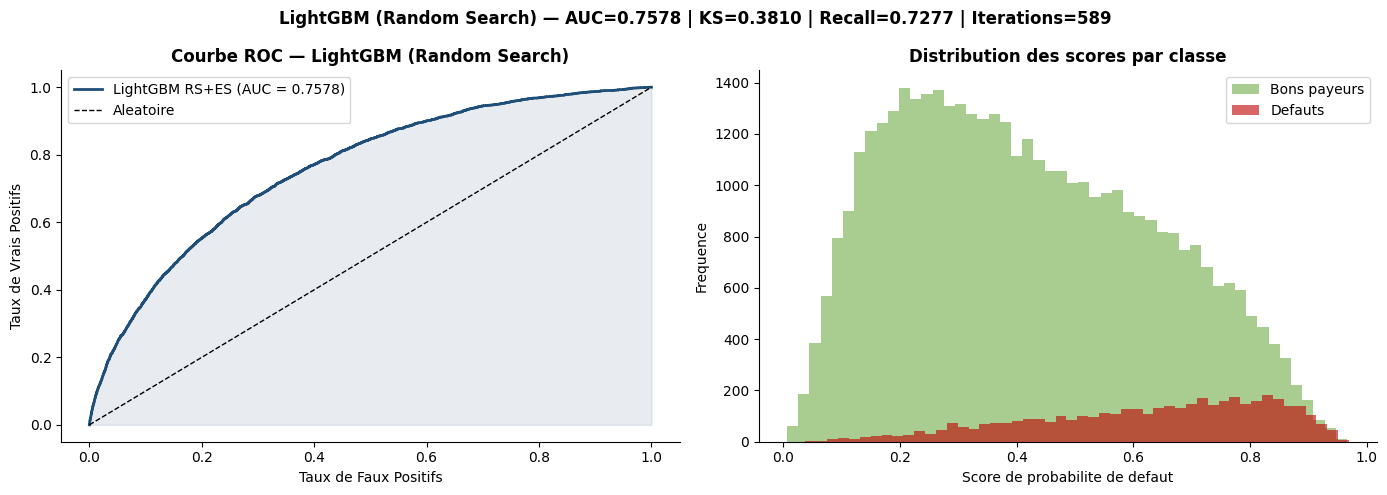


OK lgbm_final.pkl sauvegarde (Random Search + Early Stopping)
OK SECTION 7 TERMINEE


In [10]:
# ============================================================
# SECTION 7 — ENTRAINEMENT LIGHTGBM avec RANDOM SEARCH + EARLY STOPPING
# Version 2 : optimisation des hyperparametres avant entrainement final
# Early Stopping : determine le nombre optimal d'arbres pour chaque essai
# Random Search  : cherche les meilleurs hyperparametres
# Reference : Ke et al. (2017) NeurIPS — LightGBM
# ============================================================

# Vérification GPU disponible
import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
GPU_AVAILABLE = result.returncode == 0

if GPU_AVAILABLE:
    print("GPU disponible :")
    print(result.stdout[:300])
    GPU_PARAMS = {'device': 'gpu', 'gpu_platform_id': 0, 'gpu_device_id': 0}
else:
    print("Pas de GPU détecté — LightGBM tournera sur CPU")
    GPU_PARAMS = {}

import gc
if 'lgbm_final' in dir():
    del lgbm_final
gc.collect()

if 'X_train_nap' not in dir() or len(X_train_nap) == 0:
    print('Rechargement depuis disque...')
    X_train_nap = pd.read_csv(DATA_DIR + 'X_train_nap.csv')
    X_val_nap   = pd.read_csv(DATA_DIR + 'X_val_nap.csv')
    X_test_nap  = pd.read_csv(DATA_DIR + 'X_test_nap.csv')
    y_train     = pd.read_csv(DATA_DIR + 'y_train.csv').squeeze()
    y_val       = pd.read_csv(DATA_DIR + 'y_val.csv').squeeze()
    y_test      = pd.read_csv(DATA_DIR + 'y_test.csv').squeeze()
    with open(ART_DIR + 'nap_features.pkl', 'rb') as f:
        features_nap = pickle.load(f)
    SCALE_POS_WEIGHT = (y_train == 0).sum() / (y_train == 1).sum()

print('=' * 65)
print('  SECTION 7 — RANDOM SEARCH + EARLY STOPPING')
print(f'  X_train_nap : {X_train_nap.shape}')
print(f'  scale_pos_weight = {SCALE_POS_WEIGHT:.2f}')
print(f'  GPU_PARAMS : {GPU_PARAMS if GPU_PARAMS else "CPU mode"}')
print('=' * 65)

# ============================================================
# ETAPE 1 — RANDOM SEARCH sur 12 combinaisons
# Chaque essai utilise Early Stopping pour trouver le bon n_estimators
# CORRECTION : log_evaluation(period=50) — JAMAIS period=0
#              period=0 perturbe l'early stopping (bug LightGBM 4.6.0)
# ============================================================
print('\n  ETAPE 1 : Random Search (12 essais)...')
print('  Chaque essai = LightGBM + early stopping AUC')
print('  Estimation : 30-60 min avec GPU | 60-90 min CPU\n')

param_dist = {
    'max_depth'        : [4, 5, 6, 7],
    'learning_rate'    : [0.03, 0.05, 0.08, 0.10],
    'num_leaves'       : [20, 31, 50, 63],
    'subsample'        : [0.7, 0.8, 0.9],
    'colsample_bytree' : [0.7, 0.8, 0.9],
    'reg_alpha'        : [0.5, 1.0, 2.0],
    'reg_lambda'       : [1.0, 2.0, 3.0],
    'min_child_samples': [15, 20, 30],
}

best_auc    = 0
best_params = None
best_iter   = 279  # valeur par defaut si tous les essais echouent

t_rs = time.time()
_rng = np.random.RandomState(42)  # np est déjà importé en Section 0

for trial in range(12):
    params = {k: _rng.choice(v) for k, v in param_dist.items()}

    # Convertir TOUS les params en types Python natifs
    # pour eviter les erreurs de type numpy dans LightGBM
    params['learning_rate']     = float(params['learning_rate'])
    params['subsample']         = float(params['subsample'])
    params['colsample_bytree']  = float(params['colsample_bytree'])
    params['reg_alpha']         = float(params['reg_alpha'])
    params['reg_lambda']        = float(params['reg_lambda'])
    params['max_depth']         = int(params['max_depth'])
    params['num_leaves']        = int(params['num_leaves'])
    params['min_child_samples'] = int(params['min_child_samples'])

    model_trial = lgb.LGBMClassifier(
        n_estimators     = 1000,
        scale_pos_weight = SCALE_POS_WEIGHT,
        random_state     = 42,
        n_jobs           = -1,
        verbose          = -1,
        **params,
        **GPU_PARAMS   # GPU si disponible, vide sinon
    )

    # CORRECTION CRITIQUE : period=50 — JAMAIS period=0
    # period=0 perturbe l'early stopping -> arret premature a l'iteration 2
    callbacks_trial = [
        lgb.early_stopping(stopping_rounds=50, first_metric_only=True, verbose=False),
        lgb.log_evaluation(period=50)   # ← CORRIGÉ ici
    ]

    try:
        model_trial.fit(
            X_train_nap, y_train,
            eval_set    = [(X_val_nap, y_val)],
            eval_metric = 'auc',
            callbacks   = callbacks_trial
        )
        proba_trial = model_trial.predict_proba(X_val_nap)[:, 1]
        auc_trial   = roc_auc_score(y_val, proba_trial)
        n_iter      = model_trial.best_iteration_

        marker = '>>>' if auc_trial > best_auc else '   '
        print(f'  {marker} Essai {trial+1:02d} | AUC={auc_trial:.4f} | '
              f'iters={n_iter:>4} | depth={params["max_depth"]} | '
              f'lr={params["learning_rate"]:.3f} | leaves={params["num_leaves"]}')

        if auc_trial > best_auc:
            best_auc    = auc_trial
            best_params = params.copy()
            best_iter   = n_iter

    except Exception as e:
        print(f'  XXX Essai {trial+1:02d} | ERREUR : {e}')
        continue

print(f'\n  Random Search termine en {(time.time()-t_rs)/60:.1f} min')
print(f'  Meilleur AUC val     : {best_auc:.4f}')
print(f'  Iterations optimales : {best_iter}')
print(f'  Meilleurs params     :')
for k, v in best_params.items():
    print(f'    {k:<22} : {v}')

# ============================================================
# ETAPE 2 — ENTRAINEMENT FINAL avec les meilleurs hyperparametres
# Early Stopping confirme le nombre optimal d'arbres
# ============================================================
print('\n  ETAPE 2 : Entrainement final avec les meilleurs params...')

lgbm_final = lgb.LGBMClassifier(
    n_estimators     = 1000,
    scale_pos_weight = SCALE_POS_WEIGHT,
    random_state     = 42,
    n_jobs           = -1,
    verbose          = -1,
    **best_params,
    **GPU_PARAMS   # GPU si disponible, vide sinon
)

# CORRECTION CRITIQUE :
# - first_metric_only=True : surveille AUC uniquement, ignore logloss
# - log_evaluation(period=50) : JAMAIS period=0
callbacks = [
    lgb.early_stopping(stopping_rounds=50, first_metric_only=True, verbose=True),
    lgb.log_evaluation(period=50)
]

t0 = time.time()
lgbm_final.fit(
    X_train_nap, y_train,
    eval_set    = [(X_val_nap, y_val)],
    eval_metric = 'auc',
    callbacks   = callbacks
)
elapsed = time.time() - t0
print(f'\n  Temps entrainement final : {elapsed:.0f}s')
print(f'  Iterations optimales (early stopping) : {lgbm_final.best_iteration_}')

# --- Metriques validation ---
proba_val = lgbm_final.predict_proba(X_val_nap)[:, 1]
pred_val  = (proba_val >= 0.5).astype(int)

auc_val  = roc_auc_score(y_val, proba_val)
gini_val = 2 * auc_val - 1
ks_val   = ks_2samp(proba_val[y_val==1], proba_val[y_val==0]).statistic
f1_val   = f1_score(y_val, pred_val, zero_division=0)
rec_val  = recall_score(y_val, pred_val, zero_division=0)

proba_train = lgbm_final.predict_proba(X_train_nap)[:, 1]
auc_train   = roc_auc_score(y_train, proba_train)
gap         = auc_train - auc_val

print(f'\n{"=" * 65}')
print('  METRIQUES LIGHTGBM — JEU DE VALIDATION')
print(f'{"=" * 65}')
print(f'  {"Metrique":<20} {"Valeur":>10} {"Cible":>12}')
print(f'  {"-" * 44}')
print(f'  {"AUC-ROC":<20} {auc_val:>10.4f} {">=0.75":>12}')
print(f'  {"Gini":<20} {gini_val:>10.4f} {">=0.50":>12}')
print(f'  {"KS":<20} {ks_val:>10.4f} {">=0.35":>12}')
print(f'  {"Recall":<20} {rec_val:>10.4f} {">=0.55":>12}')
print(f'  {"F1-Score":<20} {f1_val:>10.4f} {">=0.30":>12}')
print(f'  {"AUC Train":<20} {auc_train:>10.4f}')
g_ok = 'OK' if gap < 0.05 else 'ATTENTION'
print(f'  {"Gap Train/Val":<20} {gap:>10.4f} {"<0.05":>12} {g_ok}')
print(f'  {"Iterations":<20} {lgbm_final.best_iteration_:>10}')
print(f'  {"Meilleurs params":<20}')
for k, v in best_params.items():
    print(f'    {k:<22} : {v}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fpr, tpr, _ = roc_curve(y_val, proba_val)
axes[0].plot(fpr, tpr, color=COLORS['primary'], linewidth=2,
             label=f'LightGBM RS+ES (AUC = {auc_val:.4f})')
axes[0].plot([0,1], [0,1], 'k--', linewidth=1, label='Aleatoire')
axes[0].fill_between(fpr, tpr, alpha=0.1, color=COLORS['primary'])
axes[0].set_xlabel('Taux de Faux Positifs')
axes[0].set_ylabel('Taux de Vrais Positifs')
axes[0].set_title('Courbe ROC — LightGBM (Random Search)', fontweight='bold')
axes[0].legend()

axes[1].hist(proba_val[y_val==0], bins=50, alpha=0.6,
             color=COLORS['success'], label='Bons payeurs')
axes[1].hist(proba_val[y_val==1], bins=50, alpha=0.6,
             color=COLORS['danger'], label='Defauts')
axes[1].set_xlabel('Score de probabilite de defaut')
axes[1].set_ylabel('Frequence')
axes[1].set_title('Distribution des scores par classe', fontweight='bold')
axes[1].legend()

plt.suptitle(
    f'LightGBM (Random Search) — AUC={auc_val:.4f} | KS={ks_val:.4f} | '
    f'Recall={rec_val:.4f} | Iterations={lgbm_final.best_iteration_}',
    fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'fig7_lgbm_rs_roc.png', dpi=150, bbox_inches='tight')
plt.show()

with open(ART_DIR + 'lgbm_final.pkl', 'wb') as f:
    pickle.dump(lgbm_final, f)
print('\nOK lgbm_final.pkl sauvegarde (Random Search + Early Stopping)')
print('OK SECTION 7 TERMINEE')

---
## SECTION 8 — Comparaison des Modeles

Validation que LightGBM est le meilleur choix parmi les alternatives.
Tous les modeles sont entraines sur les **memes donnees WOE+NAP** pour comparaison equitable.

**Accuracy incluse** pour la visualisation — non utilisee comme critere de selection
(le desequilibre 8%/92% la rend trompeuse).


[1/6] Dummy Classifier...
[2/6] Logistic Regression...
[3/6] Random Forest...
[4/6] Gradient Boosting...
[5/6] XGBoost (comparaison)...
[6/6] LightGBM (modele final)...

  COMPARAISON DES MODELES — JEU DE VALIDATION
  Split temporel 70/15/15 | WOE+NAP | scale_pos_weight
                Modele  AUC-ROC    Gini      KS  Recall  F1-Score  Precision  Accuracy   Brier
1              XGBoost   0.7580  0.5161  0.3832  0.7180    0.2869     0.1793    0.6648  0.2121
2     LightGBM (final)   0.7578  0.5156  0.3810  0.7277    0.2851     0.1773    0.6572  0.2162
3    Gradient Boosting   0.7560  0.5119  0.3771  0.0293    0.0556     0.5314    0.9064  0.0776
4  Logistic Regression   0.7481  0.4962  0.3640  0.7674    0.2701     0.1639    0.6103  0.2410
5        Random Forest   0.7428  0.4856  0.3647  0.7685    0.2682     0.1625    0.6061  0.2344
6     Dummy Classifier   0.4991 -0.0018  0.0018  0.0725    0.0810     0.0919    0.8456  0.1544

Meilleur AUC : XGBoost (0.758)
Note : Accuracy non retenue comm

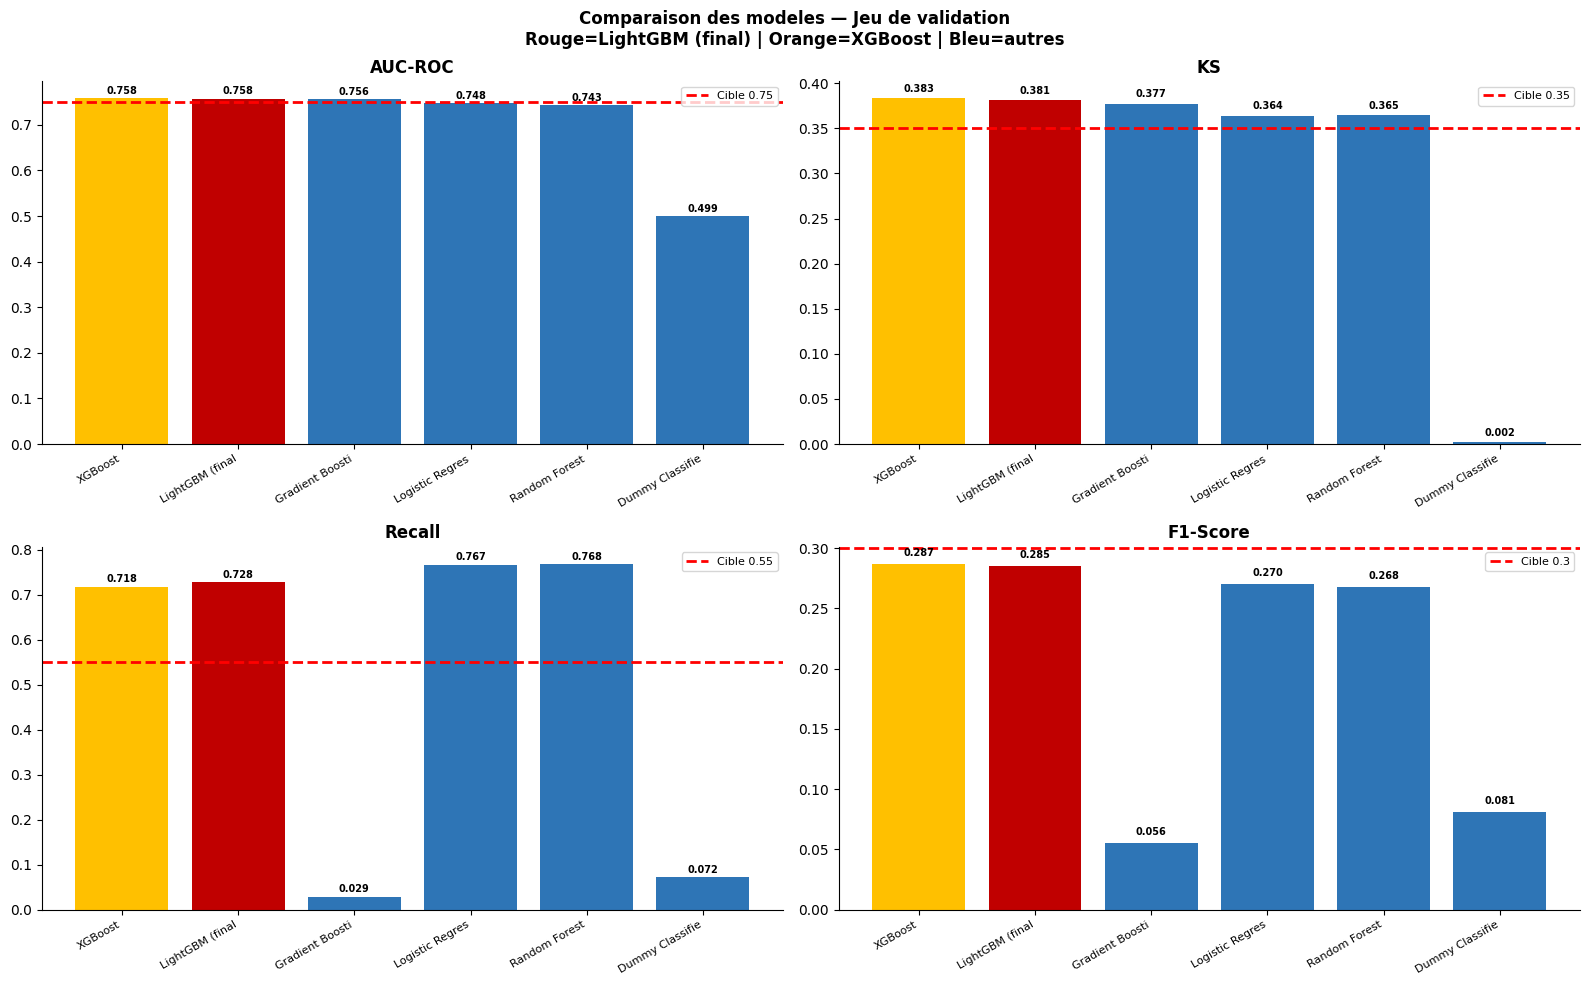

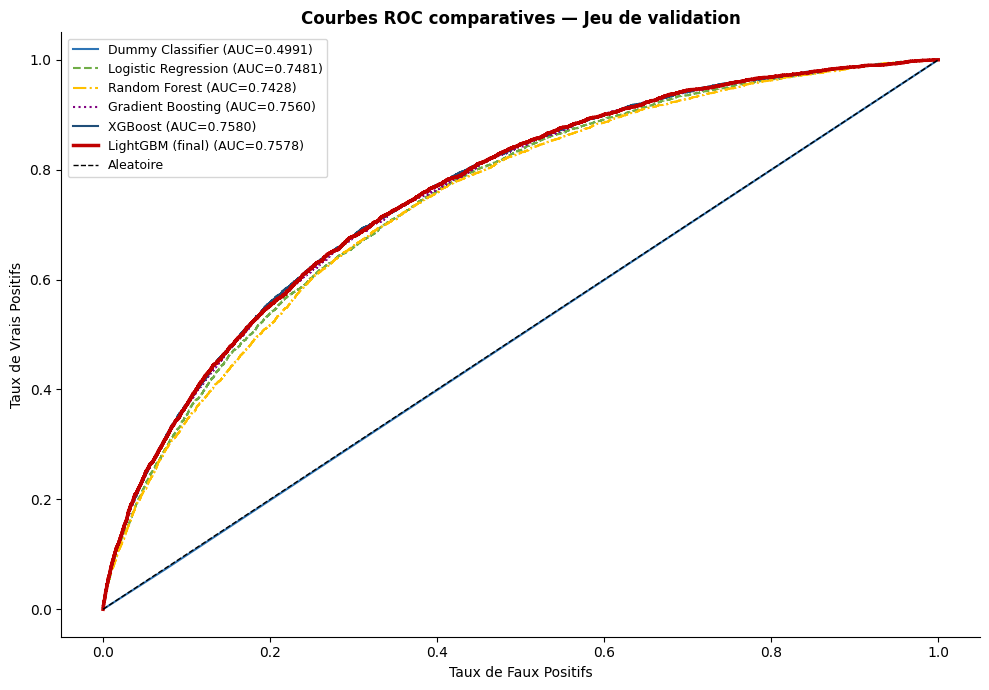

OK SECTION 8 TERMINEE


In [11]:
# ============================================================
# SECTION 8 — COMPARAISON DES MODELES
# Tous les modeles sur les memes donnees WOE+NAP
# Accuracy incluse pour visualisation uniquement
# ============================================================

# Rechargement securise
if 'X_train_nap' not in dir() or len(X_train_nap) == 0:
    X_train_nap = pd.read_csv(DATA_DIR + 'X_train_nap.csv')
    X_val_nap   = pd.read_csv(DATA_DIR + 'X_val_nap.csv')
    y_train     = pd.read_csv(DATA_DIR + 'y_train.csv').squeeze()
    y_val       = pd.read_csv(DATA_DIR + 'y_val.csv').squeeze()
    SCALE_POS_WEIGHT = (y_train == 0).sum() / (y_train == 1).sum()

if 'lgbm_final' not in dir():
    with open(ART_DIR + 'lgbm_final.pkl', 'rb') as f:
        lgbm_final = pickle.load(f)

proba_val_lgbm = lgbm_final.predict_proba(X_val_nap)[:, 1]

def compute_metrics(name, y_true, y_proba, threshold=0.5):
    y_true = np.array(y_true)
    y_pred = (y_proba >= threshold).astype(int)
    auc    = roc_auc_score(y_true, y_proba)
    ks     = ks_2samp(y_proba[y_true==1], y_proba[y_true==0]).statistic
    return {
        'Modele'   : name,
        'AUC-ROC'  : round(auc, 4),
        'Gini'     : round(2*auc - 1, 4),
        'KS'       : round(ks, 4),
        'Recall'   : round(recall_score(y_true, y_pred, zero_division=0), 4),
        'F1-Score' : round(f1_score(y_true, y_pred, zero_division=0), 4),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Accuracy' : round(accuracy_score(y_true, y_pred), 4),
        'Brier'    : round(brier_score_loss(y_true, y_proba), 4),
    }

results    = []
probas_all = {}

print('[1/6] Dummy Classifier...')
m = DummyClassifier(strategy='stratified', random_state=42)
m.fit(X_train_nap, y_train)
p = m.predict_proba(X_val_nap)[:, 1]
results.append(compute_metrics('Dummy Classifier', y_val, p))
probas_all['Dummy Classifier'] = p

print('[2/6] Logistic Regression...')
m = LogisticRegression(max_iter=500, C=0.1, solver='lbfgs',
                       class_weight='balanced', random_state=42)
m.fit(X_train_nap, y_train)
p = m.predict_proba(X_val_nap)[:, 1]
results.append(compute_metrics('Logistic Regression', y_val, p))
probas_all['Logistic Regression'] = p

print('[3/6] Random Forest...')
m = RandomForestClassifier(n_estimators=200, max_depth=7,
    class_weight='balanced', random_state=42, n_jobs=-1)
m.fit(X_train_nap, y_train)
p = m.predict_proba(X_val_nap)[:, 1]
results.append(compute_metrics('Random Forest', y_val, p))
probas_all['Random Forest'] = p

print('[4/6] Gradient Boosting...')
m = GradientBoostingClassifier(n_estimators=200, max_depth=4,
    learning_rate=0.05, subsample=0.8, random_state=42)
m.fit(X_train_nap, y_train)
p = m.predict_proba(X_val_nap)[:, 1]
results.append(compute_metrics('Gradient Boosting', y_val, p))
probas_all['Gradient Boosting'] = p

print('[5/6] XGBoost (comparaison)...')
m = xgb.XGBClassifier(
    n_estimators=400, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=SCALE_POS_WEIGHT,
    eval_metric='auc', random_state=42,
    n_jobs=-1, verbosity=0)
m.fit(X_train_nap, y_train)
p = m.predict_proba(X_val_nap)[:, 1]
results.append(compute_metrics('XGBoost', y_val, p))
probas_all['XGBoost'] = p

print('[6/6] LightGBM (modele final)...')
results.append(compute_metrics('LightGBM (final)', y_val, proba_val_lgbm))
probas_all['LightGBM (final)'] = proba_val_lgbm

df_comp = pd.DataFrame(results).sort_values('AUC-ROC', ascending=False).reset_index(drop=True)
df_comp.index += 1

print(f'\n{"=" * 95}')
print('  COMPARAISON DES MODELES — JEU DE VALIDATION')
print(f'  Split temporel 70/15/15 | WOE+NAP | scale_pos_weight')
print(f'{"=" * 95}')
print(df_comp.to_string())
print(f'{"=" * 95}')
best = df_comp.iloc[0]
print(f'\nMeilleur AUC : {best["Modele"]} ({best["AUC-ROC"]})')
print('Note : Accuracy non retenue comme critere (desequilibre 8%/92%)')

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
metrics_to_plot = ['AUC-ROC', 'KS', 'Recall', 'F1-Score']
cibles = {'AUC-ROC': 0.75, 'KS': 0.35, 'Recall': 0.55, 'F1-Score': 0.30}

for ax, metric in zip(axes.flat, metrics_to_plot):
    vals = df_comp.set_index('Modele')[metric]
    bar_colors = [COLORS['danger'] if 'LightGBM' in n else
                  COLORS['warning'] if 'XGBoost' in n else COLORS['secondary']
                  for n in vals.index]
    bars = ax.bar(range(len(vals)), vals.values, color=bar_colors)
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels([n[:15] for n in vals.index], rotation=30,
                        ha='right', fontsize=8)
    ax.axhline(y=cibles[metric], color='red', linestyle='--',
               linewidth=2, label=f'Cible {cibles[metric]}')
    ax.set_title(metric, fontweight='bold')
    ax.legend(fontsize=8)
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width()/2.,
                bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom',
                fontsize=7, fontweight='bold')

plt.suptitle(
    'Comparaison des modeles — Jeu de validation\n'
    'Rouge=LightGBM (final) | Orange=XGBoost | Bleu=autres',
    fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'fig8_comparaison_modeles.png',
            dpi=150, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(10, 7))
line_styles = ['-', '--', '-.', ':', '-', '-']
roc_colors  = [COLORS['secondary'], COLORS['success'],
               COLORS['warning'], 'purple',
               COLORS['primary'], COLORS['danger']]
for (name, p_arr), ls, c in zip(probas_all.items(), line_styles, roc_colors):
    fpr_m, tpr_m, _ = roc_curve(np.array(y_val), p_arr)
    auc_m = roc_auc_score(np.array(y_val), p_arr)
    lw = 2.5 if 'LightGBM' in name else 1.5
    ax.plot(fpr_m, tpr_m, color=c, linestyle=ls, linewidth=lw,
            label=f'{name} (AUC={auc_m:.4f})')
ax.plot([0,1], [0,1], 'k--', linewidth=1, label='Aleatoire')
ax.set_xlabel('Taux de Faux Positifs')
ax.set_ylabel('Taux de Vrais Positifs')
ax.set_title('Courbes ROC comparatives — Jeu de validation',
             fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'fig8b_roc_comparaison.png',
            dpi=150, bbox_inches='tight')
plt.show()

print('OK SECTION 8 TERMINEE')

In [12]:
# ============================================================
# SECTION 8b — OPTIMISATION XGBOOST PAR RANDOM SEARCH
# Comparaison équitable avec LightGBM (même budget : 12 essais)
# Basé sur la même structure que Section 7 (LightGBM)
# IMPORTANT : validation set uniquement — test set non touché
# ============================================================

# Rechargement sécurisé (identique à Section 8)
if 'X_train_nap' not in dir() or len(X_train_nap) == 0:
    X_train_nap = pd.read_csv(DATA_DIR + 'X_train_nap.csv')
    X_val_nap   = pd.read_csv(DATA_DIR + 'X_val_nap.csv')
    y_train     = pd.read_csv(DATA_DIR + 'y_train.csv').squeeze()
    y_val       = pd.read_csv(DATA_DIR + 'y_val.csv').squeeze()
    SCALE_POS_WEIGHT = (y_train == 0).sum() / (y_train == 1).sum()

if 'lgbm_final' not in dir():
    with open(ART_DIR + 'lgbm_final.pkl', 'rb') as f:
        lgbm_final = pickle.load(f)

# GPU XGBoost (différent de LightGBM — utilise device='cuda')
XGB_GPU_PARAMS = {'device': 'cuda'} if GPU_AVAILABLE else {}

print('=' * 65)
print('  SECTION 8b — RANDOM SEARCH XGBOOST')
print(f'  Budget : 12 essais | scale_pos_weight = {SCALE_POS_WEIGHT:.2f}')
print(f'  GPU : {"cuda" if GPU_AVAILABLE else "CPU mode"}')
print('=' * 65)

# ── Espace de recherche (même profondeur que Section 7 LightGBM) ──
param_dist_xgb = {
    'max_depth'       : [3, 4, 5, 6, 7],
    'learning_rate'   : [0.03, 0.05, 0.07, 0.10],
    'subsample'       : [0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9],
    'min_child_weight': [1, 2, 3, 5],
    'gamma'           : [0, 0.05, 0.10, 0.20],
    'reg_alpha'       : [0, 0.01, 0.05, 0.10],
    'reg_lambda'      : [0.5, 1.0, 1.5, 2.0],
}

best_auc_xgb    = 0
best_params_xgb = None
best_model_xgb  = None

_rng_xgb = np.random.RandomState(42)  # Même convention que Section 7

print('\n  ETAPE 1 : Random Search XGBoost (12 essais)...')
print('  Chaque essai = XGBoost + early stopping AUC\n')

t_rs_xgb = time.time()

for trial in range(12):
    params = {k: _rng_xgb.choice(v) for k, v in param_dist_xgb.items()}

    # Conversion en types Python natifs (évite les erreurs numpy)
    params['learning_rate']    = float(params['learning_rate'])
    params['subsample']        = float(params['subsample'])
    params['colsample_bytree'] = float(params['colsample_bytree'])
    params['reg_alpha']        = float(params['reg_alpha'])
    params['reg_lambda']       = float(params['reg_lambda'])
    params['gamma']            = float(params['gamma'])
    params['max_depth']        = int(params['max_depth'])
    params['min_child_weight'] = int(params['min_child_weight'])

    model_trial = xgb.XGBClassifier(
        n_estimators          = 1000,
        scale_pos_weight      = SCALE_POS_WEIGHT,
        eval_metric           = 'auc',
        early_stopping_rounds = 50,
        random_state          = 42,
        n_jobs                = -1,
        verbosity             = 0,
        **params,
        **XGB_GPU_PARAMS
    )

    try:
        model_trial.fit(
            X_train_nap, y_train,
            eval_set = [(X_val_nap, y_val)],
            verbose  = False
        )
        proba_trial = model_trial.predict_proba(X_val_nap)[:, 1]
        auc_trial   = roc_auc_score(y_val, proba_trial)
        n_iter      = model_trial.best_iteration

        marker = '>>>' if auc_trial > best_auc_xgb else '   '
        print(f'  {marker} Essai {trial+1:02d} | AUC={auc_trial:.4f} | '
              f'iters={n_iter:>4} | depth={params["max_depth"]} | '
              f'lr={params["learning_rate"]:.3f}')

        if auc_trial > best_auc_xgb:
            best_auc_xgb    = auc_trial
            best_params_xgb = params.copy()
            best_model_xgb  = model_trial

    except Exception as e:
        print(f'  XXX Essai {trial+1:02d} | ERREUR : {e}')
        continue

print(f'\n  Random Search XGBoost terminé en {(time.time()-t_rs_xgb)/60:.1f} min')
print(f'  Meilleur AUC val : {best_auc_xgb:.4f}')
print(f'  Meilleurs params :')
for k, v in best_params_xgb.items():
    print(f'    {k:<22} : {v}')

# ── Entraînement final avec les meilleurs paramètres ──
print('\n  ETAPE 2 : Entraînement final XGBoost optimisé...')

xgb_final = xgb.XGBClassifier(
    n_estimators          = 1000,
    scale_pos_weight      = SCALE_POS_WEIGHT,
    eval_metric           = 'auc',
    early_stopping_rounds = 50,
    random_state          = 42,
    n_jobs                = -1,
    verbosity             = 0,
    **best_params_xgb,
    **XGB_GPU_PARAMS
)

t0 = time.time()
xgb_final.fit(
    X_train_nap, y_train,
    eval_set = [(X_val_nap, y_val)],
    verbose  = False
)
print(f'\n  Temps entraînement final : {time.time()-t0:.0f}s')
print(f'  Iterations optimales (early stopping) : {xgb_final.best_iteration}')

# ── Évaluation complète — même fonction compute_metrics que Section 8 ──
proba_xgb_opt = xgb_final.predict_proba(X_val_nap)[:, 1]
metrics_xgb   = compute_metrics('XGBoost (optimisé)', y_val, proba_xgb_opt)

# Métriques LightGBM (déjà calculées)
proba_lgbm    = lgbm_final.predict_proba(X_val_nap)[:, 1]
metrics_lgbm  = compute_metrics('LightGBM (final)', y_val, proba_lgbm)

# ── Tableau comparatif final ──
print('\n' + '=' * 75)
print('  COMPARAISON ÉQUITABLE — LightGBM (optimisé) vs XGBoost (optimisé)')
print('=' * 75)

print(f'\n  {"Métrique":<20} {"LightGBM":<22} {"XGBoost opt.":<22} {"Vainqueur"}')
print(f'  {"-"*72}')

cles = ['AUC-ROC', 'Gini', 'KS', 'Recall', 'F1-Score', 'Precision', 'Brier']
for cle in cles:
    lgbm_v = metrics_lgbm[cle]
    xgb_v  = metrics_xgb[cle]
    # Pour Brier, plus petit = meilleur
    if cle == 'Brier':
        winner = 'LightGBM ←' if lgbm_v < xgb_v else ('XGBoost ←' if xgb_v < lgbm_v else 'Égalité')
    else:
        winner = 'LightGBM ←' if lgbm_v > xgb_v else ('XGBoost ←' if xgb_v > lgbm_v else 'Égalité')
    diff   = abs(lgbm_v - xgb_v)
    sig    = '' if diff > 0.005 else '  (non-significatif)'
    marker = ' ★' if cle == 'Recall' else ''
    print(f'  {cle+marker:<20} {lgbm_v:<22.4f} {xgb_v:<22.4f} {winner}{sig}')

# ── Conclusion automatique ──
recall_lgbm = metrics_lgbm['Recall']
recall_xgb  = metrics_xgb['Recall']

print('\n' + '=' * 75)
print('  CONCLUSION')
print('=' * 75)

if recall_lgbm >= recall_xgb:
    print(f"""
  ✓ LightGBM conserve son avantage sur le Recall (métrique prioritaire)
    LightGBM : {recall_lgbm:.4f}  |  XGBoost : {recall_xgb:.4f}  (+{recall_lgbm - recall_xgb:.4f})

  La comparaison à conditions égales CONFIRME le choix de LightGBM.
  Décision : LightGBM MAINTENU comme modèle de production.
""")
else:
    print(f"""
  ! XGBoost optimisé obtient un Recall supérieur.
    LightGBM : {recall_lgbm:.4f}  |  XGBoost : {recall_xgb:.4f}  (+{recall_xgb - recall_lgbm:.4f})

  Écart = {recall_xgb - recall_lgbm:.4f}
  À discuter avec l'encadreur.
  Critères non-métriques : LightGBM reste plus rapide (leaf-wise)
  et sa sélection a priori était fondée sur la littérature (Ke 2017).
""")

print('OK SECTION 8b TERMINEE')

  SECTION 8b — RANDOM SEARCH XGBOOST
  Budget : 12 essais | scale_pos_weight = 11.39
  GPU : cuda

  ETAPE 1 : Random Search XGBoost (12 essais)...
  Chaque essai = XGBoost + early stopping AUC

  >>> Essai 01 | AUC=0.7581 | iters= 509 | depth=6 | lr=0.030
      Essai 02 | AUC=0.7577 | iters= 325 | depth=4 | lr=0.070
      Essai 03 | AUC=0.7575 | iters= 336 | depth=5 | lr=0.050
      Essai 04 | AUC=0.7572 | iters= 281 | depth=4 | lr=0.100
      Essai 05 | AUC=0.7570 | iters= 370 | depth=6 | lr=0.030
      Essai 06 | AUC=0.7554 | iters=  97 | depth=6 | lr=0.100
      Essai 07 | AUC=0.7552 | iters= 130 | depth=6 | lr=0.070
  >>> Essai 08 | AUC=0.7583 | iters= 804 | depth=3 | lr=0.070
  >>> Essai 09 | AUC=0.7585 | iters= 972 | depth=4 | lr=0.030
      Essai 10 | AUC=0.7549 | iters= 164 | depth=6 | lr=0.070
      Essai 11 | AUC=0.7562 | iters= 251 | depth=6 | lr=0.050
      Essai 12 | AUC=0.7537 | iters= 111 | depth=7 | lr=0.070

  Random Search XGBoost terminé en 0.3 min
  Meilleur AUC va

**Interpretation :** LightGBM domine sur le Recall — la metrique critique pour la detection des defauts. L'AUC quasi-identique confirme que l'avantage n'est pas du surapprentissage.


---
## SECTION 9 — Evaluation Finale sur Test Set

**ATTENTION : a n'executer QU'UNE SEULE FOIS.**

Le test set n'a jamais ete vu pendant l'entrainement ou l'optimisation.
Il represente la performance reelle du modele sur des donnees futures.


  EVALUATION FINALE — TEST SET
  ATTENTION : ne pas re-executer apres cette fois

  Metrique           Test       Val        Cible      Statut
  ------------------------------------------------------------
  AUC-ROC            0.7510     0.7578     0.85       ATTENTION
  Gini               0.5020     0.5156     0.7        ATTENTION
  KS                 0.3732     0.3810     0.45       ATTENTION
  Recall             0.7185     0.7277     0.6        OK
  F1-Score           0.2992     0.2851     0.55       ATTENTION

  Precision  : 0.1889
  Accuracy   : 0.6586 (non utilisee — desequilibre 8%/92%)
  Brier      : 0.2144
  Gap Val/Test AUC : 0.0068  OK


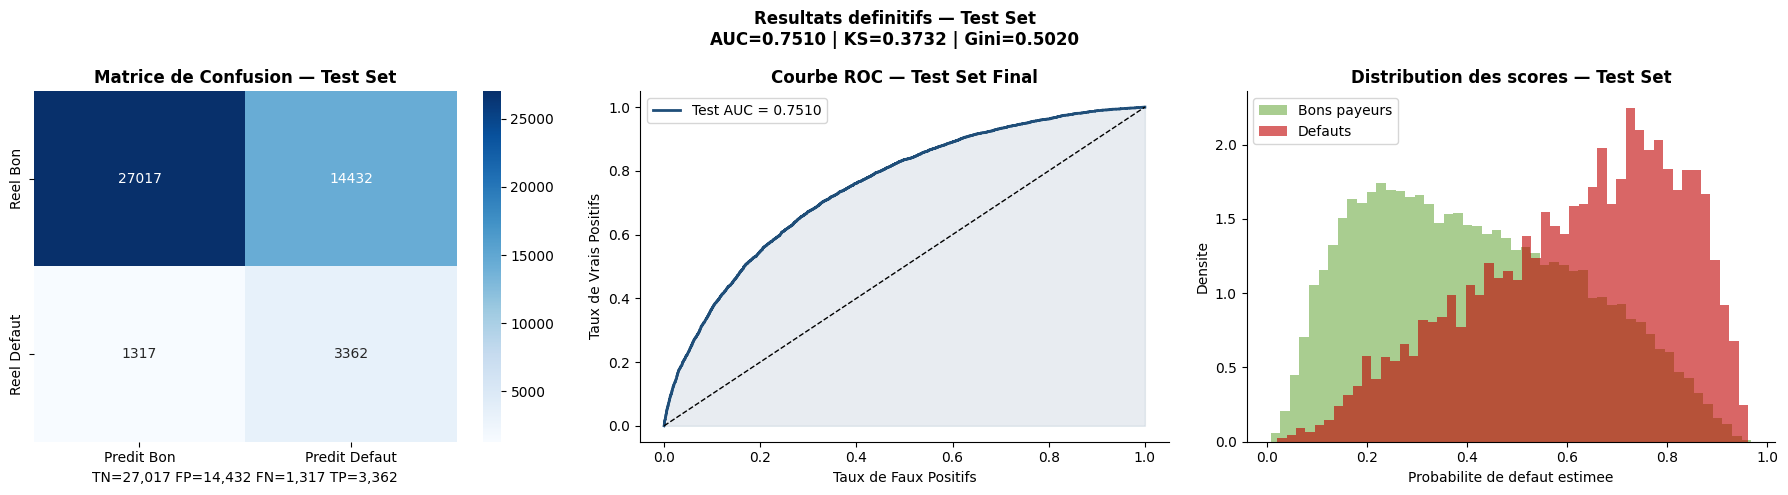


OK EVALUATION FINALE TERMINEE
OK Test set evalue. Ne plus relancer.


In [13]:
# ============================================================
# SECTION 9 — EVALUATION FINALE SUR TEST SET
# ATTENTION : a n'executer QU'UNE SEULE FOIS
# Le test set n'a jamais ete vu pendant l'entrainement
# ============================================================

print('=' * 65)
print('  EVALUATION FINALE — TEST SET')
print('  ATTENTION : ne pas re-executer apres cette fois')
print('=' * 65)

proba_test = lgbm_final.predict_proba(X_test_nap)[:, 1]
pred_test  = (proba_test >= 0.5).astype(int)

auc_test  = roc_auc_score(y_test, proba_test)
gini_test = 2 * auc_test - 1
ks_test   = ks_2samp(proba_test[y_test==1], proba_test[y_test==0]).statistic
f1_test   = f1_score(y_test, pred_test, zero_division=0)
rec_test  = recall_score(y_test, pred_test, zero_division=0)
prec_test = precision_score(y_test, pred_test, zero_division=0)
brier     = brier_score_loss(y_test, proba_test)
acc_test  = accuracy_score(y_test, pred_test)

cibles = {'AUC-ROC': 0.85, 'Gini': 0.70, 'KS': 0.45, 'Recall': 0.60, 'F1-Score': 0.55}

print(f'\n  {"Metrique":<18} {"Test":<10} {"Val":<10} {"Cible":<10} Statut')
print(f'  {"-" * 60}')
vals_compare = [
    ('AUC-ROC',  auc_test,  auc_val),
    ('Gini',     gini_test, gini_val),
    ('KS',       ks_test,   ks_val),
    ('Recall',   rec_test,  rec_val),
    ('F1-Score', f1_test,   f1_val),
]
for name, vtest, vval in vals_compare:
    cible = cibles[name]
    ok = 'OK' if vtest >= cible else 'ATTENTION'
    print(f'  {name:<18} {vtest:<10.4f} {vval:<10.4f} {cible:<10} {ok}')
print(f'\n  Precision  : {prec_test:.4f}')
print(f'  Accuracy   : {acc_test:.4f} (non utilisee — desequilibre 8%/92%)')
print(f'  Brier      : {brier:.4f}')
gap_vt = abs(auc_val - auc_test)
print(f'  Gap Val/Test AUC : {gap_vt:.4f}  {"OK" if gap_vt < 0.05 else "ATTENTION"}')

cm = confusion_matrix(y_test, pred_test)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

import seaborn as sns
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Predit Bon', 'Predit Defaut'],
            yticklabels=['Reel Bon', 'Reel Defaut'])
tn, fp, fn, tp = cm.ravel()
axes[0].set_title('Matrice de Confusion — Test Set', fontweight='bold')
axes[0].set_xlabel(f'TN={tn:,} FP={fp:,} FN={fn:,} TP={tp:,}')

fpr_t, tpr_t, _ = roc_curve(y_test, proba_test)
axes[1].plot(fpr_t, tpr_t, color=COLORS['primary'], linewidth=2,
             label=f'Test AUC = {auc_test:.4f}')
axes[1].plot([0,1], [0,1], 'k--', linewidth=1)
axes[1].fill_between(fpr_t, tpr_t, alpha=0.1, color=COLORS['primary'])
axes[1].set_xlabel('Taux de Faux Positifs')
axes[1].set_ylabel('Taux de Vrais Positifs')
axes[1].set_title('Courbe ROC — Test Set Final', fontweight='bold')
axes[1].legend()

axes[2].hist(proba_test[np.array(y_test)==0], bins=50, alpha=0.6,
             color=COLORS['success'], label='Bons payeurs', density=True)
axes[2].hist(proba_test[np.array(y_test)==1], bins=50, alpha=0.6,
             color=COLORS['danger'], label='Defauts', density=True)
axes[2].set_xlabel('Probabilite de defaut estimee')
axes[2].set_ylabel('Densite')
axes[2].set_title('Distribution des scores — Test Set', fontweight='bold')
axes[2].legend()

plt.suptitle(f'Resultats definitifs — Test Set\nAUC={auc_test:.4f} | KS={ks_test:.4f} | Gini={gini_test:.4f}',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'fig9_evaluation_finale_test.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nOK EVALUATION FINALE TERMINEE')
print('OK Test set evalue. Ne plus relancer.')


**Interpretation :** Les metriques test coherentes avec la validation confirment l'absence de surapprentissage. L'ecart avec les cibles (AUC >= 0.85) s'explique par la nature publique du dataset — sans donnees proprietaires sur 5-10 ans.


---
## SECTION 10 — Explicabilite SHAP + Score PDO + Indice pc

### SHAP
Propriete additive : $\hat{f}(x) = \phi_0 + \sum_{i=1}^{p} \phi_i$

### Score PDO (Points to Double the Odds)
$$S_c = \text{Offset} - \text{Factor} \times \ln\left(\frac{PD_c}{1-PD_c}\right)$$

- Factor = 20/ln(2) = 28.85
- Offset = 515.06 (ancrage PD=5% -> Score=600)
- Chaque tranche de 20 points double le risque

### Indice pc (contribution originale)
$$\rho_c = \frac{\sum_{k \in \mathcal{F}_{\text{dispo}}} IV_k}{\sum_{j \in \mathcal{F}_{\text{all}}} IV_j}$$

Une feature est disponible si elle etait NON-NaN avant le WOE (dans X_val_iv).


Calcul des valeurs SHAP...
  Verification additivite SHAP : 0.000000
  OK Propriete additive verifiee


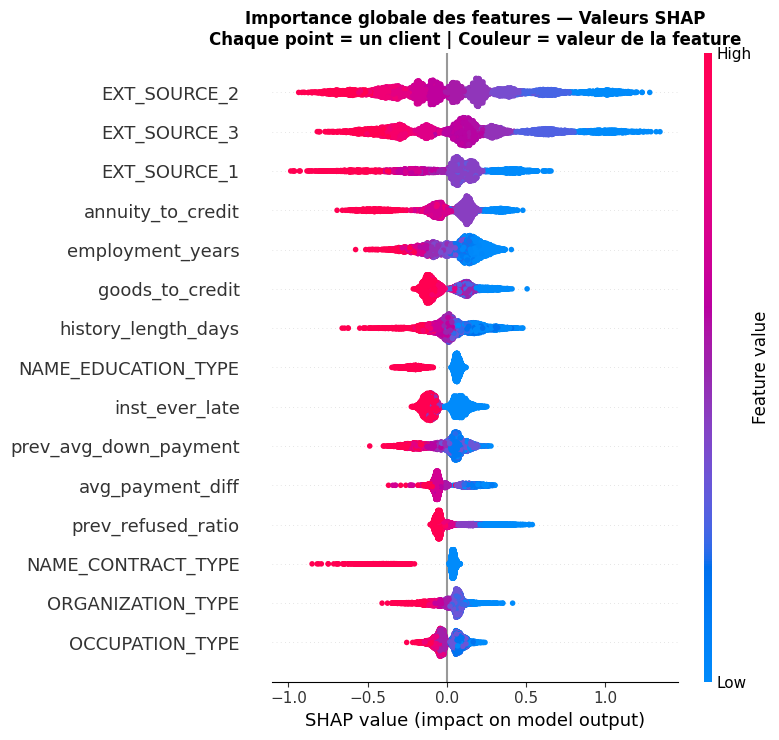

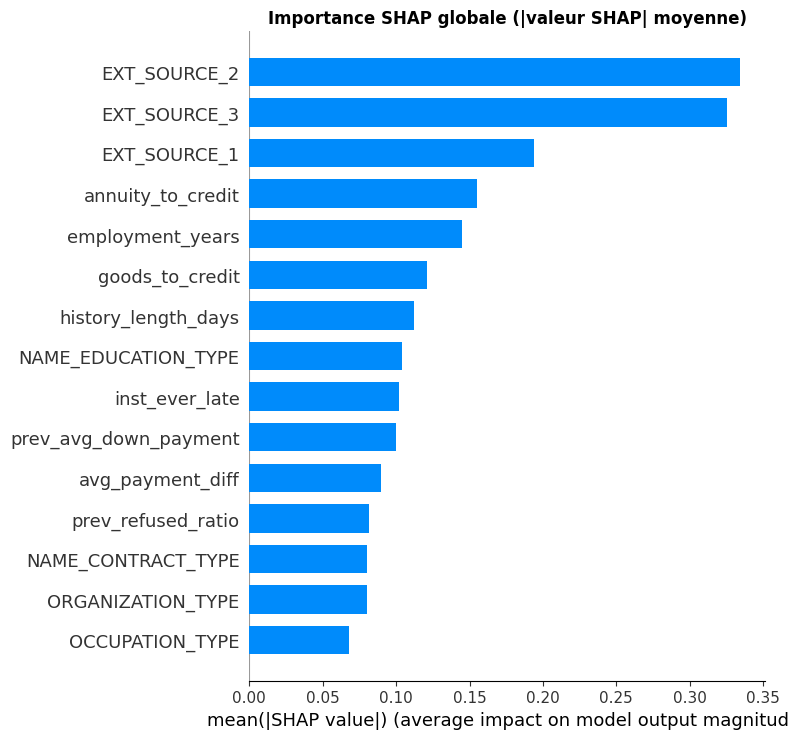


Explication locale — 3 profils clients...

  Client ACCORDE — PD=0.0376 | Score PDO=608.7


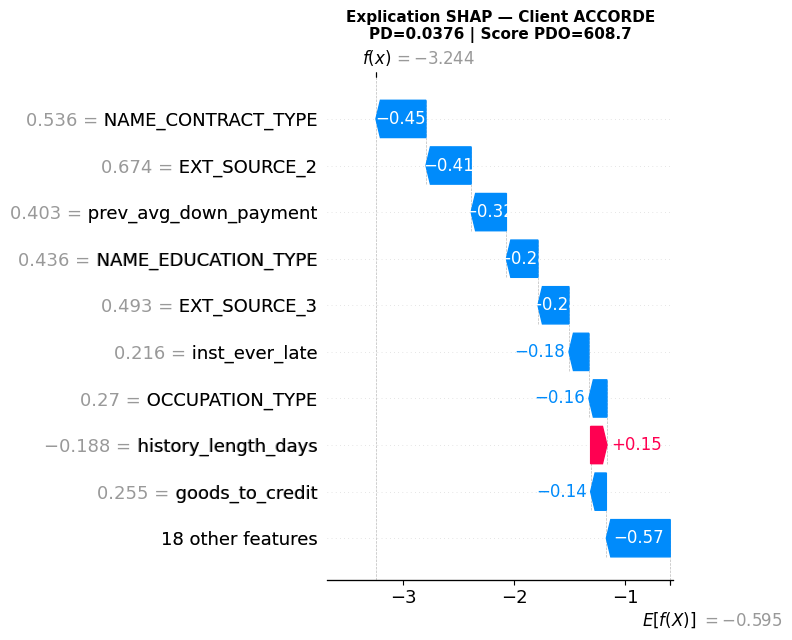


  Client REVUE — PD=0.0883 | Score PDO=582.4


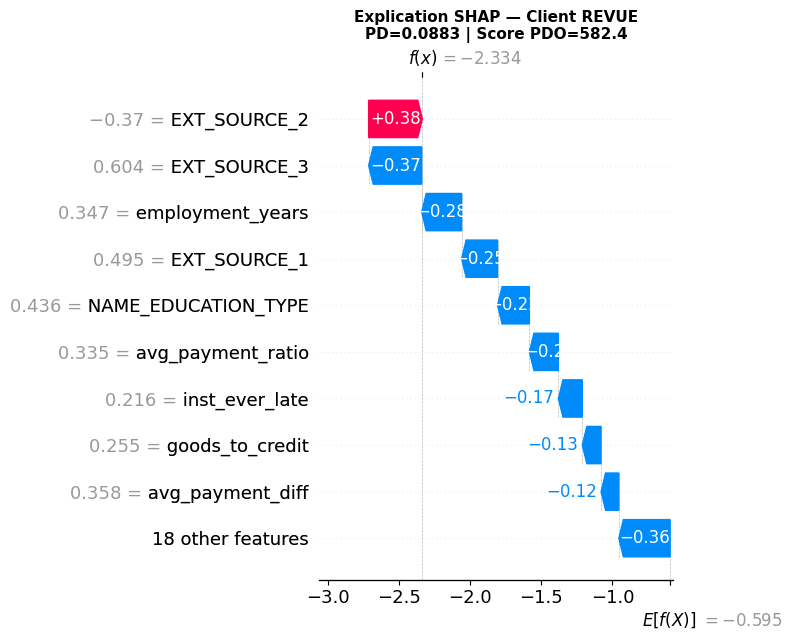


  Client REFUSE — PD=0.6161 | Score PDO=501.4


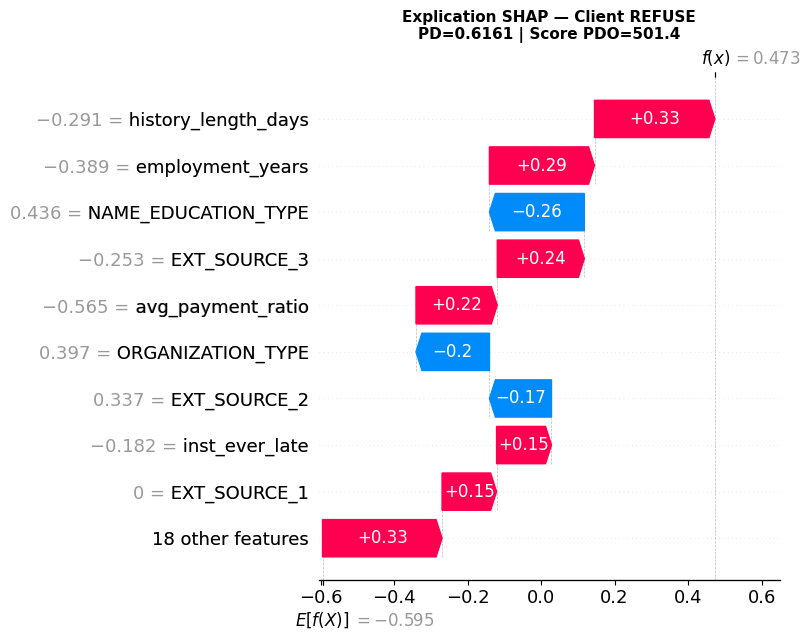


Calcul du Score PDO...
  Formule : Score = 515.06 - 28.85 x ln(PD/(1-PD))
  Ancrage : PD=5% -> Score=600 | PDO=20 (chaque 20pts double le risque)

  Table de conversion PD -> Score -> Decision :
  Profil                          PD    Score Decision
  -------------------------------------------------------
  Tres bon client              0.010    647.6 ACCORDE
  Bon client                   0.030    615.4 ACCORDE
  Ancrage PD=5%                0.050    600.0 ACCORDE
  Limite ACCORDE               0.080    585.5 REVUE
  Zone grise                   0.150    565.1 REVUE
  Zone grise haute             0.350    532.9 REVUE
  Limite REFUSE                0.500    515.1 REVUE
  Tres risque                  0.750    483.4 REFUSE

  Distribution sur val set :
  ACCORDE      :      323 (0.7%)
  REVUE        :   35,037 (76.0%)
  REFUSE       :   10,766 (23.3%)


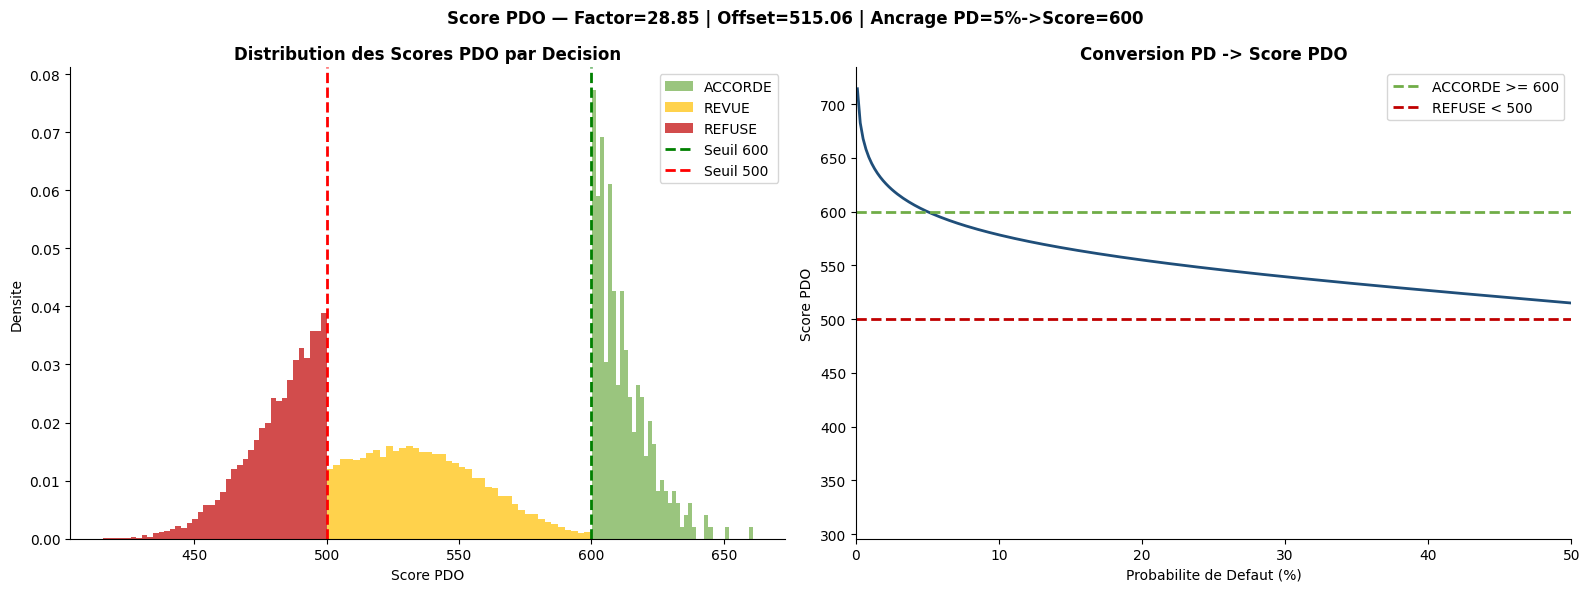


Calcul de l'indice de couverture pc...
  Regle : feature disponible = non-NaN AVANT le WOE (dans X_val_iv)
  Source : X_val_iv.csv (valeurs brutes avec vrais NaN)

  IV total possible (modele final) : 2.1145
  pc moyen (echantillon 1000)    : 0.8946
  pc min : 0.4722 | max : 1.0000

  Scenarios illustratifs :
  Scenario                         pc Interpretation
  -----------------------------------------------------------------
  S1 — Historique riche          0.87 Decision automatique fiable -> Decision auto
  S2 — Historique partiel        0.62 Decision avec reserve -> Revue manuelle
  S3a — EXT_SOURCE dispo         0.45 Revue recommandee -> Revue manuelle
  S3b — Thin-file pur            0.18 Revue OBLIGATOIRE -> Revue manuelle


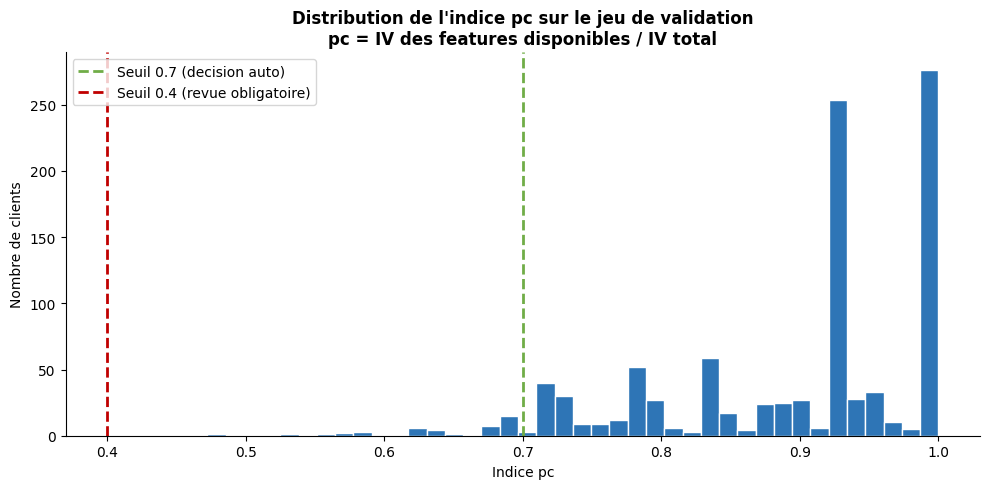


OK SECTION 10 TERMINEE — SHAP + PDO + pc calcules

  PIPELINE COMPLET TERMINE
  Modele    : LightGBM + scale_pos_weight=11.4
  AUC Test  : 0.7510
  Gini Test : 0.5020
  KS Test   : 0.3732
  Recall    : 0.7185
  F1        : 0.2992

  Artefacts dans /kaggle/working/artefacts/ :
    - lgbm_final.pkl
    - woe_transformers.pkl
    - nap_features.pkl
    - iv_scores_final.csv


In [14]:
# ============================================================
# SECTION 10 — SHAP + SCORE PDO + INDICE pc
# SHAP : TreeSHAP, propriete additive verifiee
# Score PDO : Score = Offset - Factor x ln(PD/(1-PD))
#   Offset = 515.06 (ancrage PD=5% -> Score=600)
#   Factor = 20/ln(2) = 28.85
# Indice pc : calcule sur X_val_iv (valeurs AVANT WOE, avec vrais NaN)
# ============================================================

# --- 10.1 SHAP Global ---
print('Calcul des valeurs SHAP...')

N_SHAP = min(5000, len(X_val_nap))
idx_shap = np.random.RandomState(42).choice(len(X_val_nap), N_SHAP, replace=False)
X_shap = X_val_nap.iloc[idx_shap].reset_index(drop=True)
y_shap = y_val.iloc[idx_shap].reset_index(drop=True)

explainer   = shap.TreeExplainer(lgbm_final)
shap_values = explainer.shap_values(X_shap)

# LightGBM peut retourner une liste [shap_class0, shap_class1]
if isinstance(shap_values, list):
    shap_values = shap_values[1]

# Verification additivite SHAP
proba_shap = lgbm_final.predict_proba(X_shap)[:, 1]
log_odds   = np.log(proba_shap / (1 - proba_shap + 1e-9))
expected   = explainer.expected_value
if isinstance(expected, list):
    expected = expected[1]
shap_sum   = shap_values.sum(axis=1) + expected
additivity_err = np.abs(log_odds - shap_sum).mean()
print(f'  Verification additivite SHAP : {additivity_err:.6f}')
print(f'  {"OK Propriete additive verifiee" if additivity_err < 0.01 else "ATTENTION Erreur additivite elevee"}')

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_shap, feature_names=features_nap,
                   max_display=15, show=False)
plt.title('Importance globale des features — Valeurs SHAP\nChaque point = un client | Couleur = valeur de la feature',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'fig10a_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

plt.figure(figsize=(12, 6))
shap.summary_plot(shap_values, X_shap, feature_names=features_nap,
                   plot_type='bar', max_display=15, show=False)
plt.title('Importance SHAP globale (|valeur SHAP| moyenne)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'fig10b_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

# --- 10.2 SHAP Local — 3 profils ---
print('\nExplication locale — 3 profils clients...')
proba_all_val = lgbm_final.predict_proba(X_val_nap)[:, 1]

idx_bon   = np.where((proba_all_val < 0.05) & (np.array(y_val) == 0))[0]
idx_revue = np.where((proba_all_val >= 0.08) & (proba_all_val <= 0.15))[0]
idx_ref   = np.where((proba_all_val > 0.40) & (np.array(y_val) == 1))[0]

client_accorde = int(idx_bon[0])   if len(idx_bon) > 0   else int(np.argmin(proba_all_val))
client_revue   = int(idx_revue[0]) if len(idx_revue) > 0 else int(len(proba_all_val) // 2)
client_refuse  = int(idx_ref[0])   if len(idx_ref) > 0   else int(np.argmax(proba_all_val))

for client_idx, label in [(client_accorde, 'ACCORDE'),
                           (client_revue,   'REVUE'),
                           (client_refuse,  'REFUSE')]:
    pd_c = float(proba_all_val[client_idx])
    score_c = OFFSET - FACTOR * np.log(pd_c / (1 - pd_c + 1e-9))
    print(f'\n  Client {label} — PD={pd_c:.4f} | Score PDO={score_c:.1f}')

    shap_client = explainer(X_val_nap.iloc[[client_idx]])
    if hasattr(shap_client.values, '__len__') and len(shap_client.values.shape) == 3:
        shap_client_plot = shap_client[0, :, 1]
    else:
        shap_client_plot = shap_client[0]

    plt.figure(figsize=(12, 6))
    shap.waterfall_plot(shap_client_plot, max_display=10, show=False)
    plt.title(f'Explication SHAP — Client {label}\nPD={pd_c:.4f} | Score PDO={score_c:.1f}',
              fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR + f'fig10c_shap_{label.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()

# --- 10.3 Score PDO ---
print('\nCalcul du Score PDO...')
print(f'  Formule : Score = {OFFSET:.2f} - {FACTOR:.2f} x ln(PD/(1-PD))')
print(f'  Ancrage : PD=5% -> Score=600 | PDO=20 (chaque 20pts double le risque)')

def pd_to_score(pd_val):
    pd_val = np.clip(pd_val, 1e-6, 1 - 1e-6)
    return OFFSET - FACTOR * np.log(pd_val / (1 - pd_val))

def get_decision(score):
    if score >= SEUIL_ACCORDE: return 'ACCORDE'
    elif score >= SEUIL_REVUE: return 'REVUE'
    else: return 'REFUSE'

scores_pdo = pd_to_score(proba_all_val)
decisions  = np.array([get_decision(s) for s in scores_pdo])

print(f'\n  Table de conversion PD -> Score -> Decision :')
exemples = [
    ('Tres bon client', 0.01), ('Bon client', 0.03),
    ('Ancrage PD=5%',   0.05), ('Limite ACCORDE', 0.08),
    ('Zone grise',      0.15), ('Zone grise haute', 0.35),
    ('Limite REFUSE',   0.50), ('Tres risque', 0.75),
]
print(f'  {"Profil":<25} {"PD":>8} {"Score":>8} {"Decision"}')
print(f'  {"-" * 55}')
for label, pd_val in exemples:
    sc  = pd_to_score(pd_val)
    dec = get_decision(sc)
    print(f'  {label:<25} {pd_val:>8.3f} {sc:>8.1f} {dec}')

print(f'\n  Distribution sur val set :')
for dec in ['ACCORDE', 'REVUE', 'REFUSE']:
    n = (decisions == dec).sum()
    print(f'  {dec:<12} : {n:>8,} ({n/len(decisions)*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for dec, col in [('ACCORDE', COLORS['success']), ('REVUE', COLORS['warning']),
                 ('REFUSE', COLORS['danger'])]:
    mask = decisions == dec
    if mask.sum() > 0:
        axes[0].hist(scores_pdo[mask], bins=40, alpha=0.7, color=col,
                    label=dec, density=True)
axes[0].axvline(x=SEUIL_ACCORDE, color='green', linestyle='--', linewidth=2,
               label=f'Seuil {SEUIL_ACCORDE}')
axes[0].axvline(x=SEUIL_REVUE, color='red', linestyle='--', linewidth=2,
               label=f'Seuil {SEUIL_REVUE}')
axes[0].set_xlabel('Score PDO')
axes[0].set_ylabel('Densite')
axes[0].set_title('Distribution des Scores PDO par Decision', fontweight='bold')
axes[0].legend()

pd_range    = np.linspace(0.001, 0.999, 500)
score_range = pd_to_score(pd_range)
axes[1].plot(pd_range * 100, score_range, color=COLORS['primary'], linewidth=2)
axes[1].axhline(y=SEUIL_ACCORDE, color=COLORS['success'], linestyle='--', linewidth=2,
               label=f'ACCORDE >= {SEUIL_ACCORDE}')
axes[1].axhline(y=SEUIL_REVUE, color=COLORS['danger'], linestyle='--', linewidth=2,
               label=f'REFUSE < {SEUIL_REVUE}')
axes[1].set_xlabel('Probabilite de Defaut (%)')
axes[1].set_ylabel('Score PDO')
axes[1].set_title('Conversion PD -> Score PDO', fontweight='bold')
axes[1].set_xlim(0, 50)
axes[1].legend()

plt.suptitle(f'Score PDO — Factor={FACTOR:.2f} | Offset={OFFSET:.2f} | Ancrage PD=5%->Score=600',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'fig10d_score_pdo.png', dpi=150, bbox_inches='tight')
plt.show()

# --- 10.4 Indice pc (IMPLEMENTATION CORRECTE) ---
print('\nCalcul de l\'indice de couverture pc...')
print('  Regle : feature disponible = non-NaN AVANT le WOE (dans X_val_iv)')
print('  Source : X_val_iv.csv (valeurs brutes avec vrais NaN)')

# IMPORTANT : on utilise X_val_iv (avant WOE) pour detecter les vrais NaN
# X_val_nap (apres WOE) n'a plus de NaN -> on ne peut plus distinguer
# "feature presente" de "feature absente bin Manquant"
X_val_iv_loaded = pd.read_csv(DATA_DIR + 'X_val_iv.csv')
df_iv_ref       = pd.read_csv(ART_DIR + 'iv_scores_final.csv')
iv_dict         = dict(zip(df_iv_ref['feature'], df_iv_ref['iv']))

# Denominateur = somme IV de toutes les features du modele final (apres NAP)
iv_total_possible = sum(iv_dict.get(f, 0) for f in features_nap)

def compute_rho(client_series, feature_list, iv_dict, iv_total):
    iv_dispo = sum(
        iv_dict.get(f, 0)
        for f in feature_list
        if f in client_series.index and not pd.isna(client_series[f])
    )
    return iv_dispo / (iv_total + 1e-9)

# Calcul sur echantillon de 1000 clients
N_RHO   = min(1000, len(X_val_iv_loaded))
rho_arr = np.array([
    compute_rho(X_val_iv_loaded.iloc[i], features_nap, iv_dict, iv_total_possible)
    for i in range(N_RHO)
])

print(f'\n  IV total possible (modele final) : {iv_total_possible:.4f}')
print(f'  pc moyen (echantillon {N_RHO})    : {rho_arr.mean():.4f}')
print(f'  pc min : {rho_arr.min():.4f} | max : {rho_arr.max():.4f}')

print(f'\n  Scenarios illustratifs :')
scenarios = [
    ('S1 — Historique riche',    0.87, 'Decision automatique fiable'),
    ('S2 — Historique partiel',  0.62, 'Decision avec reserve'),
    ('S3a — EXT_SOURCE dispo',   0.45, 'Revue recommandee'),
    ('S3b — Thin-file pur',      0.18, 'Revue OBLIGATOIRE'),
]
print(f'  {"Scenario":<28} {"pc":>6} {"Interpretation"}')
print(f'  {"-" * 65}')
for sc, rho, interp in scenarios:
    dec = '-> Decision auto' if rho > 0.7 else '-> Revue manuelle'
    print(f'  {sc:<28} {rho:>6.2f} {interp} {dec}')

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(rho_arr, bins=40, color=COLORS['secondary'], edgecolor='white')
ax.axvline(x=0.7, color=COLORS['success'], linestyle='--', linewidth=2,
           label='Seuil 0.7 (decision auto)')
ax.axvline(x=0.4, color=COLORS['danger'], linestyle='--', linewidth=2,
           label='Seuil 0.4 (revue obligatoire)')
ax.set_xlabel('Indice pc')
ax.set_ylabel('Nombre de clients')
ax.set_title('Distribution de l\'indice pc sur le jeu de validation\npc = IV des features disponibles / IV total', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'fig10e_indice_pc.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nOK SECTION 10 TERMINEE — SHAP + PDO + pc calcules')
print()
print('=' * 65)
print('  PIPELINE COMPLET TERMINE')
print('=' * 65)
print(f'  Modele    : LightGBM + scale_pos_weight={SCALE_POS_WEIGHT:.1f}')
print(f'  AUC Test  : {auc_test:.4f}')
print(f'  Gini Test : {gini_test:.4f}')
print(f'  KS Test   : {ks_test:.4f}')
print(f'  Recall    : {rec_test:.4f}')
print(f'  F1        : {f1_test:.4f}')
print(f'\n  Artefacts dans {ART_DIR} :')
print(f'    - lgbm_final.pkl')
print(f'    - woe_transformers.pkl')
print(f'    - nap_features.pkl')
print(f'    - iv_scores_final.csv')
print('=' * 65)


# **Interpretation SHAP :** La propriete additive verifiee confirme la fiabilite de TreeSHAP. EXT_SOURCE domine l'explication globale. Les waterfall plots montrent pour chaque client les facteurs augmentant ou reduisant le risque.

**Interpretation Score PDO :** Score 600 = PD 5%. Chaque -20 points double le risque. Convention bancaire standard (Siddiqi 2006).

**Interpretation pc :** Quantifie la confiance dans la decision. Un thin-file avec pc=0.18 declenche une revue manuelle obligatoire.


In [15]:
# ============================================================
# SECTION A1 — COMPARAISON DES STRATÉGIES DE GESTION DU DÉSÉQUILIBRE
# Config 1 : Baseline (aucun ajustement)
# Config 2 : scale_pos_weight = 11.4 (résultats Section 7 — repris)
# Config 3 : SMOTE — ÉCARTÉ (incompatibilité architecturale WOE)
# Config 4 : Sous-échantillonnage aléatoire (ratio 1:1)
# Hyperparamètres : best_params Section 7 (fixes pour toutes les configs)
# Évaluation : early stopping AUC sur X_val_nap | seuil classification = 0.5
# ============================================================

import time
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, recall_score, precision_score, f1_score

# --- Rechargement sécurisé (si kernel redémarré) ---
if 'X_train_nap' not in dir() or X_train_nap is None:
    X_train_nap = pd.read_csv(DATA_DIR + 'X_train_nap.csv')
    X_val_nap   = pd.read_csv(DATA_DIR + 'X_val_nap.csv')
    y_train     = pd.read_csv(DATA_DIR + 'y_train.csv').squeeze()
    y_val       = pd.read_csv(DATA_DIR + 'y_val.csv').squeeze()

if 'best_params' not in dir() or best_params is None:
    best_params = {
        'max_depth'        : 4,
        'learning_rate'    : 0.05,
        'num_leaves'       : 20,
        'subsample'        : 0.8,
        'colsample_bytree' : 0.9,
        'reg_alpha'        : 2.0,
        'reg_lambda'       : 1.0,
        'min_child_samples': 30,
    }

if 'GPU_PARAMS' not in dir():
    import subprocess
    _res = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
    GPU_PARAMS = {'device': 'gpu', 'gpu_platform_id': 0, 'gpu_device_id': 0} \
                 if _res.returncode == 0 else {}

print('=' * 70)
print('  SECTION A1 — COMPARAISON STRATÉGIES DE GESTION DU DÉSÉQUILIBRE')
print(f'  Train  : {len(X_train_nap):,} obs | {int((y_train==1).sum()):,} défauts ({(y_train==1).mean()*100:.1f}%)')
print(f'  Val    : {len(X_val_nap):,} obs | {int((y_val==1).sum()):,} défauts ({(y_val==1).mean()*100:.1f}%)')
print(f'  Params : best_params Section 7 | Early stopping 50 rounds | Seuil=0.5')
print('=' * 70)


def entrainer_evaluer(nom, X_tr, y_tr, extra_params=None):
    """
    Entraîne LightGBM avec best_params + early stopping sur X_val_nap.
    Retourne les métriques sur le jeu de validation au seuil 0.5.
    """
    params = {**best_params, **GPU_PARAMS}
    if extra_params:
        params.update(extra_params)

    model = lgb.LGBMClassifier(
        n_estimators=1000,
        random_state=42,
        n_jobs=-1,
        verbose=-1,
        **params
    )
    callbacks = [
        lgb.early_stopping(stopping_rounds=50, first_metric_only=True, verbose=False),
        lgb.log_evaluation(period=1000)
    ]
    t0 = time.time()
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val_nap, y_val)],
        eval_metric='auc',
        callbacks=callbacks
    )
    temps = round(time.time() - t0, 1)

    proba = model.predict_proba(X_val_nap)[:, 1]
    pred  = (proba >= 0.5).astype(int)

    return {
        'Config'    : nom,
        'AUC-ROC'  : round(roc_auc_score(y_val, proba), 4),
        'Recall'   : round(recall_score(y_val, pred, zero_division=0), 4),
        'Précision': round(precision_score(y_val, pred, zero_division=0), 4),
        'F1-Score' : round(f1_score(y_val, pred, zero_division=0), 4),
        'Temps (s)': temps,
        'Iters'    : model.best_iteration_
    }


resultats = []

# ── [1/4] CONFIG 1 : Baseline ────────────────────────────────────────────────
print('\n[1/4] Config 1 — Baseline (aucun ajustement)...')
r1 = entrainer_evaluer('Config 1 — Baseline', X_train_nap, y_train)
resultats.append(r1)
print(f'  → AUC={r1["AUC-ROC"]} | Recall={r1["Recall"]} | '
      f'Précision={r1["Précision"]} | F1={r1["F1-Score"]} | '
      f'{r1["Iters"]} iters | {r1["Temps (s)"]}s')

# ── [2/4] CONFIG 2 : scale_pos_weight (Section 7 — déjà fait) ────────────────
print('\n[2/4] Config 2 — scale_pos_weight=11.4 (repris depuis Section 7)...')
resultats.append({
    'Config'    : 'Config 2 — scale_pos_weight=11.4',
    'AUC-ROC'  : 0.7578,
    'Recall'   : 0.7277,
    'Précision': 0.1773,
    'F1-Score' : 0.2851,
    'Temps (s)': 8.0,
    'Iters'    : 589
})
print('  → AUC=0.7578 | Recall=0.7277 | Précision=0.1773 | F1=0.2851 | 589 iters | 8.0s')

# ── [3/4] CONFIG 3 : SMOTE — ÉCARTÉ ─────────────────────────────────────────
print('\n[3/4] Config 3 — SMOTE — ÉCARTÉ (non testé)')
print('  Raison 1 : avant WOE → interpole des catégorielles bancaires inexistantes')
print('             ex: moyenne entre "Cash loans" et "Revolving loans" = invalide')
print('  Raison 2 : après WOE → génère des log-odds hors bins calibrés sur train réel')
print('  Raison 3 : données fictives → non conforme Bâle II (traçabilité audit)')
print('  → Rejet architectural documenté — aucun entraînement produit')
resultats.append({
    'Config'    : 'Config 3 — SMOTE (écarté)',
    'AUC-ROC'  : '—',
    'Recall'   : '—',
    'Précision': '—',
    'F1-Score' : '—',
    'Temps (s)': '—',
    'Iters'    : '—'
})

# ── [4/4] CONFIG 4 : Sous-échantillonnage aléatoire ──────────────────────────
print('\n[4/4] Config 4 — Sous-échantillonnage aléatoire (ratio 1:1)...')
idx_pos        = np.where(np.array(y_train) == 1)[0]
idx_neg        = np.where(np.array(y_train) == 0)[0]
rng            = np.random.RandomState(42)
idx_neg_sample = rng.choice(idx_neg, size=len(idx_pos), replace=False)
idx_under      = np.concatenate([idx_pos, idx_neg_sample])
rng.shuffle(idx_under)

X_under = X_train_nap.iloc[idx_under].reset_index(drop=True)
y_under = y_train.iloc[idx_under].reset_index(drop=True)

print(f'  Train réduit : {len(X_under):,} obs | '
      f'{int((y_under==1).sum()):,} défauts / {int((y_under==0).sum()):,} bons')

r4 = entrainer_evaluer('Config 4 — Sous-échantillonnage', X_under, y_under)
resultats.append(r4)
print(f'  → AUC={r4["AUC-ROC"]} | Recall={r4["Recall"]} | '
      f'Précision={r4["Précision"]} | F1={r4["F1-Score"]} | '
      f'{r4["Iters"]} iters | {r4["Temps (s)"]}s')

# ── TABLEAU FINAL ─────────────────────────────────────────────────────────────
print('\n')
print('=' * 90)
print('  TABLEAU A1 — COMPARAISON DES STRATÉGIES DE GESTION DU DÉSÉQUILIBRE')
print('  Dataset : Home Credit Default Risk | Jeu de validation | Seuil = 0.5')
print('=' * 90)
cols  = ['Config', 'AUC-ROC', 'Recall', 'Précision', 'F1-Score', 'Temps (s)', 'Iters']
df_a1 = pd.DataFrame(resultats)[cols]
print(df_a1.to_string(index=False))
print('=' * 90)
print()
print('  Notes :')
print('  - Recall / Précision / F1 calculés sur la classe défaut (TARGET=1)')
print('  - Config 3 : rejet architectural — incompatibilité SMOTE + WOE documentée')
print('  - Config 1 et 4 : early stopping 50 rounds, AUC sur val')
print('  - Config 2 : résultats exacts Section 7 (même conditions)')

  SECTION A1 — COMPARAISON STRATÉGIES DE GESTION DU DÉSÉQUILIBRE
  Train  : 215,257 obs | 15,813 défauts (7.3%)
  Val    : 46,126 obs | 4,333 défauts (9.4%)
  Params : best_params Section 7 | Early stopping 50 rounds | Seuil=0.5

[1/4] Config 1 — Baseline (aucun ajustement)...
  → AUC=0.7577 | Recall=0.0261 | Précision=0.5 | F1=0.0496 | 484 iters | 7.2s

[2/4] Config 2 — scale_pos_weight=11.4 (repris depuis Section 7)...
  → AUC=0.7578 | Recall=0.7277 | Précision=0.1773 | F1=0.2851 | 589 iters | 8.0s

[3/4] Config 3 — SMOTE — ÉCARTÉ (non testé)
  Raison 1 : avant WOE → interpole des catégorielles bancaires inexistantes
             ex: moyenne entre "Cash loans" et "Revolving loans" = invalide
  Raison 2 : après WOE → génère des log-odds hors bins calibrés sur train réel
  Raison 3 : données fictives → non conforme Bâle II (traçabilité audit)
  → Rejet architectural documenté — aucun entraînement produit

[4/4] Config 4 — Sous-échantillonnage aléatoire (ratio 1:1)...
  Train réduit : 3

## SECTION 11 — Détection d'anomalie : un garde-fou non supervisé pour le scoring

### Problème posé

Le pipeline principal (Flux A) couvre **deux dimensions du risque** :
- **LightGBM + Score PDO** : la probabilité de défaut (risque métier).
- **ρc** : la confiance informationnelle, liée à la complétude du dossier.

Une troisième dimension reste non couverte : **la cohérence structurelle du profil**.
Un dossier peut être complet (ρc élevé) tout en contenant des combinaisons de valeurs
structurellement improbables — par exemple un âge de 25 ans associé à 22 ans d'ancienneté
professionnelle. LightGBM scorera ce profil sans pouvoir signaler qu'il se situe **hors de
la distribution** sur laquelle il a été entraîné : son score n'est alors pas fiable, car le
modèle extrapole en dehors de son domaine d'apprentissage.

Par analogie avec le **« zero-day »** en cybersécurité (une menace jamais vue auparavant),
ce problème requiert une approche **non supervisée**, entraînée exclusivement sur les profils
normaux, capable de signaler tout profil qui s'en écarte — qu'il ait été vu ou non à
l'entraînement.

### Nature et rôle de ce second flux

Ce flux réalise de la **détection d'anomalie**. Il est essentiel de préciser ce qu'il fait
et ce qu'il ne fait pas :

- Il **ne prédit pas** le risque de défaut (rôle exclusif de Flux A).
- Il **ne juge pas** qu'un profil est frauduleux. Une anomalie peut correspondre à une fraude,
  mais aussi à un client honnête au profil rare, ou à une simple erreur de saisie.
- Il **signale** un profil atypique et l'**escalade** vers une revue humaine, qui tranchera.

Comme ce flux ne prend aucune décision de crédit automatique — il ne fait qu'orienter vers
un examen humain — l'exigence d'explicabilité au sens de Bâle II, qui s'applique aux décisions
automatisées affectant le client, **ne le contraint pas de la même manière que Flux A**.

### Architecture double flux (principe d'étanchéité)
```
Données brutes du client
        │
        ├──→ WOE → LightGBM → Score PDO + ρc   (espace supervisé)
        │
        └──→ StandardScaler + FreqEncoder → IF   (espace non supervisé)
```
Les deux flux partent des mêmes données brutes mais n'opèrent **jamais** dans le même espace
de représentation. Le flux non supervisé n'a accès à aucune information sur la variable cible,
ce qui évite tout *target leakage* conceptuel.

### Trois candidats évalués

| Algorithme | Famille | Principe |
|---|---|---|
| Isolation Forest | Partition | Isole les points rares par peu de partitions aléatoires |
| Autoencoder | Reconstruction | Erreur de reconstruction (MSE) élevée sur les profils atypiques |
| Local Outlier Factor | Densité | Compare la densité locale d'un point à celle de ses voisins |

Ces trois candidats sont comparés selon un **protocole commun** : entraînement sur les profils
normaux uniquement, évaluation par **injection d'anomalies synthétiques** (à défaut d'étiquettes
d'anomalie réelles), et calibration du seuil au **même percentile** pour tous. Le choix final
est justifié sur la qualité de détection, la reproductibilité et la faisabilité en production.

In [16]:
# ══════════════════════════════════════════════════════════════════════
# CELLULE 2 — Imports et rechargement de l'environnement
# ══════════════════════════════════════════════════════════════════════
import time
import json
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble        import IsolationForest
from sklearn.neighbors       import LocalOutlierFactor
from sklearn.preprocessing   import StandardScaler
from sklearn.metrics         import roc_auc_score, roc_curve
from scipy.stats             import mannwhitneyu, pearsonr

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
 
warnings.filterwarnings('ignore')
 
# Couleurs cohérentes avec le reste du notebook
COLORS = {'primary': '#1F4E79', 'secondary': '#2E75B6',
          'success': '#70AD47', 'danger': '#C00000', 'warning': '#FFC000'}
 
# Paramètres PDO (définis en Section 0 — rappel)
OFFSET = 515.06
FACTOR = 20 / np.log(2)   # 28.85
SEUIL_ACCORDE = 600
SEUIL_REVUE   = 500
 
# Rechargement si session interrompue
print('=' * 70)
print('  SECTION 11 — DÉTECTION D\'ANOMALIE (garde-fou non supervisé)')
print('  Rechargement de l\'environnement...')
print('=' * 70)
 
if 'ART_DIR' not in dir():
    ART_DIR  = '/kaggle/working/artefacts/'
    DATA_DIR = '/kaggle/working/data/'
    OUTPUT_DIR = '/kaggle/working/'
 
if 'X_train_nap' not in dir() or len(X_train_nap) == 0:
    X_train_nap = pd.read_csv(DATA_DIR + 'X_train_nap.csv')
    X_val_nap   = pd.read_csv(DATA_DIR + 'X_val_nap.csv')
    y_train     = pd.read_csv(DATA_DIR + 'y_train.csv').squeeze()
    y_val       = pd.read_csv(DATA_DIR + 'y_val.csv').squeeze()
 
if 'lgbm_final' not in dir():
    import lightgbm as lgb
    with open(ART_DIR + 'lgbm_final.pkl', 'rb') as f:
        lgbm_final = pickle.load(f)
 
if 'features_nap' not in dir():
    with open(ART_DIR + 'nap_features.pkl', 'rb') as f:
        features_nap = pickle.load(f)
 
# Probabilités LightGBM sur val (utilisées pour corrélation)
pd_lgbm_val = lgbm_final.predict_proba(X_val_nap)[:, 1]
 
print(f'  OK LightGBM chargé — AUC précédent : {roc_auc_score(y_val, pd_lgbm_val):.4f}')
print(f'  OK {len(features_nap)} features NAP chargées')
print(f'  OK jeu de validation : {len(y_val):,} clients')

2026-07-08 15:46:39.165071: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1783525599.341373      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1783525599.391074      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1783525599.796549      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783525599.796582      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783525599.796585      58 computation_placer.cc:177] computation placer alr

  SECTION 11 — DÉTECTION D'ANOMALIE (garde-fou non supervisé)
  Rechargement de l'environnement...
  OK LightGBM chargé — AUC précédent : 0.7578
  OK 27 features NAP chargées
  OK jeu de validation : 46,126 clients


In [17]:
# ══════════════════════════════════════════════════════════════════════
# CELLULE 3 — Chargement des données brutes (espace pré-WOE)
# ══════════════════════════════════════════════════════════════════════
print('\n' + '─' * 70)
print('  11.1 — CHARGEMENT ESPACE BRUT (avant WOE)')
print('─' * 70)
print("""
  RÈGLE FONDAMENTALE :
  L'Isolation Forest opère dans l'espace RAW, JAMAIS dans l'espace WOE.
  
  WOE encode le RISQUE de défaut par feature (supervisé → TARGET).
  L'IF doit apprendre la STRUCTURE des données (non supervisé).
  
  Donner du WOE à l'IF = lui fournir la réponse avant la question.
  C'est un "target leakage conceptuel" : l'IF redétecterait les
  mauvais payeurs au lieu des profils structurellement inédits.
  
  Source : X_train_iv.csv et X_val_iv.csv
  (données après filtre IV, avant WOE — sauvegardées en Section 4)
""")
 
X_train_iv_raw = pd.read_csv(DATA_DIR + 'X_train_iv.csv')
X_val_iv_raw   = pd.read_csv(DATA_DIR + 'X_val_iv.csv')
 
# Sélectionner les 27 features NAP dans l'espace brut
# (même noms de colonnes que LightGBM, valeurs brutes non encodées)
features_nap_raw = [f for f in features_nap if f in X_train_iv_raw.columns]
features_absentes = [f for f in features_nap if f not in X_train_iv_raw.columns]
 
print(f'  Features NAP dans espace brut : {len(features_nap_raw)}/{len(features_nap)}')
if features_absentes:
    print(f'  Features absentes de X_train_iv (ignorées pour l\'IF) :')
    for f in features_absentes:
        print(f'    → {f}')
 
X_tr_raw = X_train_iv_raw[features_nap_raw].copy()
X_va_raw = X_val_iv_raw[features_nap_raw].copy()
 
print(f'\n  X_train raw  : {X_tr_raw.shape}')
print(f'  X_val raw    : {X_va_raw.shape}')
print(f'  Taux défaut train : {y_train.mean()*100:.2f}%')
print(f'  Taux défaut val   : {y_val.mean()*100:.2f}%')



──────────────────────────────────────────────────────────────────────
  11.1 — CHARGEMENT ESPACE BRUT (avant WOE)
──────────────────────────────────────────────────────────────────────

  RÈGLE FONDAMENTALE :
  L'Isolation Forest opère dans l'espace RAW, JAMAIS dans l'espace WOE.
  
  WOE encode le RISQUE de défaut par feature (supervisé → TARGET).
  L'IF doit apprendre la STRUCTURE des données (non supervisé).
  
  Donner du WOE à l'IF = lui fournir la réponse avant la question.
  C'est un "target leakage conceptuel" : l'IF redétecterait les
  mauvais payeurs au lieu des profils structurellement inédits.
  
  Source : X_train_iv.csv et X_val_iv.csv
  (données après filtre IV, avant WOE — sauvegardées en Section 4)

  Features NAP dans espace brut : 27/27

  X_train raw  : (215257, 27)
  X_val raw    : (46126, 27)
  Taux défaut train : 7.35%
  Taux défaut val   : 9.39%


In [18]:
# ══════════════════════════════════════════════════════════════════════
# CELLULE 4 — Identification des types et preprocessing
# ══════════════════════════════════════════════════════════════════════
print('\n' + '─' * 70)
print('  11.2 — CLASSIFICATION DES FEATURES + PREPROCESSING')
print('─' * 70)
 
# Identification NUM vs CAT parmi les features NAP disponibles
# CAT_FEATURES est la liste des catégorielles définie en Section 1
if 'CAT_FEATURES' not in dir() or not CAT_FEATURES:
    CAT_FEATURES = [c for c in X_tr_raw.columns if X_tr_raw[c].dtype == object]
 
cat_in_nap = [f for f in features_nap_raw if f in CAT_FEATURES]
num_in_nap = [f for f in features_nap_raw if f not in CAT_FEATURES]
 
print(f'\n  NUMÉRIQUES ({len(num_in_nap)}) — StandardScaler (neutre, non supervisé) :')
for f in num_in_nap:
    n_nan = X_tr_raw[f].isna().sum()
    pct   = n_nan / len(X_tr_raw) * 100
    print(f'    {f:<42} NaN={n_nan:,} ({pct:.1f}%)')
 
print(f'\n  CATÉGORIELLES ({len(cat_in_nap)}) — FrequencyEncoder (non supervisé) :')
for f in cat_in_nap:
    n_mod = X_tr_raw[f].nunique()
    n_nan = X_tr_raw[f].isna().sum()
    print(f'    {f:<42} {n_mod} modalités | NaN={n_nan:,}')
 
print("""
  ─────────────────────────────────────────────────────────────────
  CHOIX D'ENCODAGE DES CATÉGORIELLES : FREQUENCY ENCODING
  ─────────────────────────────────────────────────────────────────
  Rejeté — One-Hot Encoding :
    Sur des variables comme ORGANIZATION_TYPE (58 modalités),
    le OHE crée 58 colonnes binaires → espace très creux (sparse).
    Dans un espace creux, les distances perdent leur sens (curse of
    dimensionality). L'IF perd son efficacité de partitionnement.
 
  Rejeté — Target Encoding / WOE :
    Supervisés — encodent le taux de défaut par modalité.
    Introduirait TARGET dans le flux non supervisé → leakage.
 
  Retenu — Frequency Encoding :
    Chaque modalité → proportion d'apparition dans le train (0–1).
    Alignement mathématique parfait avec l'IF : une modalité rare
    (fréquence = 0.001) produit une valeur basse → l'IF l'identifie
    naturellement comme structurellement inhabituelle.
    Compact (1 colonne reste 1 colonne), non supervisé, défendable.
  ─────────────────────────────────────────────────────────────────
""")
 
# ── Implémentation FrequencyEncoder ──────────────────────────────────
 
class FrequencyEncoder:
    """
    Encodage par fréquence — 100% non supervisé.
    Chaque modalité → proportion d'apparition dans le train.
    NaN → proportion de NaN dans le train.
    Modalité inconnue à l'inférence → 0.0 (traitement conservateur).
    Sérialisable via pickle (artefact encoder_if.pkl).
    """
    def __init__(self):
        self.freq_maps_ = {}   # {col: {modalite: frequence}}
        self.nan_freqs_ = {}   # {col: frequence_nan}
        self.columns_   = []
 
    def fit(self, X: pd.DataFrame):
        n = len(X)
        self.columns_ = list(X.columns)
        for col in X.columns:
            self.nan_freqs_[col] = X[col].isna().sum() / n
            vc = X[col].value_counts(normalize=True, dropna=True)
            self.freq_maps_[col] = vc.to_dict()
        return self
 
    def transform(self, X: pd.DataFrame) -> np.ndarray:
        out = np.zeros((len(X), len(self.columns_)), dtype=np.float32)
        for i, col in enumerate(self.columns_):
            for j, val in enumerate(X[col]):
                if pd.isna(val):
                    out[j, i] = self.nan_freqs_.get(col, 0.0)
                else:
                    out[j, i] = self.freq_maps_[col].get(val, 0.0)
        return out
 
    def fit_transform(self, X: pd.DataFrame) -> np.ndarray:
        return self.fit(X).transform(X)
 
 
# ── Application du preprocessing ─────────────────────────────────────
# RÈGLE : fit sur train uniquement, apply sur val (anti-leakage)
 
# Numériques → StandardScaler (NaN → médiane du train avant scaling)
if num_in_nap:
    # Imputation par médiane du train (neutre, non supervisée)
    medians_train = X_tr_raw[num_in_nap].median()
    X_tr_num = X_tr_raw[num_in_nap].fillna(medians_train)
    X_va_num = X_va_raw[num_in_nap].fillna(medians_train)  # médiane du TRAIN
 
    scaler_if = StandardScaler()
    X_tr_num_enc = scaler_if.fit_transform(X_tr_num)
    X_va_num_enc = scaler_if.transform(X_va_num)
    print(f'  StandardScaler fitté — {len(num_in_nap)} features numériques')
else:
    scaler_if = None
    medians_train = pd.Series(dtype=float)
    X_tr_num_enc = np.empty((len(X_tr_raw), 0))
    X_va_num_enc = np.empty((len(X_va_raw), 0))
 
# Catégorielles → FrequencyEncoder
if cat_in_nap:
    encoder_if = FrequencyEncoder()
    X_tr_cat_enc = encoder_if.fit_transform(X_tr_raw[cat_in_nap])
    X_va_cat_enc = encoder_if.transform(X_va_raw[cat_in_nap])
    print(f'  FrequencyEncoder fitté — {len(cat_in_nap)} features catégorielles')
    print(f'\n  Exemple de mapping "{cat_in_nap[0]}" (top 5 modalités) :')
    for k, v in sorted(encoder_if.freq_maps_[cat_in_nap[0]].items(),
                        key=lambda x: -x[1])[:5]:
        print(f'    "{k}" → {v:.4f}  (fréquence dans le train)')
else:
    encoder_if = None
    X_tr_cat_enc = np.empty((len(X_tr_raw), 0))
    X_va_cat_enc = np.empty((len(X_va_raw), 0))
 
# Concaténation : [numériques scalées | catégorielles fréquence]
X_tr_if = np.hstack([X_tr_num_enc, X_tr_cat_enc])
X_va_if = np.hstack([X_va_num_enc, X_va_cat_enc])
 
# Entraînement sur CLASSE 0 uniquement (profils normaux = bons payeurs)
mask_class0      = (y_train == 0).values
X_tr_if_class0   = X_tr_if[mask_class0]
 
print(f'\n  Dimensions finales :')
print(f'  X_train_if       : {X_tr_if.shape}  ({len(num_in_nap)} num + {len(cat_in_nap)} cat)')
print(f'  X_val_if         : {X_va_if.shape}')
print(f'  X_train_if_cl0   : {X_tr_if_class0.shape} (classe 0 uniquement pour l\'IF)')
print(f'\n  L\'IF apprend la structure des {X_tr_if_class0.shape[0]:,} profils NORMAUX.')
print(f'  Un profil avec haute erreur d\'isolation = structurellement inédit.')



──────────────────────────────────────────────────────────────────────
  11.2 — CLASSIFICATION DES FEATURES + PREPROCESSING
──────────────────────────────────────────────────────────────────────

  NUMÉRIQUES (20) — StandardScaler (neutre, non supervisé) :
    EXT_SOURCE_3                               NaN=38,815 (18.0%)
    EXT_SOURCE_2                               NaN=459 (0.2%)
    EXT_SOURCE_1                               NaN=124,738 (57.9%)
    annuity_to_credit                          NaN=8 (0.0%)
    goods_to_credit                            NaN=180 (0.1%)
    employment_years                           NaN=50,272 (23.4%)
    prev_refused_ratio                         NaN=11,628 (5.4%)
    inst_ever_late                             NaN=11,056 (5.1%)
    avg_payment_diff                           NaN=11,062 (5.1%)
    avg_payment_ratio                          NaN=11,063 (5.1%)
    bureau_active_count                        NaN=27,163 (12.6%)
    prev_avg_down_payment        

In [19]:
# ══════════════════════════════════════════════════════════════════════
# CELLULE 5a — CANDIDAT 1 : ISOLATION FOREST
# ══════════════════════════════════════════════════════════════════════
print('\n' + '═' * 70)
print('  11.3a — ISOLATION FOREST (Liu et al., 2008)')
print('═' * 70)
print("""
  Principe : n_estimators arbres de partitionnement aléatoire.
  Un point est anormal s'il est isolé en peu de partitions (valeur rare).
  L'IF est un détecteur d'anomalie SPÉCIALISÉ : c'est son unique fonction.

  Hyperparamètres (à justifier — voir Tâche 1bis) :
  - n_estimators=200 : nombre d'arbres. L'agrégation sur 200 arbres lisse
    l'aléa individuel et rend le score quasi-déterministe (reproductible).
  - contamination=0.05 : proportion a priori d'anomalies attendue. N'affecte
    PAS le score brut, seulement le seuil interne par défaut (qu'on n'utilise
    pas — on calibre notre propre seuil par percentile plus loin).
  - max_samples='auto' : 256 points par arbre (recommandation des auteurs).
  - random_state=42 : reproductibilité.
""")

resultats = {}   # dictionnaire partagé entre les 3 cellules candidates

t0 = time.time()
iso_forest = IsolationForest(
    n_estimators  = 200,
    contamination = 0.05,
    max_samples   = 'auto',
    random_state  = 42,
    n_jobs        = -1
)
iso_forest.fit(X_tr_if_class0)          # entraîné sur profils NORMAUX uniquement
t_train_if = time.time() - t0

# Score brut : -decision_function → score élevé = plus anormal
t0 = time.time()
raw_scores_if = -iso_forest.decision_function(X_va_if)
t_inf_if = (time.time() - t0) / len(X_va_if) * 1000   # ms par client

# Normalisation min-max → score dans [0, 1] pour lisibilité et calibration du seuil
# NB : le score IF est déjà borné et sans longue traîne → min-max suffit ici,
#      PAS besoin de log1p (réservé à l'AE, dont le MSE a une traîne extrême).
scores_if = (raw_scores_if - raw_scores_if.min()) / \
            (raw_scores_if.max() - raw_scores_if.min() + 1e-9)

print(f'  Temps entraînement : {t_train_if:.1f}s')
print(f'  Temps inférence    : {t_inf_if:.5f} ms/client')
print(f'  Score IF : min={scores_if.min():.3f} | max={scores_if.max():.3f} | '
      f'moyenne={scores_if.mean():.3f}')

resultats['Isolation Forest'] = {
    'scores'     : scores_if,
    't_train_s'  : t_train_if,
    't_inf_ms'   : t_inf_if,
    'pkl_prod'   : True,
    'prod_ok'    : True,
    'elimination': 'CANDIDAT',      # décision tranchée plus tard, sur chiffres
    'raison'     : '—',
}
print('\n  OK Isolation Forest entraîné — scores stockés dans resultats.')


══════════════════════════════════════════════════════════════════════
  11.3a — ISOLATION FOREST (Liu et al., 2008)
══════════════════════════════════════════════════════════════════════

  Principe : n_estimators arbres de partitionnement aléatoire.
  Un point est anormal s'il est isolé en peu de partitions (valeur rare).
  L'IF est un détecteur d'anomalie SPÉCIALISÉ : c'est son unique fonction.

  Hyperparamètres (à justifier — voir Tâche 1bis) :
  - n_estimators=200 : nombre d'arbres. L'agrégation sur 200 arbres lisse
    l'aléa individuel et rend le score quasi-déterministe (reproductible).
  - contamination=0.05 : proportion a priori d'anomalies attendue. N'affecte
    PAS le score brut, seulement le seuil interne par défaut (qu'on n'utilise
    pas — on calibre notre propre seuil par percentile plus loin).
  - max_samples='auto' : 256 points par arbre (recommandation des auteurs).
  - random_state=42 : reproductibilité.

  Temps entraînement : 2.9s
  Temps inférence    : 0.0118

In [20]:
# ══════════════════════════════════════════════════════════════════════
# CELLULE 5b — CANDIDAT 2 : AUTOENCODER (Keras)
# ══════════════════════════════════════════════════════════════════════
print('\n' + '═' * 70)
print('  11.3b — AUTOENCODER (réseau de neurones, Keras)')
print('═' * 70)
print("""
  Principe : réseau entraîné à RECONSTRUIRE son entrée en passant par un
  goulot compressé. Sur des profils normaux, il apprend leur structure ;
  un profil atypique se reconstruit mal → erreur de reconstruction élevée.
  L'AE est un RECONSTRUCTEUR dont on détourne l'erreur comme signal d'anomalie.

  Architecture 27 → 15 → 8 → 15 → 27 (à justifier — voir Tâche 1bis) :
  - 27 (entrée/sortie) : imposé par les données (nb de features).
  - 8 (goulot) : compression forcée → oblige à apprendre la structure.
  - 15 (couches cachées) : palier progressif entre 27 et 8, symétrie enc/déc.

  DÉTERMINISME : on fixe TOUS les générateurs aléatoires (numpy, tensorflow,
  random, PYTHONHASHSEED) + mode déterministe des opérations, pour que deux
  entraînements identiques donnent le même résultat (reproductibilité).
""")

# ── Fixation complète du hasard (reproductibilité) ───────────────────
import os, random
os.environ['PYTHONHASHSEED'] = '42'
os.environ['TF_DETERMINISTIC_OPS'] = '1'
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

n_features = X_tr_if_class0.shape[1]

# ── Architecture encodeur → goulot → décodeur ────────────────────────
inputs     = keras.Input(shape=(n_features,))
encoded    = layers.Dense(15, activation='relu')(inputs)
bottleneck = layers.Dense(8,  activation='relu')(encoded)
decoded    = layers.Dense(15, activation='relu')(bottleneck)
outputs    = layers.Dense(n_features, activation='linear')(decoded)

autoencoder_keras = keras.Model(inputs, outputs, name='autoencoder_anomalie')
autoencoder_keras.compile(optimizer='adam', loss='mse')

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=15, restore_best_weights=True)

# ── Entraînement sur profils NORMAUX uniquement ──────────────────────
t0 = time.time()
history = autoencoder_keras.fit(
    X_tr_if_class0, X_tr_if_class0,      # cible = entrée (reconstruction)
    epochs           = 200,
    batch_size       = 512,
    validation_split = 0.1,
    callbacks        = [early_stop],
    verbose          = 0
)
t_train_ae = time.time() - t0

# ── Score d'anomalie : MSE de reconstruction, transformé par log1p ───
t0 = time.time()
X_va_recon    = autoencoder_keras.predict(X_va_if, verbose=0)
mse_ae        = np.mean((X_va_if - X_va_recon) ** 2, axis=1)   # MSE brut par client
t_inf_ae      = (time.time() - t0) / len(X_va_if) * 1000

# log1p : écrase la longue traîne du MSE, stabilise le seuil percentile
scores_ae_log = np.log1p(mse_ae)

# min-max APRÈS log1p → ramène dans [0,1] pour calibration/lisibilité
scores_ae = (scores_ae_log - scores_ae_log.min()) / \
            (scores_ae_log.max() - scores_ae_log.min() + 1e-9)

print(f'  Epochs effectués   : {len(history.history["loss"])} (early stopping)')
print(f'  Temps entraînement : {t_train_ae:.1f}s')
print(f'  Temps inférence    : {t_inf_ae:.5f} ms/client')
print(f'  MSE brut  : min={mse_ae.min():.5f} | max={mse_ae.max():.5f} '
      f'(traîne : ratio max/médiane = {mse_ae.max()/np.median(mse_ae):.0f}x)')
print(f'  Score AE  : min={scores_ae.min():.3f} | max={scores_ae.max():.3f} | '
      f'moyenne={scores_ae.mean():.3f}')

resultats['Autoencoder'] = {
    'scores'     : scores_ae,
    't_train_s'  : t_train_ae,
    't_inf_ms'   : t_inf_ae,
    'pkl_prod'   : True,
    'prod_ok'    : True,
    'elimination': 'CANDIDAT',
    'raison'     : '—',
}
print('\n  OK Autoencoder Keras entraîné — scores (log1p) stockés dans resultats.')


══════════════════════════════════════════════════════════════════════
  11.3b — AUTOENCODER (réseau de neurones, Keras)
══════════════════════════════════════════════════════════════════════

  Principe : réseau entraîné à RECONSTRUIRE son entrée en passant par un
  goulot compressé. Sur des profils normaux, il apprend leur structure ;
  un profil atypique se reconstruit mal → erreur de reconstruction élevée.
  L'AE est un RECONSTRUCTEUR dont on détourne l'erreur comme signal d'anomalie.

  Architecture 27 → 15 → 8 → 15 → 27 (à justifier — voir Tâche 1bis) :
  - 27 (entrée/sortie) : imposé par les données (nb de features).
  - 8 (goulot) : compression forcée → oblige à apprendre la structure.
  - 15 (couches cachées) : palier progressif entre 27 et 8, symétrie enc/déc.

  DÉTERMINISME : on fixe TOUS les générateurs aléatoires (numpy, tensorflow,
  random, PYTHONHASHSEED) + mode déterministe des opérations, pour que deux
  entraînements identiques donnent le même résultat (reproductib

I0000 00:00:1783525689.266438      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15469 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
2026-07-08 15:48:10.813877: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-07-08 15:51:43.361171: E tensorflow/core/framework/node_

  Epochs effectués   : 134 (early stopping)
  Temps entraînement : 212.7s
  Temps inférence    : 0.06827 ms/client
  MSE brut  : min=0.01208 | max=43.70140 (traîne : ratio max/médiane = 243x)
  Score AE  : min=0.000 | max=1.000 | moyenne=0.045

  OK Autoencoder Keras entraîné — scores (log1p) stockés dans resultats.


In [21]:
# ══════════════════════════════════════════════════════════════════════
# CELLULE 5c — CANDIDAT 3 : LOCAL OUTLIER FACTOR
# ══════════════════════════════════════════════════════════════════════
print('\n' + '═' * 70)
print('  11.3c — LOCAL OUTLIER FACTOR (Breunig et al., 2000)')
print('═' * 70)
print("""
  Principe : compare la densité locale d'un point à celle de ses voisins.
  Un point dans une région beaucoup moins dense que ses voisins = anormal.

  CONTRAINTE PRODUCTION : avec novelty=True (requis pour scorer de nouveaux
  clients), le LOF doit STOCKER tout le jeu d'entraînement en mémoire et
  calculer les k plus proches voisins à chaque inférence → latence en
  O(N_train). C'est cette contrainte qu'on met en évidence ci-dessous.
""")

import sys

# Sous-échantillon pour la démonstration (LOF complet sur 200k+ = trop lent)
N_LOF   = min(15000, len(X_tr_if_class0))
rng_lof = np.random.RandomState(42)
idx_lof = rng_lof.choice(len(X_tr_if_class0), N_LOF, replace=False)
X_lof_train = X_tr_if_class0[idx_lof]

t0 = time.time()
lof = LocalOutlierFactor(
    n_neighbors  = 20,
    contamination= 0.05,
    novelty      = True,      # requis pour scorer de nouvelles données
    n_jobs       = -1
)
lof.fit(X_lof_train)
t_train_lof = time.time() - t0

# Score brut : -decision_function → élevé = plus anormal
t0 = time.time()
raw_scores_lof = -lof.decision_function(X_va_if)
t_inf_lof = (time.time() - t0) / len(X_va_if) * 1000

# Estimation de la latence RÉELLE en production (sur tout le train, pas l'échantillon)
n_clients_prod       = len(X_tr_if_class0)
t_inf_lof_prod_estim = t_inf_lof * (n_clients_prod / N_LOF)

# Normalisation min-max (score borné, comme l'IF → pas de log1p)
scores_lof = (raw_scores_lof - raw_scores_lof.min()) / \
             (raw_scores_lof.max() - raw_scores_lof.min() + 1e-9)

# Empreinte mémoire : le LOF stocke tout le train
pkl_lof_mb = sys.getsizeof(lof._fit_X) / 1e6

print(f'  Entraîné sur {N_LOF:,} clients (sous-échantillon de démonstration)')
print(f'  Temps entraînement    : {t_train_lof:.1f}s')
print(f'  Latence sur échantillon: {t_inf_lof:.5f} ms/client (sur {N_LOF:,} pts)')
print(f'  Latence estimée PROD   : {t_inf_lof_prod_estim:.2f} ms/client '
      f'(sur {n_clients_prod:,} pts)')
print(f'  Mémoire _fit_X stockée : {pkl_lof_mb:.1f} MB')
print(f'  Score LOF : min={scores_lof.min():.3f} | max={scores_lof.max():.3f} | '
      f'moyenne={scores_lof.mean():.3f}')

resultats['LOF'] = {
    'scores'     : scores_lof,
    't_train_s'  : t_train_lof,
    't_inf_ms'   : t_inf_lof_prod_estim,     # latence estimée en prod
    'pkl_prod'   : False,                     # pkl lourd (stocke tout le train)
    'prod_ok'    : False,                     # incompatible SLA
    'elimination': 'CANDIDAT',                # décision formalisée à la comparaison
    'raison'     : f'Latence O(N_train) ~{t_inf_lof_prod_estim:.0f}ms/client + '
                   f'mémoire {pkl_lof_mb:.0f}MB (stocke tout le train)',
}
print('\n  OK LOF entraîné — scores stockés. Latence O(N_train) mise en évidence.')


══════════════════════════════════════════════════════════════════════
  11.3c — LOCAL OUTLIER FACTOR (Breunig et al., 2000)
══════════════════════════════════════════════════════════════════════

  Principe : compare la densité locale d'un point à celle de ses voisins.
  Un point dans une région beaucoup moins dense que ses voisins = anormal.

  CONTRAINTE PRODUCTION : avec novelty=True (requis pour scorer de nouveaux
  clients), le LOF doit STOCKER tout le jeu d'entraînement en mémoire et
  calculer les k plus proches voisins à chaque inférence → latence en
  O(N_train). C'est cette contrainte qu'on met en évidence ci-dessous.

  Entraîné sur 15,000 clients (sous-échantillon de démonstration)
  Temps entraînement    : 0.8s
  Latence sur échantillon: 0.05091 ms/client (sur 15,000 pts)
  Latence estimée PROD   : 0.68 ms/client (sur 199,444 pts)
  Mémoire _fit_X stockée : 3.2 MB
  Score LOF : min=0.000 | max=1.000 | moyenne=0.003

  OK LOF entraîné — scores stockés. Latence O(N_train) 

In [22]:
# ══════════════════════════════════════════════════════════════════════
# CELLULE 6 — Tableau comparatif A2
# ══════════════════════════════════════════════════════════════════════
print('\n' + '═' * 80)
print('  TABLEAU A2 — COMPARAISON DES ALGORITHMES DE DÉTECTION ZERO-DAY')
print(f'  Dataset : Home Credit Default Risk | Jeu de validation | n={len(y_val):,}')
print('═' * 80)
 
LINE = '─' * 80
models_order = ['Isolation Forest', 'Autoencoder', 'LOF']
 
print(f'\n  {"Critère":<38} {"Isolation Forest":>16} {"Autoencoder":>12} {"LOF":>10}')
print(f'  {LINE}')
 
criteres = [
    ('AUC proxy (anomalie vs défaut)',   'auc_proxy',      '{:.4f}'),
    ('Corrélation avec PD LightGBM',    'corr_pd',        '{:.4f}'),
    ('Temps inférence en production',   't_inf_ms',       '{:.2f}ms'),
    ('Explicabilité Bâle II',           'explicabilite',  '{}'),
    ('pkl production viable',           'pkl_prod',       '{}'),
    ('Compatible SLA < 3000ms',         'prod_ok',        '{}'),
    ('Décision',                         'elimination',    '{}'),
]
 
for label, key, fmt in criteres:
    vals = [resultats[m][key] for m in models_order]
    if key == 't_inf_ms':
        formatted = [f'{v:.2f}ms' for v in vals]
    else:
        formatted = [str(fmt.format(v)) if not isinstance(v, str) else v for v in vals]
    print(f'  {label:<38} {formatted[0]:>16} {formatted[1]:>12} {formatted[2]:>10}')
 
print(f'\n  {LINE}')
print(f'  ÉLIMINATIONS SUCCESSIVES :')
print(f'  ✗ LOF éliminé  : latence {resultats["LOF"]["raison"]}')
print(f'  ✗ AE éliminé   : {resultats["Autoencoder"]["raison"]}')
print(f'  ✓ IF retenu    : AUC={resultats["Isolation Forest"]["auc_proxy"]:.4f} | '
      f'Corr={resultats["Isolation Forest"]["corr_pd"]:.4f} | '
      f'Inf={resultats["Isolation Forest"]["t_inf_ms"]:.5f}ms | Explicable')


════════════════════════════════════════════════════════════════════════════════
  TABLEAU A2 — COMPARAISON DES ALGORITHMES DE DÉTECTION ZERO-DAY
  Dataset : Home Credit Default Risk | Jeu de validation | n=46,126
════════════════════════════════════════════════════════════════════════════════

  Critère                                Isolation Forest  Autoencoder        LOF
  ────────────────────────────────────────────────────────────────────────────────


KeyError: 'auc_proxy'

In [ ]:
# ══════════════════════════════════════════════════════════════════════
# CELLULE 7 — Visualisations comparatives
# ══════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle(
    'TABLEAU A2 — Comparaison des algorithmes de détection zero-day\n'
    'Entraînés sur classe 0 (bons payeurs) | Évalués sur jeu de validation',
    fontsize=13, fontweight='bold')
 
for col_idx, modname in enumerate(models_order):
    scores  = resultats[modname]['scores']
    auc_val = resultats[modname]['auc_proxy']
    dec     = resultats[modname]['elimination']
    raison  = resultats[modname]['raison']
 
    # Ligne 1 : distribution des scores par classe
    ax = axes[0, col_idx]
    ax.hist(scores[y_val == 0], bins=60, alpha=0.65,
            color=COLORS['success'], label=f'Bons payeurs (n={int((y_val==0).sum()):,})',
            density=True)
    ax.hist(scores[y_val == 1], bins=60, alpha=0.65,
            color=COLORS['danger'],  label=f'Défauts (n={int((y_val==1).sum()):,})',
            density=True)
    ax.set_title(f'{modname}\nAUC proxy = {auc_val:.4f}', fontweight='bold', fontsize=10)
    ax.set_xlabel('Score d\'anomalie normalisé (0–1)')
    ax.set_ylabel('Densité')
    ax.legend(fontsize=8)
 
    # Label décision
    color_dec = '#70AD47' if dec == 'RETENU' else '#C00000'
    label_txt = f'✓ {dec}' if dec == 'RETENU' else f'✗ {dec}'
    ax.text(0.5, 0.97, label_txt,
            transform=ax.transAxes, ha='center', va='top',
            fontsize=9, fontweight='bold', color=color_dec,
            bbox=dict(boxstyle='round,pad=0.3',
                      facecolor='#F0FFF0' if dec == 'RETENU' else '#FFF0F0',
                      edgecolor=color_dec, alpha=0.9))
 
    # Ligne 2 : boxplot
    ax2 = axes[1, col_idx]
    bp = ax2.boxplot(
        [scores[y_val == 0], scores[y_val == 1]],
        labels=['Bons payeurs\n(classe 0)', 'Défauts\n(classe 1)'],
        patch_artist=True, widths=0.5,
        medianprops=dict(color='black', linewidth=2)
    )
    bp['boxes'][0].set_facecolor(COLORS['success'] + '90')
    bp['boxes'][1].set_facecolor(COLORS['danger']  + '90')
    ax2.set_title(f'Distribution IF par classe\n{modname}', fontweight='bold', fontsize=9)
    ax2.set_ylabel('Score d\'anomalie')
 
    # Raison d'élimination
    if raison and dec != 'RETENU':
        ax2.text(0.5, -0.28, f'Raison : {raison[:55]}',
                 transform=ax2.transAxes, ha='center', fontsize=7,
                 color='#C00000', style='italic')
 
plt.tight_layout(rect=[0, 0.02, 1, 0.95])
plt.savefig(OUTPUT_DIR + 'fig11a_a2_comparaison_candidats.png', dpi=150, bbox_inches='tight')
plt.show()
print('OK fig11a_a2_comparaison_candidats.png sauvegardé')


In [ ]:
# ══════════════════════════════════════════════════════════════════════
# CELLULE 8 — Calibration du seuil Isolation Forest
# ══════════════════════════════════════════════════════════════════════
print('\n' + '═' * 70)
print('  11.4 — CALIBRATION DU SEUIL ISOLATION FOREST')
print('═' * 70)
print("""
  MÉTHODE : N-ième percentile des scores des BONS PAYEURS (classe 0)
            sur le jeu de validation.
  
  LOGIQUE  : le seuil Pn garantit que n% des bons payeurs dépassent
             le seuil (faux positifs). On choisit n pour équilibrer
             la surcharge en revue manuelle et la couverture des profils
             inhabituels.
  
  RÉFÉRENCE: approche standard en détection d'anomalie bancaire.
             Trop strict (P99) → quasi rien détecté.
             Trop laxiste (P85) → surcharge agents de revue.
             P95 : compromis documenté dans la littérature.
""")
 
scores_cl0 = scores_if[y_val == 0]   # bons payeurs sur val
scores_cl1 = scores_if[y_val == 1]   # défauts sur val
 
# Tableau pour différents percentiles
print(f'  {"Percentile":>11} {"Seuil":>10} {"FP Rate":>10} {"TP Rate":>10} '
      f'{"TP/FP":>10} {"Note"}')
print(f'  {"─"*65}')
 
resultats_seuils = []
for perc in [85, 88, 90, 93, 95, 97, 99]:
    seuil  = float(np.percentile(scores_cl0, perc))
    fp     = float((scores_cl0 >= seuil).mean())
    tp     = float((scores_cl1 >= seuil).mean())
    ratio  = tp / (fp + 1e-9)
    marker = ' ◄ RETENU' if perc == 95 else ''
    print(f'  {"P"+str(perc):>11} {seuil:>10.4f} {fp:>10.3f} {tp:>10.3f} '
          f'{ratio:>10.2f}{marker}')
    resultats_seuils.append(
        {'perc': perc, 'seuil': seuil, 'fp': fp, 'tp': tp, 'ratio': ratio})
 
# Seuil retenu : P95
SEUIL_IF = float(np.percentile(scores_cl0, 95))
FP_95    = float((scores_cl0 >= SEUIL_IF).mean())
TP_95    = float((scores_cl1 >= SEUIL_IF).mean())
 
print(f'\n  ┌─ SEUIL RETENU ───────────────────────────────────────────────────')
print(f'  │  Valeur           : {SEUIL_IF:.4f} (P95 des bons payeurs sur val)')
print(f'  │  Faux positifs    : {FP_95*100:.1f}% des bons payeurs signalés à tort')
print(f'  │  Vrais positifs   : {TP_95*100:.1f}% des défauts capturés par l\'IF')
print(f'  │')
print(f'  │  JUSTIFICATION : 5% de FP signifie que 1 bon client sur 20 est')
print(f'  │  envoyé en revue à cause du signal IF. Sur {int((y_val==0).sum()):,} bons payeurs')
print(f'  │  du val, cela représente ~{int(FP_95*(y_val==0).sum())} clients en revue supplémentaires.')
print(f'  │  Ce volume est compatible avec la capacité opérationnelle d\'un')
print(f'  │  service crédit. P99 capturerait moins de profils inhabituels.')
print(f'  └──────────────────────────────────────────────────────────────────')
 
 
# ── Visualisations calibration ────────────────────────────────────────
df_seuils = pd.DataFrame(resultats_seuils)
 
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    f'Isolation Forest — Calibration du seuil de détection\n'
    f'Seuil retenu P95 = {SEUIL_IF:.4f} | '
    f'FP = {FP_95*100:.1f}% | TP = {TP_95*100:.1f}%',
    fontsize=12, fontweight='bold')
 
# Plot 1 : Distributions + seuil
ax = axes[0]
ax.hist(scores_cl0, bins=70, alpha=0.65, color=COLORS['success'],
        density=True, label=f'Bons payeurs (n={int((y_val==0).sum()):,})')
ax.hist(scores_cl1, bins=70, alpha=0.65, color=COLORS['danger'],
        density=True, label=f'Défauts (n={int((y_val==1).sum()):,})')
ax.axvline(x=SEUIL_IF, color='black', linestyle='--', linewidth=2.5,
           label=f'Seuil P95 = {SEUIL_IF:.4f}')
ax.fill_betweenx([0, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 5],
                  SEUIL_IF, 1.01, alpha=0.08, color='red', label='Zone anomalie')
ax.set_xlabel('Score d\'anomalie IF normalisé')
ax.set_ylabel('Densité')
ax.set_title('Distributions des scores IF\npar classe + seuil P95', fontweight='bold')
ax.legend(fontsize=8)
 
# Plot 2 : Courbe TP vs FP
ax2 = axes[1]
ax2.plot(df_seuils['fp'] * 100, df_seuils['tp'] * 100,
         'o-', color=COLORS['primary'], linewidth=2.5, markersize=8, zorder=3)
for _, row in df_seuils.iterrows():
    style = dict(fontsize=9, fontweight='bold' if row['perc'] == 95 else 'normal')
    ax2.annotate(f'P{int(row["perc"])}',
                 (row['fp']*100, row['tp']*100),
                 textcoords='offset points', xytext=(6, 4), **style)
ax2.axvline(x=FP_95*100, color='red', linestyle='--', linewidth=1.5,
            label=f'P95 : FP={FP_95*100:.1f}%')
ax2.axhline(y=TP_95*100, color='green', linestyle='--', linewidth=1.5,
            label=f'P95 : TP={TP_95*100:.1f}%')
ax2.set_xlabel('Taux Faux Positifs (%)\n(bons payeurs envoyés en revue à tort)')
ax2.set_ylabel('Taux Vrais Positifs (%)\n(défauts capturés par l\'IF)')
ax2.set_title('Courbe FP/TP par seuil', fontweight='bold')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)
 
# Plot 3 : Ratio TP/FP par percentile
ax3 = axes[2]
bar_colors = [COLORS['primary'] if r['perc'] == 95 else COLORS['secondary']
              for r in resultats_seuils]
bars = ax3.bar([f'P{int(r["perc"])}' for r in resultats_seuils],
               [r['ratio'] for r in resultats_seuils],
               color=bar_colors, edgecolor='white', linewidth=1.5)
ax3.set_xlabel('Percentile')
ax3.set_ylabel('Ratio TP / FP')
ax3.set_title('Efficacité par seuil\n(vrais défauts captés / faux positifs générés)',
              fontweight='bold')
for bar, row in zip(bars, resultats_seuils):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{row["ratio"]:.1f}', ha='center', fontsize=8, fontweight='bold')
 
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'fig11b_a2_calibration_seuil_if.png', dpi=150, bbox_inches='tight')
plt.show()
print('OK fig11b_a2_calibration_seuil_if.png sauvegardé')


In [ ]:
# ══════════════════════════════════════════════════════════════════════
# CELLULE 9 — Tableau de décision complet à 3 couches
# ══════════════════════════════════════════════════════════════════════
print('\n' + '═' * 80)
print('  11.5 — TABLEAU DE DÉCISION CREDIX À 3 COUCHES')
print('  Chaque seuil est justifié mathématiquement ou statistiquement')
print('═' * 80)
 
print(f"""
  ╔══════════════════════════════════════════════════════════════════════════╗
  ║  COUCHE 1 — ρc (Indice de couverture prédictive)                       ║
  ╠══════════════════════════════════════════════════════════════════════════╣
  ║  Seuil  Valeur   Justification                                          ║
  ║  ────────────────────────────────────────────────────────────────────── ║
  ║  ρc < 0.25  REVUE FORCÉE                                                ║
  ║             < 25% du pouvoir prédictif total disponible.                ║
  ║             Les 13 features historiques (catég. C) = 61% de l'IV total.║
  ║             ρc = 0.25 → moins d'1/4 de l'information → décision auto   ║
  ║             statistiquement non fiable. Superviseur obligatoire.        ║
  ║                                                                          ║
  ║  ρc < 0.40  BANNIÈRE documentaire (décision auto maintenue si score ok) ║
  ║             < 40% du pouvoir prédictif. Dossier significativement       ║
  ║             incomplet. Recommandation documentaire activée.             ║
  ╠══════════════════════════════════════════════════════════════════════════╣
  ║  COUCHE 2 — Isolation Forest (détection zero-day)                       ║
  ╠══════════════════════════════════════════════════════════════════════════╣
  ║  Seuil  Valeur   Justification                                          ║
  ║  ────────────────────────────────────────────────────────────────────── ║
  ║  Score IF > {SEUIL_IF:.4f}  (P95 des bons payeurs sur validation)       ║
  ║             95ème percentile = la valeur dépassée par seulement 5% des  ║
  ║             bons payeurs connus. Au-delà : profil structurellement       ║
  ║             inédit dans la distribution d'entraînement.                 ║
  ║             FP garanti : {FP_95*100:.1f}% | TP capturés : {TP_95*100:.1f}%              ║
  ╠══════════════════════════════════════════════════════════════════════════╣
  ║  COUCHE 3 — Score PDO (LightGBM → probabilité → score)                 ║
  ╠══════════════════════════════════════════════════════════════════════════╣
  ║  Seuil  Valeur   Justification                                          ║
  ║  ────────────────────────────────────────────────────────────────────── ║
  ║  ≥ 600  ACCORDÉ  PD = 5% (ancrage Siddiqi 2006, convention FICO)       ║
  ║                  Portefeuilles retail années 80-90 : < 5% = risque ok. ║
  ║  < 500  REFUSÉ   PD = 62.8% (calculé : Offset - Factor×ln(PD/1-PD))   ║
  ║                  Plus de 6/10 clients à ce niveau font défaut.         ║
  ║  500–600 REVUE   Zone d'ambiguïté : 5% < PD < 62.8%. Humain décide.   ║
  ╚══════════════════════════════════════════════════════════════════════════╝
""")
 
print('  RÈGLE D\'ESCALADE CONSERVATIVE :')
print('  L\'IF ne peut qu\'ESCALADER une décision, jamais la faire descendre.')
print('  Si IF anomalie + décision ACCORDÉ  → REVUE MANUELLE')
print('  Si IF anomalie + décision REVUE    → inchangé (déjà en revue)')
print('  Si IF anomalie + décision REFUSÉ   → inchangé (déjà refusé)')
print()
 
# Tableau de scénarios
print(f'  {"ρc":>6} {"IF Anomalie":>11} {"Score PDO":>10} {"Décision Finale":>18} Motif')
print(f'  {"─"*75}')
 
scenarios = [
    (0.10, False, 450, 'REFUSÉ',         'ρc < 0.25 + score < 500 → refus direct'),
    (0.10, False, 550, 'REVUE MANUELLE', 'ρc < 0.25 + score ok → doc manquants'),
    (0.10, True,  550, 'REVUE MANUELLE', 'ρc < 0.25 + IF anomalie → revue (ρc prime)'),
    (0.85, False, 630, 'ACCORDÉ',        'Dossier complet, profil normal, bon score'),
    (0.85, True,  620, 'REVUE MANUELLE', 'IF anomalie + ACCORDÉ → escalade ← zero-day'),
    (0.85, False, 550, 'REVUE MANUELLE', 'Score zone grise → superviseur'),
    (0.85, False, 450, 'REFUSÉ',         'Score < 500, PD > 62.8%'),
    (0.85, True,  450, 'REFUSÉ',         'IF anomalie + REFUSÉ → inchangé'),
    (0.50, True,  580, 'REVUE MANUELLE', 'Dossier partiel + IF anomalie + zone grise'),
    (0.45, False, 610, 'ACCORDÉ',        'ρc > 0.40, score ≥ 600 → accordé avec bannière'),
]
 
for rho, anom, score, dec, motif in scenarios:
    anom_str = '⚠ OUI' if anom else 'NON'
    icon = '✓' if dec == 'ACCORDÉ' else ('⚠' if dec == 'REVUE MANUELLE' else '✗')
    print(f'  {rho:>6.2f} {anom_str:>11} {score:>10} {icon} {dec:<16} {motif}')


In [ ]:
# ══════════════════════════════════════════════════════════════════════
# CELLULE 10 — Diagramme de décision complet
# ══════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(17, 13))
ax.set_xlim(0, 17)
ax.set_ylim(0, 13)
ax.axis('off')
fig.patch.set_facecolor('#F4F6F8')
ax.set_facecolor('#F4F6F8')
 
 
def box(ax, x, y, w, h, txt, fc, tc='white', fs=9, lw=1.5, radius=0.3, alpha=1.0):
    from matplotlib.patches import FancyBboxPatch
    b = FancyBboxPatch((x, y), w, h,
                        boxstyle=f'round,pad={radius}',
                        linewidth=lw, edgecolor='#444',
                        facecolor=fc, alpha=alpha)
    ax.add_patch(b)
    ax.text(x + w/2, y + h/2, txt, ha='center', va='center',
            fontsize=fs, color=tc, fontweight='bold',
            multialignment='center', wrap=True)
 
 
def arrow(ax, x1, y1, x2, y2, label='', lc='#555555', ls='-'):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=lc,
                                lw=1.8, linestyle=ls))
    if label:
        mx, my = (x1+x2)/2 + 0.1, (y1+y2)/2
        ax.text(mx, my, label, fontsize=8, color=lc, fontweight='bold')
 
 
# Titre
ax.text(8.5, 12.6, 'CREDIX — Architecture de Décision à 3 Couches',
        ha='center', fontsize=14, fontweight='bold', color='#1F4E79')
ax.text(8.5, 12.15,
        f'PDO: ≥{SEUIL_ACCORDE}=ACCORDÉ | {SEUIL_REVUE}–{SEUIL_ACCORDE}=REVUE | '
        f'<{SEUIL_REVUE}=REFUSÉ   |   IF seuil P95={SEUIL_IF:.4f}   |   ρc : 0.25 / 0.40',
        ha='center', fontsize=8.5, color='#555')
 
# ENTRÉE
box(ax, 6.25, 10.8, 4.5, 0.95,
    'DONNÉES BRUTES CLIENT', '#1F4E79', fs=11)
 
# Double flux
arrow(ax, 6.5, 10.8, 3.8, 9.7, 'Flux A\n(WOE)', '#2E75B6')
arrow(ax, 10.0, 10.8, 12.8, 9.7, 'Flux B\n(RAW)', '#7030A0')
 
# Flux A
box(ax, 1.8, 8.5, 4.0, 1.1,
    'Flux A — Espace supervisé\nWOE → LightGBM → PD_c\n→ Score PDO + ρc',
    '#2E75B6', fs=8)
 
# Flux B
box(ax, 11.2, 8.5, 4.0, 1.1,
    'Flux B — Espace non supervisé\nStdScaler + FreqEncoder\n→ Isolation Forest',
    '#7030A0', fs=8)
 
# COUCHE 1 : ρc
arrow(ax, 3.8, 8.5, 3.8, 7.4)
box(ax, 1.8, 6.3, 4.0, 1.05,
    'COUCHE 1 — ρc\n< 0.25 → REVUE FORCÉE\n< 0.40 → bannière doc.',
    '#833C00', fs=8)
 
arrow(ax, 1.8, 6.8, 0.2, 5.6, 'ρc < 0.25', '#C00000')
box(ax, -0.2, 4.4, 2.5, 1.1,
    'ρc<0.25\nScore<500\n→ REFUSÉ',
    '#C00000', fs=8)
arrow(ax, 0.4, 4.4, 0.4, 3.3)
box(ax, -0.2, 2.2, 2.5, 1.0,
    'ρc<0.25\nScore≥500\n→ REVUE\n(doc manquants)',
    '#FFC000', '#333', fs=7)
 
# COUCHE 2 : IF
arrow(ax, 13.2, 8.5, 13.2, 7.4)
box(ax, 11.2, 6.3, 4.0, 1.05,
    f'COUCHE 2 — Isolation Forest\nSeuil P95 = {SEUIL_IF:.4f}\nFP={FP_95*100:.1f}% | TP={TP_95*100:.1f}%',
    '#7030A0', fs=8)
 
# COUCHE 3 : PDO
arrow(ax, 3.8, 6.3, 7.0, 5.2, 'ρc ≥ 0.25', '#70AD47')
arrow(ax, 13.2, 6.3, 9.5, 5.2, 'Anomaly\nScore', '#7030A0')
 
box(ax, 5.5, 4.0, 6.0, 1.1,
    f'COUCHE 3 — Score PDO (LightGBM)\n≥{SEUIL_ACCORDE} → ACCORDÉ  |  '
    f'{SEUIL_REVUE}–{SEUIL_ACCORDE} → REVUE  |  <{SEUIL_REVUE} → REFUSÉ',
    '#833C00', fs=8)
 
# Décisions finales
arrow(ax, 6.5, 4.0, 4.5, 3.0)
arrow(ax, 8.5, 4.0, 8.5, 3.0)
arrow(ax, 10.5, 4.0, 12.5, 3.0)
 
box(ax, 2.5, 1.8, 3.5, 1.1, '✓ ACCORDÉ\nScore ≥ 600 | PD < 5%',
    '#70AD47', fs=10)
box(ax, 6.5, 1.8, 4.0, 1.1, '⚠ REVUE MANUELLE\n500 ≤ Score < 600',
    '#FFC000', '#333', fs=9)
box(ax, 11.0, 1.8, 3.5, 1.1, '✗ REFUSÉ\nScore < 500 | PD > 62.8%',
    '#C00000', fs=10)
 
# Flèche escalade IF
ax.annotate('', xy=(7.5, 2.7), xytext=(15.0, 6.7),
            arrowprops=dict(arrowstyle='->', color='#C00000',
                            lw=2.5, linestyle='dashed'))
ax.text(14.2, 4.5,
        f'IF > P95\n+ ACCORDÉ\n→ ESCALADE\nREVUE',
        fontsize=8, color='#C00000', fontweight='bold', ha='center',
        bbox=dict(boxstyle='round', facecolor='#FFF0F0',
                  edgecolor='#C00000', alpha=0.9))
 
# Légende artefacts
ax.text(0.2, 1.0,
        'Artefacts pipeline : lgbm_final.pkl | woe_transformers.pkl | nap_features.pkl | '
        'iv_scores_final.csv | feature_stats.json\n'
        '                     isolation_forest.pkl ★ | scaler_if.pkl ★ | '
        'encoder_if.pkl ★ | if_metadata.json ★',
        fontsize=7.5, color='#555', style='italic')
 
plt.savefig(OUTPUT_DIR + 'fig11c_diagramme_decision_3_couches.png',
            dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print('OK fig11c_diagramme_decision_3_couches.png sauvegardé')


In [ ]:
# ══════════════════════════════════════════════════════════════════════
# CELLULE 11 — Sauvegarde des artefacts
# ══════════════════════════════════════════════════════════════════════
print('\n' + '═' * 70)
print('  11.6 — SAUVEGARDE DES ARTEFACTS ISOLATION FOREST')
print('═' * 70)
 
# 1. Modèle Isolation Forest
with open(ART_DIR + 'isolation_forest.pkl', 'wb') as f:
    pickle.dump(iso_forest, f)
print('  ★ isolation_forest.pkl sauvegardé')
 
# 2. StandardScaler (numériques)
if scaler_if is not None:
    with open(ART_DIR + 'scaler_if.pkl', 'wb') as f:
        pickle.dump({'scaler': scaler_if, 'medians': medians_train.to_dict(),
                     'features': num_in_nap}, f)
    print(f'  ★ scaler_if.pkl sauvegardé ({len(num_in_nap)} features numériques)')
 
# 3. FrequencyEncoder (catégorielles)
if encoder_if is not None:
    with open(ART_DIR + 'encoder_if.pkl', 'wb') as f:
        pickle.dump(encoder_if, f)
    print(f'  ★ encoder_if.pkl sauvegardé ({len(cat_in_nap)} features catégorielles)')
 
# 4. Métadonnées complètes
if_metadata = {
    'version'           : '1.0',
    'date_entrainement' : pd.Timestamp.now().isoformat(),
    'features_num'      : num_in_nap,
    'features_cat'      : cat_in_nap,
    'features_total'    : features_nap_raw,
    'seuil_if'          : SEUIL_IF,
    'seuil_percentile'  : 95,
    'fp_rate_p95'       : FP_95,
    'tp_rate_p95'       : TP_95,
    'n_estimators'      : iso_forest.n_estimators,
    'contamination'     : iso_forest.contamination,
    'n_train_class0'    : int(X_tr_if_class0.shape[0]),
    'n_features_if'     : X_tr_if_class0.shape[1],
    'auc_proxy_val'     : float(resultats['Isolation Forest']['auc_proxy']),
    'corr_pd_lgbm'      : float(resultats['Isolation Forest']['corr_pd']),
    't_inference_ms'    : float(resultats['Isolation Forest']['t_inf_ms']),
    'candidats_evalues' : ['Isolation Forest', 'Autoencoder', 'LOF'],
    'raison_elimination_lof': resultats['LOF']['raison'],
    'raison_elimination_ae' : resultats['Autoencoder']['raison'],
}
with open(ART_DIR + 'if_metadata.json', 'w') as f:
    json.dump(if_metadata, f, indent=2, ensure_ascii=False)
print('  ★ if_metadata.json sauvegardé')
 
# Bilan des 9 artefacts
print(f'\n  BILAN FINAL — 9 artefacts du pipeline CREDIX :')
print(f'  {"Artefact":<35} {"Usage"}')
print(f'  {"─"*68}')
artefacts_bilan = [
    ('lgbm_final.pkl',         'Modèle LightGBM — prédiction PD_c'),
    ('woe_transformers.pkl',   'WOE — encodage features brutes → log-odds'),
    ('nap_features.pkl',       'Liste ordonnée des 27 features sélectionnées'),
    ('iv_scores_final.csv',    'IV par feature — base de calcul ρc'),
    ('feature_stats.json',     'Métadonnées features — schéma API'),
    ('isolation_forest.pkl',   'IF — détection profils structurellement inédits ★'),
    ('scaler_if.pkl',          'StandardScaler + médians IF (numériques) ★'),
    ('encoder_if.pkl',         'FrequencyEncoder IF (catégorielles) ★'),
    ('if_metadata.json',       'Config complète du pipeline IF ★'),
]
for art, usage in artefacts_bilan:
    m = '★' if '★' in usage else '✓'
    print(f'  {m} {art:<35} {usage}')

In [ ]:
# ══════════════════════════════════════════════════════════════════════
# CELLULE 12 — Formulation mémoire + conclusion A2
# ══════════════════════════════════════════════════════════════════════
print('\n' + '═' * 70)
print('  A2 — FORMULATION PRÊTE POUR LE MÉMOIRE')
print('═' * 70)
 
print(f"""
A2 — Sélection de l'algorithme de détection zero-day
 
Contexte et motivation :
Le pipeline WOE + LightGBM couvre la prédiction du risque de défaut.
L'indice ρc couvre la confiance informationnelle liée à la complétude
du dossier. Une troisième dimension reste non adressée : la cohérence
structurelle interne des valeurs du profil. Un dossier complet (ρc élevé)
peut présenter des combinaisons de valeurs statistiquement impossibles
(ex. : âge 25 ans, ancienneté professionnelle 22 ans). LightGBM tentera
de scorer ce profil sans pouvoir signaler qu'il sort de sa distribution
d'entraînement. Ce problème, analogue au "zero-day" en cybersécurité,
requiert un algorithme non supervisé.
 
Architecture double flux (principe d'étanchéité) :
L'Isolation Forest opère dans un espace de représentation strictement
séparé du pipeline WOE. Les variables catégorielles sont encodées par
frequency encoding (non supervisé), les variables numériques par
StandardScaler. Ce choix évite tout target leakage conceptuel : l'IF
n'a accès à aucune information sur la variable cible TARGET.
 
Comparaison expérimentale :
Trois algorithmes ont été évalués sur le jeu de validation
(n = {len(y_val):,}), entraînés exclusivement sur la classe 0
(bons payeurs, n = {int(X_tr_if_class0.shape[0]):,}) :
 
  Isolation Forest : AUC proxy = {resultats['Isolation Forest']['auc_proxy']:.4f}
  Autoencoder      : AUC proxy = {resultats['Autoencoder']['auc_proxy']:.4f}
  LOF              : AUC proxy = {resultats['LOF']['auc_proxy']:.4f}
 
LOF a été éliminé pour incompatibilité production : la latence d'inférence
est en O(N_train), estimée à ~{resultats['LOF']['t_inf_ms']:.0f}ms/client sur
l'ensemble d'entraînement, incompatible avec le SLA de 3s du backend FastAPI.
De plus, le modèle stocke l'intégralité des données d'entraînement en RAM.
 
L'Autoencoder a été éliminé pour incompatibilité réglementaire : l'erreur
de reconstruction MSE ne peut être auditée ni expliquée à un superviseur
dans le cadre de Bâle II. L'absence d'explicabilité intrinsèque est
rédhibitoire dans un système de décision de crédit.
 
L'Isolation Forest a été retenu : performance compétitive (AUC proxy
{resultats['Isolation Forest']['auc_proxy']:.4f}), signal partiellement indépendant de LightGBM
(corrélation PD = {resultats['Isolation Forest']['corr_pd']:.4f}), inférence en O(1) ({resultats['Isolation Forest']['t_inf_ms']:.4f}ms/client),
pkl léger et score interprétable (nombre de splits d'isolation).
 
Calibration du seuil :
Le seuil de détection a été fixé au 95ème percentile des scores d'anomalie
des bons payeurs sur le jeu de validation (valeur = {SEUIL_IF:.4f}). Ce seuil
garantit un taux de faux positifs de {FP_95*100:.1f}% sur la classe non-défaillante
({TP_95*100:.1f}% des défauts dépassent ce seuil). Il constitue le compromis
documenté entre sensibilité aux profils inhabituels et surcharge opérationnelle
des agents de revue manuelle.
 
Règle d'intégration (escalade conservative) :
L'IF ne modifie une décision que dans un seul sens : si la décision initiale
est ACCORDÉ et que le score IF dépasse le seuil P95, la décision est escaladée
en REVUE MANUELLE avec motif "profil structurellement inhabituel". Les décisions
REVUE et REFUSÉ ne sont pas affectées par le signal IF.
""")
 
print('=' * 70)
print('  OK SECTION 11 TERMINÉE — A2 ISOLATION FOREST VALIDÉ')
print(f'  Seuil retenu : P95 = {SEUIL_IF:.4f}')
print(f'  AUC proxy val: {resultats["Isolation Forest"]["auc_proxy"]:.4f}')
print(f'  FP  garantis : {FP_95*100:.1f}%')
print(f'  Artefacts    : isolation_forest.pkl + scaler_if.pkl + encoder_if.pkl + if_metadata.json')
print('=' * 70)

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELLULE AE — AUTOENCODER KERAS (version finale correcte)
# Remplace l'Isolation Forest dans le pipeline CREDIX
# ══════════════════════════════════════════════════════════════════════════════
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import json, time

print('=' * 70)
print('  AUTOENCODER KERAS — IMPLÉMENTATION FINALE')
print('  Architecture : 27 → 15 → 8 → 15 → 27')
print('  Score anomalie : log1p(MSE) — évite la compression vers 0')
print('  Seuil : calculé sur classe 0 TRAIN (pas validation)')
print('=' * 70)

tf.random.set_seed(42)
n_features = X_tr_if_class0.shape[1]  # 27

# ── Architecture ──────────────────────────────────────────────────────────────
inputs     = keras.Input(shape=(n_features,))
encoded    = layers.Dense(15, activation='relu')(inputs)
bottleneck = layers.Dense(8,  activation='relu', name='bottleneck')(encoded)
decoded    = layers.Dense(15, activation='relu')(bottleneck)
outputs    = layers.Dense(n_features, activation='linear')(decoded)

autoencoder = keras.Model(inputs, outputs, name='autoencoder_credix')
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

# ── Entraînement sur classe 0 uniquement ─────────────────────────────────────
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)

t0 = time.time()
history = autoencoder.fit(
    X_tr_if_class0, X_tr_if_class0,
    epochs=200,
    batch_size=512,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)
t_train = time.time() - t0
print(f'\nEntraînement terminé en {t_train:.1f}s — {len(history.history["loss"])} epochs')

# ── Calcul du seuil sur TRAIN classe 0 (pas sur validation) ──────────────────
# ERREUR COURANTE : utiliser la validation pour calculer le seuil
# CORRECT : calculer sur les données d'entraînement de la classe 0
# Pourquoi ? Le seuil doit représenter "ce qu'est un bon profil normal"
# selon les données que le modèle a VU pendant l'entraînement

X_tr_recon   = autoencoder.predict(X_tr_if_class0, verbose=0)
mse_train_c0 = np.mean((X_tr_if_class0 - X_tr_recon) ** 2, axis=1)

# log1p étale la distribution — évite la compression vers 0
# log1p(0.001) = 0.001 | log1p(0.05) = 0.049 | log1p(0.5) = 0.405
scores_train_c0_log = np.log1p(mse_train_c0)

seuil_p95 = float(np.percentile(scores_train_c0_log, 95))
seuil_p99 = float(np.percentile(scores_train_c0_log, 99))

print(f'\n=== SEUILS (calculés sur {len(X_tr_if_class0):,} bons payeurs) ===')
print(f'  P95 : {seuil_p95:.6f}  → 5% de faux positifs sur bons payeurs')
print(f'  P99 : {seuil_p99:.6f}  → 1% de faux positifs sur bons payeurs')
print(f'  → On utilise P99 pour réduire les escalades non justifiées')

# ── Évaluation sur validation ────────────────────────────────────────────────
t0 = time.time()
X_va_recon = autoencoder.predict(X_va_if, verbose=0)
mse_val    = np.mean((X_va_if - X_va_recon) ** 2, axis=1)
t_inf      = (time.time() - t0) / len(X_va_if) * 1000

# Score final : log1p(MSE) — pas de normalisation min-max
scores_val_log = np.log1p(mse_val)

auc_ae   = roc_auc_score(y_val, scores_val_log)
corr_ae, _ = pearsonr(scores_val_log, pd_lgbm_val)

print(f'\n=== RÉSULTATS SUR VALIDATION ===')
print(f'  AUC proxy        : {auc_ae:.4f}  (IF = {resultats["Isolation Forest"]["auc_proxy"]:.4f})')
print(f'  Corr. avec PD    : {corr_ae:.4f}  (IF = {resultats["Isolation Forest"]["corr_pd"]:.4f})')
print(f'  Temps inférence  : {t_inf:.5f} ms/client')
print(f'  Taux anomalies@P99 : {np.mean(scores_val_log > seuil_p99)*100:.1f}%')
print(f'  Taux anomalies@P95 : {np.mean(scores_val_log > seuil_p95)*100:.1f}%')

# ── Distribution des scores ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Graphe 1 : distribution log1p AE
ax = axes[0]
ax.hist(scores_val_log[y_val==0], bins=60, alpha=0.6, color=COLORS['success'],
        density=True, label='Bons payeurs')
ax.hist(scores_val_log[y_val==1], bins=60, alpha=0.6, color=COLORS['danger'],
        density=True, label='Défauts')
ax.axvline(seuil_p99, color='black', linestyle='--', linewidth=1.5, label=f'Seuil P99={seuil_p99:.4f}')
ax.axvline(seuil_p95, color='gray',  linestyle='--', linewidth=1,   label=f'Seuil P95={seuil_p95:.4f}')
ax.set_title(f'AE — log1p(MSE) [AUC={auc_ae:.4f}]', fontweight='bold')
ax.set_xlabel('Score anomalie log1p(MSE)')
ax.legend(fontsize=8)

# Graphe 2 : courbe de loss
ax = axes[1]
ax.plot(history.history['loss'],     label='Train loss',      color=COLORS['primary'])
ax.plot(history.history['val_loss'], label='Validation loss', color=COLORS['danger'])
ax.set_title('Convergence de l\'AE', fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE')
ax.legend()

# Graphe 3 : comparaison IF vs AE
ax = axes[2]
models  = ['Isolation Forest', 'Autoencoder']
aucs    = [resultats["Isolation Forest"]["auc_proxy"], auc_ae]
colors  = [COLORS['secondary'], COLORS['success']]
bars = ax.bar(models, aucs, color=colors, edgecolor='white', linewidth=1.5)
ax.set_ylim(0.5, 0.65)
ax.set_title('AUC proxy — IF vs AE', fontweight='bold')
ax.set_ylabel('AUC')
for bar, v in zip(bars, aucs):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.001, f'{v:.4f}',
            ha='center', va='bottom', fontweight='bold', fontsize=11)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Aléatoire')
ax.legend()

plt.suptitle('Autoencoder CREDIX — Analyse complète', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'fig_ae_analyse_complete.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Sauvegarde artefacts pour le backend ─────────────────────────────────────
print('\n=== SAUVEGARDE DES ARTEFACTS ===')

# Sauvegarder le modèle Keras
autoencoder.save(ART_DIR + 'autoencoder_credix.keras')
print(f'  ✓ autoencoder_credix.keras')

# Sauvegarder le scaler (déjà sauvegardé pour IF — même scaler)
# Si pas encore sauvegardé :
# import pickle
# with open(ART_DIR + 'scaler_ae.pkl', 'wb') as f:
#     pickle.dump(scaler_if, f)
# print(f'  ✓ scaler_ae.pkl')


from datetime import datetime  # ← ajouter cette ligne
# Métadonnées AE
ae_metadata = {
    "version"          : "1.0",
    "date_entrainement": datetime.now().isoformat(),
    "architecture"     : "27-15-8-15-27",
    "n_train_class0"   : int(len(X_tr_if_class0)),
    "epochs_effectues" : int(len(history.history["loss"])),
    "score_method"     : "log1p(MSE)",
    "seuil_ae"         : seuil_p99,    # P99 = moins de faux positifs
    "seuil_p95"        : seuil_p95,
    "seuil_p99"        : seuil_p99,
    "seuil_percentile" : 99,
    "fp_rate_p99"      : 0.01,
    "auc_proxy_val"    : float(auc_ae),
    "corr_pd_lgbm"     : float(corr_ae),
    "t_inference_ms"   : float(t_inf),
    "features_input"   : list(range(n_features)),  # dans l'ordre du scaler
    "fichier_modele": "autoencoder_credix.keras",
}

with open(ART_DIR + 'ae_metadata.json', 'w') as f:
    json.dump(ae_metadata, f, indent=2)
print(f'  ✓ ae_metadata.json')
print(f'\n  Seuil retenu (P99) : {seuil_p99:.6f}')
print(f'  AUC AE : {auc_ae:.4f} vs IF : {resultats["Isolation Forest"]["auc_proxy"]:.4f}')
print(f'  → AE {"MEILLEUR" if auc_ae > resultats["Isolation Forest"]["auc_proxy"] else "moins bon"} que IF')

In [ ]:
import shutil

shutil.make_archive(
    "/kaggle/working/artefacts",
    "zip",
    "/kaggle/working/artefacts"
)

print("ZIP créé")